# A Regulator-Ready Multi-Sensor Workflow for UKHab-Aligned Habitat Classification

Note: the paths in these code blocks have been written specifically for windows. Paths are hardcoded with scripts requiring update based on users requirements.

This notebook presents the habitat classification workflow described in the accompanying research paper. It is structured as a pipeline, covering data acquisition, preprocessing, feature construction, classification, reclassification, and output generation. The workflow integrates Sentinel-1 SAR, Sentinel-2 optical imagery, and LiDAR-derived terrain data within a fixed modelling framework to produce UKHab-aligned habitat classifications. This notebook supports the results presented in the paper and does not include exploratory analysis or intermediate development steps. 

## Software stack

The workflow was implemented in Python using a Jupyter Notebook environment and open-source libraries, and was developed and run on a Windows operating system using a dedicated Python environment to manage dependencies and ensure consistency across runs. Vector data processing was carried out using geopandas, fiona and shapely, while raster processing and reprojection used rasterio and GDAL. Numerical operations were handled using numpy and tabular data using pandas, with visualisation produced using matplotlib.

Sentinel-1 preprocessing was completed using the ESA SNAP Graph Processing Framework through the esa_snappy interface, including orbit file application, thermal noise removal, radiometric calibration and terrain correction. Sentinel-2 processing, including NDVI calculation, seasonal compositing and feature stack construction, was carried out in Python using scripted workflows.

UAV imagery was processed separately in WebODM using structure-from-motion photogrammetry to generate orthomosaics and surface models. Ground Control Points (GCPs) were incorporated where available to assess and improve spatial alignment. These UAV-derived outputs were used to support training data refinement and validation only and were not included as input features in the classification.

Classification was carried out using a Random Forest model implemented in scikit-learn, with model saving handled using joblib. Sentinel archive files were extracted using 7-Zip, and file paths in this notebook follow standard Windows conventions.

**NOTE: To reproduce this workflow, users should execute sections sequentially from Section 1 through Section 11. External preprocessing scripts (e.g., Sentinel-1 SNAP processing) should be run prior to notebook execution where indicated.**

**Github Repository Link: https://github.com/CharmsN/reproducible-ukhab-habitat-mapping-workflow**

### Figure A. End-to-end multi-sensor workflow for UKHab-aligned habitat classification and BNG-ready outputs

<div style="margin-left: 100px;">
    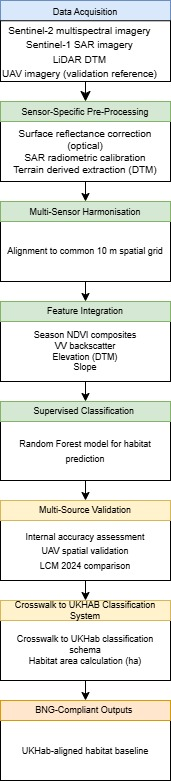
</div>


## 1 Area of Interest (AOI) Definition and Data Acquisition Setup
Sentinel-1 and Sentinel-2 data acquisition via Copernicus Data Space Ecosystem (CDSE)

##### 1.1 Load AOI and Verify Coordinate Reference System (CRS)

In [ ]:
from pathlib import Path

import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Paths
aoi_path = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\aoi_combined.gpkg") # replace with the pathway to your file
sites_path = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\aoi\aoi_sites.gpkg") # replace with the pathway to your file 

print(f"AOI path:   {aoi_path}")
print(f"Sites path: {sites_path}")

if not aoi_path.exists():
    raise FileNotFoundError(f"AOI GeoPackage not found at: {aoi_path}")

if not sites_path.exists():
    raise FileNotFoundError(f"Sites GeoPackage not found at: {sites_path}")

#Load overall study AOI extent
aoi = gpd.read_file(aoi_path)
print("\n=== AOI INFO ===")
print("CRS:", aoi.crs)
print("Features:", len(aoi))

site_layers = fiona.listlayers(sites_path)
print("\nLayers in aoi_sites.gpkg:")
for i, lyr in enumerate(site_layers):
    print(f"  [{i}] {lyr}")

if not site_layers:
    raise RuntimeError("No layers found in aoi_sites.gpkg")

site_gdfs = []
for lyr in site_layers:
    gdf = gpd.read_file(sites_path, layer=lyr)

    if gdf.empty or gdf.geometry.isna().all():
        print(f"Skipping layer '{lyr}' (no geometries).")
        continue

    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]
    if gdf.empty:
        print(f"Skipping layer '{lyr}' (all geometries empty).")
        continue

    gdf = gdf.copy()
    gdf["site_layer"] = lyr
    site_gdfs.append(gdf)

if not site_gdfs:
    raise RuntimeError("No site layers with valid geometries found in aoi_sites.gpkg")

sites_all = gpd.GeoDataFrame(
    pd.concat(site_gdfs, ignore_index=True),
    crs=site_gdfs[0].crs
)

print("\n=== ALL SITES INFO ===")
print("CRS:", sites_all.crs)
print("Total features across layers:", len(sites_all))
print("Layers represented:", sites_all["site_layer"].unique())

if aoi.crs is None or sites_all.crs is None:
    print("\nWarning: one or both layers have no CRS defined – plotting as-is.")
elif aoi.crs != sites_all.crs:
    print("\nReprojecting sites to match AOI CRS...")
    sites_all = sites_all.to_crs(aoi.crs)

# Compute plotting extent based on all site geometries
xmin, ymin, xmax, ymax = sites_all.total_bounds
dx = xmax - xmin
dy = ymax - ymin

buffer_x = dx * 0.1 if dx != 0 else 1
buffer_y = dy * 0.1 if dy != 0 else 1

xlim = (xmin - buffer_x, xmax + buffer_x)
ylim = (ymin - buffer_y, ymax + buffer_y)

print("\nSites bounds:", sites_all.total_bounds)
print("Using X limits:", xlim)
print("Using Y limits:", ylim)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

aoi.plot(
    ax=ax,
    edgecolor="grey",
    facecolor="none",
    linewidth=1.0,
    alpha=0.7,
    label="Study AOI",
)

sites_all.plot(
    ax=ax,
    column="site_layer",
    categorical=True,
    legend=True,
    alpha=0.6,
    linewidth=1.5,
)

ax.set_title("Study AOI + All Site AOIs", fontsize=14)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal", "box")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

plt.tight_layout()
plt.show()

print("\nLoaded AOI and sites.")


### 1.2 Reproject AOI to WGS84 (EPSG:4326) for CDSE/STAC Queries

AOI reprojection to WGS84 (EPSG:4326) for CDSE/STAC queries is handled internally within the data acquisition scripts.

### 1.3 Define Paths to Acquisition Scripts

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if not SCRIPTS_DIR.exists():
    raise FileNotFoundError(f"Scripts directory not found: {SCRIPTS_DIR}")

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print("Using scripts directory:", SCRIPTS_DIR)


### 1.4 Initialise Download Directories

In [ ]:
# Define a local folder for downloads
data_dir = Path(r"C:\EGM704\data_sets\egm704_project\data\sentinel1")
data_dir.mkdir(parents=True, exist_ok=True)
print(f"Download folder ready: {data_dir}")


### 1.5 Validate CDSE Authentication and Catalogue Access

Setup paths and import Python

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

sys.path.insert(0, str(SCRIPTS_DIR))
print("Using scripts dir:", SCRIPTS_DIR)


### 1.6 Set Copernicus Data Space Credentials (Environment Variables)

Authentication credentials for the Copernicus Data Space Ecosystem (CDSE) are provided via environment variables. These must be set outside the notebook (e.g. in an Anaconda Prompt) prior to running the acquisition steps.

- setx CDSE_USER "your_email_for_cdse"
- setx CDSE_PASS "your_password_for_cdse"

### 1.7 Validate CDSE Authentication and Catalogue Access

In [ ]:
import os
import requests

TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
CATALOGUE_URL = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"


def get_cdse_token():
    """
    Get an access token from Copernicus Data Space using env vars:
    CDSE_USER and CDSE_PASS.
    """
    username = os.environ.get("CDSE_USER")
    password = os.environ.get("CDSE_PASS")

    if not username or not password:
        raise RuntimeError(
            "CDSE_USER or CDSE_PASS environment variables not set. "
            "Set them with `setx` and restart your terminal."
        )

    data = {
        "client_id": "cdse-public",
        "grant_type": "password",
        "username": username,
        "password": password,
    }

    resp = requests.post(TOKEN_URL, data=data)
    resp.raise_for_status()

    token_info = resp.json()
    return token_info["access_token"], token_info.get("expires_in")


def main():
    # 1) Get a token
    token, expires_in = get_cdse_token()
    print("Got token (first 60 chars):", token[:60] + "...")
    print("Expires in (seconds):", expires_in)

    # 2) Check
    headers = {"Authorization": f"Bearer {token}"}
    params = {
        "$top": 1,
        "$filter": "Collection/Name eq 'SENTINEL-1'"
    }

    r = requests.get(CATALOGUE_URL, headers=headers, params=params)
    r.raise_for_status()

    data = r.json()
    products = data.get("value", [])
    print(f"Sample product count: {len(products)}")
    if products:
        print("First product ID:", products[0]["Id"])
        print("First product Name:", products[0]["Name"])


if __name__ == "__main__":
    main()


### 1.8 Sentinel-1 Data Acquisition (Monthly IW GRD Selection)

Sentinel-1 Interferometric Wide Swath (IW) Ground Range Detected (GRD) products were downloaded from the Copernicus Data Space Ecosystem (CDSE) Catalogue using the OData API. Monthly acquisition windows were defined between January 2022 and December 2025. For each month, products intersecting the AOI bounding geometry were queried, and results were filtered to retain IW GRD scenes only. Where multiple scenes were available within a month, a single product was selected based on temporal proximity to the midpoint of the month to provide consistent sampling while limiting download volume. Products were saved as ZIP archives under data/raw/sentinel1/, and existing files were skipped to allow safe re-execution. Only 2024 was used for the full workflow - it is recommended that the minimal size window be used for download as this step takes significant time to run with likelihood of system crash increasing.

In [ ]:
import os
import time
from datetime import datetime
from pathlib import Path
from typing import List, Optional, Tuple

import geopandas as gpd
import requests
from dateutil.relativedelta import relativedelta


# Configuration

AOI_PATH = r"C:\EGM704\data_sets\egm704_project\data\raw\aoi_combined.gpkg"
OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\sentinel1")

START_DATE = "2022-01-01"
END_DATE = "2025-12-31"

PAGE_SIZE = 10
DOWNLOAD_RETRIES = 3

TOKEN_URL = (
    "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/"
    "protocol/openid-connect/token"
)
CATALOGUE_URL = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
DOWNLOAD_BASE_URL = "https://download.dataspace.copernicus.eu/odata/v1/Products"


# Helper Functions

def validate_date(s: str) -> datetime:
    return datetime.strptime(s, "%Y-%m-%d")


def get_cdse_token() -> str:
    user = os.environ.get("CDSE_USER")
    pwd = os.environ.get("CDSE_PASS")
    if not user or not pwd:
        raise RuntimeError("CDSE_USER / CDSE_PASS not set")

    r = requests.post(
        TOKEN_URL,
        data={
            "client_id": "cdse-public",
            "grant_type": "password",
            "username": user,
            "password": pwd,
        },
        timeout=60,
    )
    r.raise_for_status()
    return r.json()["access_token"]


def load_aoi_bbox_wkt(aoi_path: str) -> str:
    gdf = gpd.read_file(aoi_path)
    if gdf.crs is None:
        raise ValueError("AOI has no CRS set.")
    gdf = gdf.to_crs(4326)

    try:
        geom = gdf.union_all()
    except AttributeError:
        geom = gdf.unary_union

    minx, miny, maxx, maxy = geom.bounds
    return (
        f"POLYGON(({minx} {miny}, {minx} {maxy}, "
        f"{maxx} {maxy}, {maxx} {miny}, {minx} {miny}))"
    )


def is_iw_grd(name: str) -> bool:
    return (
        "_IW_" in name
        and "_GRD" in name
        and "_SLC_" not in name
        and "_RAW_" not in name
        and "_OCN_" not in name
    )


def monthly_windows(start: datetime, end: datetime):
    cur = start
    while cur <= end:
        nxt = cur + relativedelta(months=1)
        yield cur, min(end, nxt - relativedelta(days=1))
        cur = nxt


def paged_search_month(
    token: str,
    wkt: str,
    start_dt: datetime,
    end_dt: datetime,
) -> Tuple[List[dict], str]:
    """
    Return (results, token). Token may be refreshed during calls.
    """
    start_iso = start_dt.strftime("%Y-%m-%dT00:00:00Z")
    end_iso = end_dt.strftime("%Y-%m-%dT23:59:59Z")

    filter_expr = (
        "Collection/Name eq 'SENTINEL-1' and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{wkt}') and "
        f"ContentDate/Start ge {start_iso} and "
        f"ContentDate/Start le {end_iso}"
    )

    params = {
        "$filter": filter_expr,
        "$orderby": "ContentDate/Start asc",
        "$select": "Id,Name,ContentDate",
        "$top": str(PAGE_SIZE),
    }

    url = CATALOGUE_URL
    results: List[dict] = []

    while True:
        headers = {"Authorization": f"Bearer {token}"}

        # Try once; if 401/403 then refresh token and retry once
        for attempt in range(2):
            r = requests.get(
                url,
                headers=headers,
                params=params if url == CATALOGUE_URL else None,
                timeout=(30, 120),
            )

            if r.status_code in (401, 403):
                print("  Token expired / forbidden — refreshing token")
                token = get_cdse_token()
                headers = {"Authorization": f"Bearer {token}"}
                continue

            r.raise_for_status()
            break
        else:
            # Only reached if both attempts hit 401/403 or otherwise didn't break
            r.raise_for_status()

        data = r.json()

        for p in data.get("value", []) or []:
            name = p.get("Name", "") or ""
            if is_iw_grd(name):
                results.append(p)

        next_link = data.get("@odata.nextLink")
        if not next_link:
            break
        url = next_link

    return results, token


def choose_mid_month(products: List[dict], start_dt: datetime, end_dt: datetime) -> Optional[dict]:
    if not products:
        return None

    mid_ts = start_dt + (end_dt - start_dt) / 2

    def dist(p):
        ts = p["ContentDate"]["Start"]
        dt = datetime.fromisoformat(ts.replace("Z", ""))
        return abs((dt - mid_ts).total_seconds())

    return min(products, key=dist)


def download_product(p: dict, token: str) -> Tuple[bool, str]:
    """
    Return (ok, token). Token may be refreshed if download returns 401/403.
    """
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    name = (p.get("Name") or "").replace(".SAFE", "")
    out_path = OUT_DIR / f"{name}.zip"

    if out_path.exists():
        print(f"    Already exists: {out_path.name}")
        return True, token

    url = f"{DOWNLOAD_BASE_URL}({p['Id']})/$value"

    for attempt in range(1, DOWNLOAD_RETRIES + 1):
        try:
            headers = {"Authorization": f"Bearer {token}"}
            print(f"    Downloading {out_path.name} (attempt {attempt}/{DOWNLOAD_RETRIES})")

            with requests.get(url, headers=headers, stream=True, timeout=(30, 600)) as r:
                if r.status_code in (401, 403):
                    print("    Download auth failed — refreshing token and retrying")
                    token = get_cdse_token()
                    continue

                r.raise_for_status()

                tmp_path = out_path.with_suffix(".zip.part")
                with open(tmp_path, "wb") as f:
                    for chunk in r.iter_content(1024 * 1024):
                        if chunk:
                            f.write(chunk)
                tmp_path.replace(out_path)

            return True, token

        except Exception as e:
            print(f"    Error: {e}")
            try:
                part = out_path.with_suffix(".zip.part")
                if part.exists():
                    part.unlink()
            except Exception:
                pass
            time.sleep(5 * attempt)

    return False, token


# Main section

def main():
    start_dt = validate_date(START_DATE)
    end_dt = validate_date(END_DATE)

    print("Sentinel-1 IW GRD downloader (1 scene per month)")
    token = get_cdse_token()
    wkt = load_aoi_bbox_wkt(AOI_PATH)

    for m_start, m_end in monthly_windows(start_dt, end_dt):
        print(f"\nMonth: {m_start.strftime('%Y-%m')}")

        products, token = paged_search_month(token, wkt, m_start, m_end)
        print(f"  IW GRD scenes found: {len(products)}")

        chosen = choose_mid_month(products, m_start, m_end)
        if not chosen:
            print("  No scene selected")
            continue

        print(f"  Selected: {chosen['Name']}")
        ok, token = download_product(chosen, token)
        if not ok:
            print("    Download failed")

        # gentle rate limiting
        time.sleep(1)

    print("\nDone.")


if __name__ == "__main__":
    main()


### 1.9 Sentinel-2 L2A Download (Monthly – Lowest Cloud Selection)

Sentinel-2 Level-2A (S2MSI2A) products were acquired from the Copernicus Data Space Ecosystem using the OData API. Monthly acquisition windows were defined for 2024, and scenes intersecting the AOI were retrieved. For each month, candidate products were evaluated using reported cloud cover, and a single scene was selected using lowest cloud cover with proximity to the midpoint of the month used as a tie-break. Selected products were downloaded as ZIP archives to the raw Sentinel-2 directory.

In [ ]:
import os
import time
from datetime import datetime
from pathlib import Path
from typing import List, Optional, Tuple

import geopandas as gpd
import requests
from dateutil.relativedelta import relativedelta

AOI_PATH = r"C:\EGM704\data_sets\egm704_project\data\raw\aoi_combined.gpkg"
OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\sentinel2")

START_DATE = "2022-01-01"
END_DATE = "2025-12-31"

PAGE_SIZE = 10            # per-page results from CDSE catalogue
CLOUD_MAX = 80.0          # start high for UK; tighten later (e.g., 40.0)
DOWNLOAD_RETRIES = 3

TOKEN_URL = (
    "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/"
    "protocol/openid-connect/token"
)
CATALOGUE_URL = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
DOWNLOAD_BASE_URL = "https://download.dataspace.copernicus.eu/odata/v1/Products"

def get_cdse_token() -> str:
    user = os.environ.get("CDSE_USER")
    pwd = os.environ.get("CDSE_PASS")
    if not user or not pwd:
        raise RuntimeError(
            "CDSE_USER / CDSE_PASS not set. Use `setx` then restart terminal."
        )

    r = requests.post(
        TOKEN_URL,
        data={
            "client_id": "cdse-public",
            "grant_type": "password",
            "username": user,
            "password": pwd,
        },
        timeout=60,
    )
    r.raise_for_status()
    return r.json()["access_token"]

def load_aoi_bbox_wkt(aoi_path: str) -> str:
    gdf = gpd.read_file(aoi_path)
    if gdf.crs is None:
        raise ValueError("AOI has no CRS set.")
    gdf = gdf.to_crs(4326)

    try:
        geom = gdf.union_all()
    except AttributeError:
        geom = gdf.unary_union

    minx, miny, maxx, maxy = geom.bounds
    return (
        f"POLYGON(({minx} {miny}, {minx} {maxy}, "
        f"{maxx} {maxy}, {maxx} {miny}, {minx} {miny}))"
    )

def validate_date(s: str) -> datetime:
    return datetime.strptime(s, "%Y-%m-%d")


def monthly_windows(start: datetime, end: datetime):
    cur = start
    while cur <= end:
        nxt = cur + relativedelta(months=1)
        yield cur, min(end, nxt - relativedelta(days=1))
        cur = nxt

def _extract_numeric_attr(product: dict, target_names: Tuple[str, ...]) -> Optional[float]:
    """
    Find a numeric attribute by name (case-insensitive) in product['Attributes'].
    """
    attrs = product.get("Attributes", []) or []
    targets = {n.lower() for n in target_names}
    for att in attrs:
        name = (att.get("Name") or "").strip().lower()
        if name in targets:
            val = att.get("Value")
            try:
                return float(val) if val is not None else None
            except Exception:
                return None
    return None


def get_cloud_cover(product: dict) -> Optional[float]:
    # common candidates
    return _extract_numeric_attr(product, ("cloudCover", "cloudcoverpercentage"))


def get_content_start_dt(product: dict) -> Optional[datetime]:
    cd = product.get("ContentDate") or {}
    start = cd.get("Start")
    if not start:
        return None
    try:
        return datetime.fromisoformat(start.replace("Z", ""))
    except Exception:
        return None

def paged_search_s2_month(
    token: str,
    aoi_wkt: str,
    start_dt: datetime,
    end_dt: datetime,
) -> Tuple[List[dict], str]:
    """
    Return (products, token). Token may be refreshed during catalogue calls.

    Server-side filters:
    - Collection: SENTINEL-2
    - productType: S2MSI2A
    - Intersects AOI bbox
    - Date window
    - cloudCover <= CLOUD_MAX (uses 'cloudCover' attribute name in filter)
    """
    start_iso = start_dt.strftime("%Y-%m-%dT00:00:00.000Z")
    end_iso = end_dt.strftime("%Y-%m-%dT23:59:59.999Z")

    producttype_filter = (
        "Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' "
        "and att/OData.CSC.StringAttribute/Value eq 'S2MSI2A')"
    )

    cloud_filter = (
        "Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq 'cloudCover' "
        f"and att/OData.CSC.DoubleAttribute/Value le {float(CLOUD_MAX)})"
    )

    filter_expr = (
        "Collection/Name eq 'SENTINEL-2' and "
        f"{producttype_filter} and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{aoi_wkt}') and "
        f"ContentDate/Start ge {start_iso} and "
        f"ContentDate/Start le {end_iso} and "
        f"{cloud_filter}"
    )

    params = {
        "$filter": filter_expr,
        "$orderby": "ContentDate/Start asc",
        "$top": str(PAGE_SIZE),
        "$select": "Id,Name,ContentDate",
        "$expand": "Attributes",
    }

    url = CATALOGUE_URL
    results: List[dict] = []

    while True:
        headers = {"Authorization": f"Bearer {token}"}

        for attempt in range(2):
            r = requests.get(
                url,
                headers=headers,
                params=params if url == CATALOGUE_URL else None,
                timeout=(30, 180),
            )

            if r.status_code in (401, 403):
                print("  Token expired / forbidden — refreshing token")
                token = get_cdse_token()
                headers = {"Authorization": f"Bearer {token}"}
                continue

            if r.status_code != 200:
                print("  Request URL:", r.url)
                print("  Status code:", r.status_code)
                print("  Response text:", r.text[:2000])
                r.raise_for_status()

            break
        else:
            r.raise_for_status()

        data = r.json()
        results.extend(data.get("value", []) or [])

        next_link = data.get("@odata.nextLink")
        if not next_link:
            break
        url = next_link

    return results, token

def choose_lowest_cloud_midmonth(
    products: List[dict],
    window_start: datetime,
    window_end: datetime,
) -> Optional[dict]:
    if not products:
        return None

    mid_ts = window_start + (window_end - window_start) / 2

    scored = []
    for p in products:
        cc = get_cloud_cover(p)
        dt = get_content_start_dt(p)

        cloud_score = cc if cc is not None else 1e9
        mid_dist = abs((dt - mid_ts).total_seconds()) if dt else 1e18

        scored.append((cloud_score, mid_dist, p))

    scored.sort(key=lambda t: (t[0], t[1]))
    return scored[0][2]

def download_product(product: dict, token: str) -> Tuple[bool, str]:
    """
    Return (ok, token). Token may be refreshed if download returns 401/403.
    """
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    name = (product.get("Name") or "").replace(".SAFE", "")
    out_path = OUT_DIR / f"{name}.zip"

    if out_path.exists():
        print(f"    Already exists: {out_path.name}")
        return True, token

    url = f"{DOWNLOAD_BASE_URL}({product['Id']})/$value"

    for attempt in range(1, DOWNLOAD_RETRIES + 1):
        try:
            headers = {"Authorization": f"Bearer {token}"}
            print(f"    Downloading {out_path.name} (attempt {attempt}/{DOWNLOAD_RETRIES})")

            with requests.get(url, headers=headers, stream=True, timeout=(30, 600)) as r:
                if r.status_code in (401, 403):
                    print("    Download auth failed — refreshing token and retrying")
                    token = get_cdse_token()
                    continue

                r.raise_for_status()

                tmp_path = out_path.with_suffix(".zip.part")
                with open(tmp_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)
                tmp_path.replace(out_path)

            return True, token

        except Exception as e:
            print(f"    Error: {e}")
            try:
                part = out_path.with_suffix(".zip.part")
                if part.exists():
                    part.unlink()
            except Exception:
                pass
            time.sleep(5 * attempt)

    return False, token


# Main Section

def main():
    start_dt = validate_date(START_DATE)
    end_dt = validate_date(END_DATE)
    if start_dt > end_dt:
        raise ValueError("START_DATE must be <= END_DATE")

    print("Sentinel-2 L2A downloader (1 scene per month, lowest cloud)")
    token = get_cdse_token()
    print("Token OK")

    aoi_wkt = load_aoi_bbox_wkt(AOI_PATH)

    for w_start, w_end in monthly_windows(start_dt, end_dt):
        print(f"\nMonth: {w_start.strftime('%Y-%m')}")

        products, token = paged_search_s2_month(token, aoi_wkt, w_start, w_end)
        print(f"  Candidates returned: {len(products)}")

        chosen = choose_lowest_cloud_midmonth(products, w_start, w_end)
        if not chosen:
            print("  No scene selected (no candidates).")
            continue

        chosen_cc = get_cloud_cover(chosen)
        chosen_dt = get_content_start_dt(chosen)
        print(f"  Selected: {chosen['Name']}")
        print(f"    Cloud: {chosen_cc}%  Date: {chosen_dt}")

        ok, token = download_product(chosen, token)
        if not ok:
            print("    Download failed")

        time.sleep(1)

    print("\nDone.")


if __name__ == "__main__":
    main()


### 1.10 Sentinel-1 Scene Manifest (Monthly Selection Record)

A manifest of downloaded Sentinel-1 scenes was generated by parsing acquisition timestamps from the ZIP filenames within data/raw/sentinel1/. The script groups scenes by year and month and selects one scene per month based on temporal proximity to the 15th (mid-month), matching the monthly sampling rule. The resulting manifest is written to data/processed/manifests/ as a CSV to provide a reproducible record of the selected inputs used in downstream processing.

In [ ]:
import re
from datetime import datetime
from pathlib import Path

import pandas as pd


S1_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\sentinel1")
OUT_CSV = Path(r"C:\EGM704\data_sets\egm704_project\data\processed\manifests\sentinel1_scene_manifest.csv")


DT_RE = re.compile(r"_(\d{8}T\d{6})_(\d{8}T\d{6})_")


def parse_s1_name(zip_path: Path) -> dict:
    name = zip_path.stem  # no .zip
    m = DT_RE.search(name)
    if not m:
        raise ValueError(f"Could not parse datetime from: {zip_path.name}")

    start_str = m.group(1)  # YYYYMMDDTHHMMSS
    end_str = m.group(2)

    start_dt = datetime.strptime(start_str, "%Y%m%dT%H%M%S")
    end_dt = datetime.strptime(end_str, "%Y%m%dT%H%M%S")

    sensor = name.split("_", 1)[0]  # S1A / S1B / S1C
    year = start_dt.year
    month = start_dt.month

    return {
        "sensor": "S1",
        "platform": sensor,
        "year": year,
        "month": month,
        "ym": f"{year:04d}-{month:02d}",
        "product_name": name + ".SAFE",
        "zip_filename": zip_path.name,
        "acq_start": start_dt.isoformat(),
        "acq_end": end_dt.isoformat(),
    }


def choose_mid_month(df_month: pd.DataFrame) -> pd.Series:
    year = int(df_month.iloc[0]["year"])
    month = int(df_month.iloc[0]["month"])

    mid = datetime(year, month, 15, 12, 0, 0)

    start_dts = pd.to_datetime(df_month["acq_start"])
    df_month = df_month.copy()
    df_month["mid_dist_seconds"] = (start_dts - pd.Timestamp(mid)).abs().dt.total_seconds()

    chosen = df_month.sort_values(["mid_dist_seconds", "acq_start"]).iloc[0]
    return chosen


def main():
    if not S1_DIR.exists():
        raise FileNotFoundError(f"Sentinel-1 folder not found: {S1_DIR}")

    zips = sorted(S1_DIR.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"No .zip files found in: {S1_DIR}")

    rows = []
    for zp in zips:
        try:
            rows.append(parse_s1_name(zp))
        except Exception as e:
            print(f"Skipping {zp.name}: {e}")

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No parseable Sentinel-1 zip filenames were found.")

    chosen_rows = []
    for _, grp in df.groupby(["year", "month"], sort=True):
        chosen_rows.append(choose_mid_month(grp))

    manifest = pd.DataFrame(chosen_rows).sort_values(["year", "month"]).reset_index(drop=True)

    manifest["selection_rule"] = "mid-month (closest to 15th)"
    manifest["notes"] = ""

    OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(OUT_CSV, index=False)

    print(f"Wrote manifest with {len(manifest)} rows:")
    print(str(OUT_CSV))


if __name__ == "__main__":
    main()


### 1.11 Sentinel-2 scene manifest (from ZIPs)

Sentinel-2 monthly inputs were recorded in a local scene manifest by parsing acquisition timestamps from downloaded ZIP filenames in data/raw/sentinel2/. Scenes were grouped by year and month and one scene was selected per month. Where a cloud value could be parsed from the filename (not typical for Sentinel-2), the lowest cloud scene was preferred; otherwise selection defaulted to the scene closest to mid-month (15th at 12:00). The resulting manifest was written to data/processed/manifests/ as a reproducible record of the Sentinel-2 inputs used downstream.

In [ ]:
import re
from datetime import datetime
from pathlib import Path
from typing import Optional

import pandas as pd


S2_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\sentinel2")
OUT_CSV = Path(r"C:\EGM704\data_sets\egm704_project\data\processed\manifests\sentinel2_scene_manifest.csv")

S2_DT_RE = re.compile(r"^S2[ABC]_MSIL2A_(\d{8}T\d{6})_")
S2_CLOUD_RE = re.compile(r"_CLOUD(\d{1,3})_", re.IGNORECASE)  


def parse_s2_zip(zip_path: Path) -> dict:
    name = zip_path.stem 

    m = S2_DT_RE.search(name)
    if not m:
        raise ValueError(f"Could not parse acquisition datetime from: {zip_path.name}")

    acq_str = m.group(1)  
    acq_dt = datetime.strptime(acq_str, "%Y%m%dT%H%M%S")

    platform = name.split("_", 1)[0]  

    cloud_val: Optional[float] = None
    mc = S2_CLOUD_RE.search(name)
    if mc:
        try:
            cloud_val = float(mc.group(1))
        except Exception:
            cloud_val = None

    return {
        "sensor": "S2",
        "platform": platform,
        "year": acq_dt.year,
        "month": acq_dt.month,
        "ym": f"{acq_dt.year:04d}-{acq_dt.month:02d}",
        "product_name": name + ".SAFE",
        "zip_filename": zip_path.name,
        "acq_datetime": acq_dt.isoformat(),
        "cloud_cover": cloud_val,
    }


def choose_one_per_month(df_month: pd.DataFrame) -> pd.Series:
    year = int(df_month.iloc[0]["year"])
    month = int(df_month.iloc[0]["month"])
    mid = datetime(year, month, 15, 12, 0, 0)

    dfm = df_month.copy()
    dfm["acq_dt"] = pd.to_datetime(dfm["acq_datetime"])
    dfm["mid_dist_seconds"] = (dfm["acq_dt"] - pd.Timestamp(mid)).abs().dt.total_seconds()

    dfm["cloud_sort"] = dfm["cloud_cover"].fillna(1e9)

    chosen = dfm.sort_values(["cloud_sort", "mid_dist_seconds", "acq_dt"]).iloc[0]
    return chosen


def main():
    if not S2_DIR.exists():
        raise FileNotFoundError(f"Sentinel-2 folder not found: {S2_DIR}")

    zips = sorted(S2_DIR.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"No .zip files found in: {S2_DIR}")

    rows = []
    for zp in zips:
        if zp.name.endswith(".zip.part"):
            continue
        try:
            rows.append(parse_s2_zip(zp))
        except Exception as e:
            print(f"Skipping {zp.name}: {e}")

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No parseable Sentinel-2 zip filenames were found.")

    chosen_rows = []
    for _, grp in df.groupby(["year", "month"], sort=True):
        chosen_rows.append(choose_one_per_month(grp))

    manifest = pd.DataFrame(chosen_rows).sort_values(["year", "month"]).reset_index(drop=True)

    manifest["selection_rule"] = "lowest cloud if available; else mid-month (closest to 15th)"
    manifest["notes"] = ""

    OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(OUT_CSV, index=False)

    print(f"Wrote manifest with {len(manifest)} rows:")
    print(str(OUT_CSV))


if __name__ == "__main__":
    main()


### 1.12 Sentinel-2 SAFE Extraction (Manifest-driven)

Selected Sentinel-2 archives were extracted to SAFE format using a manifest-driven script. The script reads the Sentinel-2 scene manifest CSV, extracts only the listed ZIP files using 7-Zip, and skips scenes where the corresponding .SAFE directory already exists. Extracted SAFE products are written to data/raw/sentinel2_safe/, providing a deterministic set of inputs for subsequent preprocessing steps.

In [ ]:
import subprocess
from pathlib import Path

import pandas as pd


# Configuration
ZIP_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\sentinel2")
EXTRACT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\sentinel2_safe")

MANIFEST_CSV = Path(
    r"C:\EGM704\data_sets\egm704_project\data\processed\manifests\sentinel2_scene_manifest.csv"
)

SEVEN_ZIP = r"C:\Program Files\7-Zip\7z.exe"


# Helper functions
def expected_safe_folder(product_name: str) -> Path:
    """
    product_name is typically like:
      S2A_MSIL2A_....SAFE
    """
    return EXTRACT_ROOT / product_name


def extract_zip_fast(zip_file: Path) -> bool:
    """Extract using 7z x <zip> -o<output>."""
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

    cmd = [
        SEVEN_ZIP,
        "x",
        str(zip_file),
        f"-o{EXTRACT_ROOT}",
        "-y",
    ]

    try:
        subprocess.run(cmd, check=True)
        return True
    except subprocess.CalledProcessError as e:
        print(f"  Extraction failed: {e}")
        return False


# Main Section
def main():
    print("Manifest-driven Sentinel-2 SAFE extraction using 7-Zip")
    print("------------------------------------------------------")
    print(f"ZIP folder:   {ZIP_DIR}")
    print(f"Output root:  {EXTRACT_ROOT}")
    print(f"Manifest CSV: {MANIFEST_CSV}")
    print("")

    if not MANIFEST_CSV.exists():
        print("Manifest CSV not found. Aborting.")
        return

    df = pd.read_csv(MANIFEST_CSV)

    required_cols = {"zip_filename", "product_name"}
    missing = required_cols - set(df.columns)
    if missing:
        print(f"Manifest missing required columns: {sorted(missing)}")
        return

    skipped = []
    extracted = []
    failed = []
    missing_zip = []

    for _, row in df.iterrows():
        zip_name = str(row["zip_filename"])
        product_name = str(row["product_name"])

        # Ignore any accidental partials
        if zip_name.endswith(".zip.part"):
            continue

        zip_path = ZIP_DIR / zip_name
        safe_path = expected_safe_folder(product_name)

        if safe_path.exists():
            print(f"Skipping: SAFE exists -> {product_name}")
            skipped.append(product_name)
            continue

        if not zip_path.exists():
            print(f"Missing ZIP: {zip_name}")
            missing_zip.append(zip_name)
            continue

        print(f"Extracting: {zip_name}")
        ok = extract_zip_fast(zip_path)
        if ok and safe_path.exists():
            print(f"  Extracted OK -> {product_name}")
            extracted.append(product_name)
        else:
            print(f"  Extract may have failed -> {zip_name}")
            failed.append(zip_name)

    print("\n------------------------------------------------------")
    print("Summary")
    print("------------------------------------------------------")
    print(f"Manifest rows:      {len(df)}")
    print(f"Extracted:          {len(extracted)}")
    print(f"Skipped (existing): {len(skipped)}")
    print(f"Missing ZIPs:       {len(missing_zip)}")
    print(f"Failed:             {len(failed)}")

    if missing_zip:
        print("\nMissing ZIPs:")
        for f in missing_zip:
            print("  -", f)

    if failed:
        print("\nFailed ZIPs:")
        for f in failed:
            print("  -", f)

    print("\nDone.")


if __name__ == "__main__":
    main()


### 1.13 Extract Sentinel-1 SAFE Archives (Manifest-Driven)

Selected Sentinel-1 archives were extracted to SAFE format using a manifest-driven process. The scene manifest was used to identify the required monthly products, ensuring that only the selected inputs were extracted for subsequent Sentinel-1 preprocessing.

In [ ]:
import subprocess
from pathlib import Path

import pandas as pd


# Configuration
MODE = "manifest"  # "manifest" or "all_zips"

ZIP_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\sentinel1")
EXTRACT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\sentinel1_safe")

MANIFEST_CSV = Path(
    r"C:\EGM704\data_sets\egm704_project\data\processed\manifests\sentinel1_scene_manifest.csv"
)

SEVEN_ZIP = r"C:\Program Files\7-Zip\7z.exe"


# Helper Functions
def expected_safe_folder(product_name: str) -> Path:
    return EXTRACT_ROOT / product_name


def extract_zip_fast(zip_file: Path) -> bool:
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

    cmd = [
        SEVEN_ZIP,
        "x",
        str(zip_file),
        f"-o{EXTRACT_ROOT}",
        "-y",
    ]

    try:
        subprocess.run(cmd, check=True)
        return True
    except subprocess.CalledProcessError as e:
        print(f"  Extraction failed: {e}")
        return False


def list_zip_files():
    return sorted([p for p in ZIP_DIR.glob("*.zip") if not p.name.endswith(".zip.part")])


# Main section
def main():
    print("Sentinel-1 SAFE extraction using 7-Zip")
    print("--------------------------------------")
    print(f"ZIP folder:   {ZIP_DIR}")
    print(f"Output root:  {EXTRACT_ROOT}")
    print(f"Mode:         {MODE}")
    if MODE == "manifest":
        print(f"Manifest CSV: {MANIFEST_CSV}")
    print("")

    if MODE == "manifest":
        if not MANIFEST_CSV.exists():
            print("Manifest CSV not found. Aborting.")
            return

        df = pd.read_csv(MANIFEST_CSV)
        required_cols = {"zip_filename", "product_name"}
        missing = required_cols - set(df.columns)
        if missing:
            print(f"Manifest missing required columns: {sorted(missing)}")
            return

        tasks = []
        for _, row in df.iterrows():
            zip_name = str(row["zip_filename"])
            product_name = str(row["product_name"])
            if zip_name.endswith(".zip.part"):
                continue
            tasks.append((zip_name, product_name))

    else:
        zips = list_zip_files()
        tasks = [(z.name, z.stem + ".SAFE") for z in zips]

    skipped = []
    extracted = []
    failed = []
    missing_zip = []

    for zip_name, product_name in tasks:
        zip_path = ZIP_DIR / zip_name
        safe_path = expected_safe_folder(product_name)

        if safe_path.exists():
            print(f"Skipping: SAFE exists -> {product_name}")
            skipped.append(product_name)
            continue

        if not zip_path.exists():
            print(f"Missing ZIP: {zip_name}")
            missing_zip.append(zip_name)
            continue

        print(f"Extracting: {zip_name}")
        ok = extract_zip_fast(zip_path)

        # Verify extraction produced the SAFE folder (best-effort)
        if ok and safe_path.exists():
            print(f"  Extracted OK -> {product_name}")
            extracted.append(product_name)
        else:
            print(f"  Extract may have failed -> {zip_name}")
            failed.append(zip_name)

    print("\n--------------------------------------")
    print("Summary")
    print("--------------------------------------")
    print(f"Tasks:              {len(tasks)}")
    print(f"Extracted:          {len(extracted)}")
    print(f"Skipped (existing): {len(skipped)}")
    print(f"Missing ZIPs:       {len(missing_zip)}")
    print(f"Failed:             {len(failed)}")

    if missing_zip:
        print("\nMissing ZIPs:")
        for f in missing_zip:
            print("  -", f)

    if failed:
        print("\nFailed ZIPs:")
        for f in failed:
            print("  -", f)

    print("\nDone.")


if __name__ == "__main__":
    main()


## 2 Sentinel Preprocessing: Harmonisation & Feature Extraction

Following data acquisition and SAFE extraction, Sentinel imagery was pre-processed to produce spatially harmonised, analysis-ready products for feature stacking and classification. This stage standardised projection, radiometric scaling, and spatial resolution to ensure consistency across scenes and compatibility with multi-sensor integration.

### 2.1 Sentinel-1 SNAP Pre-Processing

Sentinel-1 IW GRD products were pre-processed using ESA SNAP’s Graph Processing Framework (GPF), executed via the esa_snappy Python interface. The processing chain included precise orbit file application, thermal noise removal, radiometric calibration to sigma nought (VV polarisation), and Range-Doppler terrain correction to a 10 m UTM grid (EPSG:32630). Outputs were written as GeoTIFF files for subsequent feature extraction.

In [ ]:
from pathlib import Path
from esa_snappy import ProductIO, GPF, HashMap

GPF.getDefaultInstance().getOperatorSpiRegistry().loadOperatorSpis()

RAW_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\sentinel1_safe")
OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\processed\sentinel1_preprocessed")
TARGET_EPSG = "EPSG:32630"

def apply_orbit(product):
    params = HashMap()
    params.put("orbitType", "Sentinel Precise (Auto Download)")
    params.put("continueOnFail", True)
    return GPF.createProduct("Apply-Orbit-File", params, product)

def remove_thermal_noise(product):
    params = HashMap()
    params.put("removeThermalNoise", True)
    return GPF.createProduct("ThermalNoiseRemoval", params, product)

def calibrate_vv_only(product):
    params = HashMap()
    params.put("outputSigmaBand", True)
    params.put("sourceBands", "Intensity_VV")
    params.put("selectedPolarisations", "VV")
    params.put("outputImageScaleInDb", False)
    return GPF.createProduct("Calibration", params, product)

def terrain_correct(product):
    params = HashMap()
    params.put("demName", "SRTM 3Sec")
    params.put("demResamplingMethod", "BILINEAR_INTERPOLATION")
    params.put("imgResamplingMethod", "BILINEAR_INTERPOLATION")
    params.put("pixelSpacingInMeter", 10.0)
    params.put("mapProjection", TARGET_EPSG)
    params.put("saveSelectedSourceBand", True)
    return GPF.createProduct("Terrain-Correction", params, product)

def preprocess_one(input_path: Path):
    print(f"Processing: {input_path.name}")
    product = ProductIO.readProduct(str(input_path))
    if product is None:
        print("  ! Failed to read product")
        return

    p = apply_orbit(product)
    p = remove_thermal_noise(p)
    p = calibrate_vv_only(p)
    p = terrain_correct(p)

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    out_base = OUT_DIR / (input_path.stem + "_TC_VV")  # no .tif
    print(f"  - Writing output base: {out_base}")
    ProductIO.writeProduct(p, str(out_base), "GeoTIFF-BigTIFF")

    written = list(OUT_DIR.glob(out_base.name + "*.tif"))
    print("  - Written files:")
    for w in written:
        print("    ", w.name)
    print("Done.\n")

def main():
    if not RAW_DIR.exists():
        raise FileNotFoundError(f"RAW_DIR not found: {RAW_DIR}")

    safe_products = sorted([p for p in RAW_DIR.iterdir() if p.is_dir() and p.name.endswith(".SAFE")])
    if not safe_products:
        print("No .SAFE folders found directly under RAW_DIR.")
        print("Trying recursive search...")
        safe_products = sorted(RAW_DIR.rglob("*.SAFE"))

    print("SAFE products found:", len(safe_products))
    for p in safe_products:
        preprocess_one(p)

if __name__ == "__main__":
    main()


### 2.2 Sentinel-1 Preprocessing Workflow (SNAP / esa_snappy)

Sentinel-1 IW GRD scenes were pre-processed using ESA SNAP’s Graph Processing Framework (GPF), accessed via the Python esa_snappy interface, to generate analysis-ready sigma-naught (σ⁰) backscatter. The workflow applies a standard radiometric normalisation and terrain correction chain to harmonise scenes to a common 10 m grid in UTM Zone 30N (EPSG:32630).

Processing steps
- Apply Orbit File (Sentinel Precise; auto-download)
- Thermal Noise Removal
- Calibration to σ⁰ for VV polarisation
- Range-Doppler Terrain Correction using SRTM 3-sec DEM; bilinear resampling
- Output GeoTIFF (BigTIFF), 10 m, EPSG:32630

Output directory
data/processed/sentinel1_preprocessed/

Processed products are written with the base name <product_name>_TC_VV (SNAP may write one or more .tif files per product).

Implementation note
This preprocessing step is executed as a standalone script (`preprocess_s1_snappy.py`) to support batch processing and reproducibility. The notebook includes a lightweight output check below to confirm that terrain-corrected products were generated as expected.



NOTE:
Speckle filtering was intentionally not applied in this workflow.
This decision reflects the use of Random Forest classification, which is robust to speckle noise, and the alignment of all predictors to a 10 m reference grid. Omitting speckle filtering preserves the original backscatter signal and maintains consistency with the simplified, reproducible workflow design.

### 2.2.1 Output sanity check (terrain-corrected Sentinel-1)

The following code locates a representative *_TC_VV*.tif output and prints basic metadata (dimensions, band count, CRS) and a small sample of pixel values to confirm plausible ranges.

In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\processed\sentinel1_preprocessed")

tifs = sorted(
    OUT_DIR.glob("*_TC_VV.tif"),
    key=lambda p: p.stat().st_mtime
)

if not tifs:
    raise FileNotFoundError("No Sentinel-1 VV GeoTIFFs found")

tif_path = tifs[-1]
print("Using:", tif_path.name)

with rasterio.open(tif_path) as src:
    print("Driver:", src.driver)
    print("CRS:", src.crs)
    print("Bands:", src.count)

    win = rasterio.windows.Window(
        (src.width - 1024) // 2,
        (src.height - 1024) // 2,
        1024,
        1024
    )
    data = src.read(1, window=win)

plt.figure(figsize=(6, 6))
show(data, cmap="gray", title="Sentinel-1 VV σ⁰ (terrain-corrected)")
plt.show()


Applied a log scale...

In [ ]:
import numpy as np
plt.figure(figsize=(6,6))
show(10 * np.log10(data + 1e-6), cmap='gray', title="Sentinel-1 VV σ⁰ (dB scale)")
plt.show()


### 2.1.2 Polarisation Selection (VV vs VH)

Both VV and VH polarisations were initially considered as candidate Sentinel-1 features. Cross-polarised (VH) backscatter can provide sensitivity to volume scattering within vegetation canopies and has been applied in biomass-oriented studies.

However, exploratory inspection across the study sites indicated that VH exhibited greater speckle noise and limited additional discriminatory value for the heterogeneous, small-extent habitats under investigation. In contrast, VV backscatter provided a more stable and interpretable response to surface roughness and soil moisture conditions—characteristics more directly relevant to differentiating UKHab-aligned habitat classes in mixed terrestrial landscapes.

Given the study’s emphasis on habitat classification rather than biomass estimation, and to reduce computational overhead and noise propagation in subsequent feature stacking, only VV polarisation was retained for downstream analysis (Balzter, 2001; Adeli et al., 2020).

### 2.1.3 Clip Terrain-Corrected Sentinel-1 VV to the AOI

To reduce data volume and ensure consistent spatial extent across sensors, terrain-corrected Sentinel-1 VV backscatter rasters were clipped to the study Area of Interest (AOI) polygon. Clipping was applied after SNAP terrain correction so that all outputs share a common projected CRS and 10 m grid prior to multi-sensor feature stacking.

The following script clips each `*_TC_VV.tif` raster to the AOI boundary stored in a GeoPackage, writes a clipped GeoTIFF to the processed directory, and (optionally) generates a quick-look PNG in dB for visual quality control.


In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import List, Optional, Tuple

import geopandas as gpd
import numpy as np
import rasterio
from rasterio import mask as rio_mask
import matplotlib.pyplot as plt


# Configuration
PROCESSED_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\processed\sentinel1_preprocessed")
AOI_PATH = Path(r"C:\EGM704\data_sets\egm704_project\data\raw\aoi_combined.gpkg")
OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\processed\sentinel1_clipped")

INPUT_GLOB = "*_TC_VV.tif"

WRITE_QC_PNG = True


# Helper Functions
def _load_aoi_shapes(aoi_path: Path, target_crs) -> List[dict]:
    aoi = gpd.read_file(aoi_path)
    if aoi.empty:
        raise ValueError(f"AOI file is empty: {aoi_path}")

    if aoi.crs is None:
        raise ValueError(f"AOI has no CRS defined: {aoi_path}. Define CRS before clipping.")

    if aoi.crs != target_crs:
        aoi = aoi.to_crs(target_crs)

    shapes = [geom.__geo_interface__ for geom in aoi.geometry if geom is not None and not geom.is_empty]
    if not shapes:
        raise ValueError("AOI geometry is empty after loading/reprojection.")
    return shapes


def _clip_single_band(
    src: rasterio.io.DatasetReader,
    shapes: List[dict],
) -> Tuple[np.ndarray, rasterio.Affine, dict]:
    """
    Clip band 1 (VV) to AOI.

    Returns:
      clipped_2d: (H, W) array
      out_transform: affine transform for clipped raster
      out_meta: updated raster metadata for writing
    """
    clipped, out_transform = rio_mask.mask(
        src,
        shapes,
        crop=True,
        filled=True,
        indexes=1,  # VV only
    )

    if clipped.ndim == 3:
        clipped_2d = clipped[0]
    else:
        clipped_2d = clipped

    out_meta = src.meta.copy()
    out_meta.update(
        {
            "height": clipped_2d.shape[0],
            "width": clipped_2d.shape[1],
            "transform": out_transform,
            "count": 1,
        }
    )
    return clipped_2d, out_transform, out_meta


def _write_qc_png(out_png: Path, arr_2d: np.ndarray, nodata: Optional[float]) -> None:
    """
    Write a simple quicklook PNG in dB with a robust stretch (2–98%).
    """
    a = arr_2d.astype("float32")

    if nodata is not None:
        a = np.where(a == nodata, np.nan, a)

    db = 10.0 * np.log10(a + 1e-6)

    vmin = np.nanpercentile(db, 2)
    vmax = np.nanpercentile(db, 98)

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111)
    ax.imshow(db, vmin=vmin, vmax=vmax, cmap="gray")
    ax.set_title(out_png.stem)
    ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(out_png, dpi=150)
    plt.close(fig)


# Main section 
def main() -> None:
    if not PROCESSED_DIR.exists():
        raise FileNotFoundError(f"Processed directory not found: {PROCESSED_DIR}")
    if not AOI_PATH.exists():
        raise FileNotFoundError(f"AOI file not found: {AOI_PATH}")

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    inputs = sorted(PROCESSED_DIR.glob(INPUT_GLOB))
    if not inputs:
        # Fallback: accept any TC outputs if naming differs
        inputs = sorted(PROCESSED_DIR.glob("*_TC*.tif"))
        if not inputs:
            raise FileNotFoundError(
                f"No input rasters found in {PROCESSED_DIR} using '{INPUT_GLOB}' or '*_TC*.tif'."
            )

    print(f"Found {len(inputs)} input raster(s).")
    print(f"AOI: {AOI_PATH}")
    print(f"Output folder: {OUT_DIR}\n")

    # Load AOI shapes once (reprojected to match first raster CRS)
    with rasterio.open(inputs[0]) as src0:
        target_crs = src0.crs
        if target_crs is None:
            raise ValueError(f"Input raster has no CRS: {inputs[0]}")
    aoi_shapes = _load_aoi_shapes(AOI_PATH, target_crs)

    clipped_count = 0

    for in_path in inputs:
        out_tif = OUT_DIR / f"{in_path.stem}_CLIP.tif"
        out_png = OUT_DIR / f"{in_path.stem}_CLIP_QC.png"

        if out_tif.exists():
            print(f"Skip (exists): {out_tif.name}")
            continue

        print(f"Clipping: {in_path.name}")

        with rasterio.open(in_path) as src:
            if src.count != 1:
                print(f"  Warning: {in_path.name} has {src.count} band(s). Clipping band 1 only.")

            clipped_2d, _, out_meta = _clip_single_band(src, aoi_shapes)

            # Write clipped GeoTIFF (single-band)
            with rasterio.open(out_tif, "w", **out_meta) as dst:
                dst.write(clipped_2d, 1)

            clipped_count += 1

            # Optional QC PNG
            if WRITE_QC_PNG:
                _write_qc_png(out_png, clipped_2d, out_meta.get("nodata", src.nodata))

        print(f"  Wrote: {out_tif.name}")
        if WRITE_QC_PNG:
            print(f"  QC:    {out_png.name}")

    total_tifs = len(list(OUT_DIR.glob("*.tif")))
    print(f"\nDone. Newly clipped: {clipped_count}. Total clipped GeoTIFFs in folder: {total_tifs}")


if __name__ == "__main__":
    main()


This means: 
  
VV σ⁰ (dB, clipped): Terrain-corrected Sentinel-1 VV backscatter was clipped to the area of interest and converted to decibel (dB) units for visual inspection. VV backscatter provides a stable and interpretable response to surface roughness and moisture conditions, supporting differentiation between built-up surfaces, bare ground, managed grassland and vegetated areas within heterogeneous UK landscapes.

## 3 Sentinel-2 Preprocessing and Feature Generation

Sentinel-2 Level-2A (surface reflectance) products were processed to generate cloud-masked spectral features and vegetation indices aligned to the study AOI.

### 3.1 Automated Sentinel-2 L2A Processing Workflow

Sentinel-2 L2A SAFE products were processed to derive cloud-masked reflectance bands and vegetation indices. Processing included AOI clipping of 10 m bands (B02, B03, B04, B08), pixel-level cloud and shadow masking using the Scene Classification Layer (SCL), and NDVI computation using safe division. Outputs were written as GeoTIFF files for subsequent feature stacking.

In [ ]:
from pathlib import Path
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

# Configuration
base = Path(r"C:\EGM704\data_sets\egm704_project\data")

raw_dir       = base / "raw" / "sentinel2_safe"
aoi_path      = base / "raw" / "aoi_combined.gpkg"
processed_dir = base / "processed" / "sentinel2"
processed_dir.mkdir(parents=True, exist_ok=True)

NODATA_FLOAT = -9999.0
SCL_CLOUD = [8, 9, 10]
SCL_SHADOW = [3]
SCL_MASK = SCL_CLOUD + SCL_SHADOW

RESUME_MODE = True  # True = skip scenes where NDVI already exists

# Load AOI
if aoi.empty:
    raise ValueError(f"AOI is empty: {aoi_path}")
if aoi.crs is None:
    raise ValueError("AOI has no CRS set.")
print(f"AOI loaded: {aoi_path}")

# Find SAFE directories
def iter_safe_dirs(root: Path):
    for p in root.rglob("*.SAFE"):
        if not p.is_dir():
            continue
        inner = p / p.name
        if inner.is_dir() and inner.suffix == ".SAFE":
            yield inner
        else:
            yield p

# Granule Locator
def get_granule_dir(safe_dir: Path):
    granule_root = safe_dir / "GRANULE"
    if not granule_root.exists():
        return None
    granules = [g for g in granule_root.iterdir() if g.is_dir()]
    return granules[0] if granules else None

# Cloud Fraction Using SCL
def compute_cloud_fraction(safe_dir: Path):
    granule = get_granule_dir(safe_dir)
    if granule is None:
        return None

    scl_files = list(granule.glob("**/*SCL_20m.jp2"))
    if not scl_files:
        return None
    scl_file = scl_files[0]

    with rasterio.open(scl_file) as src:
        scl = src.read(1)

    nod = src.nodata
    if nod is None:
        valid = scl != 0
    else:
        valid = scl != nod

    total = int(valid.sum())
    if total == 0:
        return None

    cloud = int(np.isin(scl[valid], SCL_CLOUD).sum())
    cloud_shadow = int(np.isin(scl[valid], SCL_MASK).sum())

    return {
        "scl_file": scl_file,
        "cloud_only": cloud / total,
        "cloud_plus_shadow": cloud_shadow / total
    }

# Clip 10m Band 
def clip_band(band_path: Path, out_path: Path) -> bool:
    with rasterio.open(band_path) as src:
        aoi_ = aoi.to_crs(src.crs)

        try:
            geom = [aoi_.union_all()]
        except AttributeError:
            geom = [aoi_.unary_union]

        try:
            out_img, out_transform = mask(src, geom, crop=True)
        except ValueError:
            print(f"    AOI does not overlap {band_path.name}. Skipping.")
            return False

        meta = src.meta.copy()
        meta.update({
            "driver": "GTiff",
            "height": out_img.shape[1],
            "width": out_img.shape[2],
            "transform": out_transform,
            "compress": "deflate",
            "predictor": 2,
            "tiled": True,
            "blockxsize": 512,
            "blockysize": 512
        })

    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(out_img)

    return True

# RGB Quicklook
def create_rgb_quicklook(b04, b03, b02, out_png):
    with rasterio.open(b04) as r, rasterio.open(b03) as g, rasterio.open(b02) as b:
        R = r.read(1).astype("float32")
        G = g.read(1).astype("float32")
        B = b.read(1).astype("float32")

    def stretch(x):
        p2, p98 = np.percentile(x, (2, 98))
        if p2 == p98:
            return np.zeros_like(x)
        return np.clip((x - p2) / (p98 - p2), 0, 1)

    rgb = np.dstack([stretch(R), stretch(G), stretch(B)])

    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title("RGB Composite (B04-B03-B02)")
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close()

# Main Section
def process_all_scenes():
    print("Searching for Sentinel-2 SAFE products…")

    safe_products = [
        p for p in iter_safe_dirs(raw_dir)
        if p.stem.startswith(("S2A_", "S2B_")) and "MSIL2A" in p.stem
    ]
    safe_products = sorted(set(safe_products))

    print(f"Found {len(safe_products)} SAFE products.")

    for i, safe_dir in enumerate(safe_products, start=1):
        pid = safe_dir.stem
        print("\n====================================================")
        print(f"[{i}/{len(safe_products)}] Processing {pid}")
        print("====================================================")

        cloud_stats = compute_cloud_fraction(safe_dir)
        if cloud_stats is None:
            print("  No SCL file found or no valid SCL pixels.")
            continue

        scl_file = cloud_stats["scl_file"]
        cloud_pct = cloud_stats["cloud_only"]
        cloud_shadow_pct = cloud_stats["cloud_plus_shadow"]
        print(f"  Cloud fraction (cloud only):        {cloud_pct:.2%}")
        print(f"  Cloud fraction (cloud + shadow):    {cloud_shadow_pct:.2%}")

        cloud_pct_int = int(round(cloud_pct * 100))
        scene_dir = processed_dir / f"{pid}_cloud{cloud_pct_int:02d}pct"
        bands_dir = scene_dir / "bands_10m"
        indices_dir = scene_dir / "indices"
        quicklook_dir = scene_dir / "quicklooks"
        scene_dir.mkdir(parents=True, exist_ok=True)

        ndvi_path = indices_dir / "NDVI_10m_clipped.tif"
        if RESUME_MODE and ndvi_path.exists():
            print("  NDVI already exists — skipping.")
            continue

        granule = get_granule_dir(safe_dir)
        if granule is None:
            print("  No GRANULE directory.")
            continue

        r10 = granule / "IMG_DATA" / "R10m"
        if not r10.exists():
            print("  No R10m folder.")
            continue

        band_tags = ["B02_10m", "B03_10m", "B04_10m", "B08_10m"]
        band_paths = {}

        print("  Clipping 10 m bands…")
        for tag in band_tags:
            src_jp2 = list(r10.glob(f"*{tag}.jp2"))
            if not src_jp2:
                print(f"    Missing {tag}")
                break
            out_tif = bands_dir / f"{tag}.tif"
            if clip_band(src_jp2[0], out_tif):
                band_paths[tag] = out_tif

        if len(band_paths) < 4:
            print("  Band clipping failed.")
            continue

        print("  Creating NDVI with cloud/shadow masking…")

        with rasterio.open(band_paths["B04_10m"]) as r, \
             rasterio.open(band_paths["B08_10m"]) as n, \
             rasterio.open(scl_file) as scl_src:

            red = r.read(1).astype("float32")
            nir = n.read(1).astype("float32")
            meta = r.meta.copy()

            scl_20 = scl_src.read(1)
            scl_10 = np.empty_like(red, dtype=np.int16)

            reproject(
                source=scl_20,
                destination=scl_10,
                src_transform=scl_src.transform,
                src_crs=scl_src.crs,
                dst_transform=r.transform,
                dst_crs=r.crs,
                resampling=Resampling.nearest
            )

        denom = nir + red
        ndvi = np.full_like(red, NODATA_FLOAT, dtype="float32")
        valid = (denom != 0)
        if r.nodata is not None:
            valid &= (red != r.nodata)
        if n.nodata is not None:
            valid &= (nir != n.nodata)

        ndvi[valid] = (nir[valid] - red[valid]) / denom[valid]

        ndvi[np.isin(scl_10, SCL_MASK)] = NODATA_FLOAT

        meta.update({
            "driver": "GTiff",
            "dtype": "float32",
            "nodata": NODATA_FLOAT,
            "count": 1,
            "compress": "deflate",
            "predictor": 2,
            "tiled": True,
            "blockxsize": 512,
            "blockysize": 512
        })

        indices_dir.mkdir(parents=True, exist_ok=True)
        with rasterio.open(ndvi_path, "w", **meta) as dst:
            dst.write(ndvi, 1)

        print(f"    NDVI saved -> {ndvi_path}")

        print("  Creating RGB quicklook…")
        quicklook_dir.mkdir(parents=True, exist_ok=True)
        create_rgb_quicklook(
            band_paths["B04_10m"],
            band_paths["B03_10m"],
            band_paths["B02_10m"],
            quicklook_dir / "RGB_10m.png"
        )

    print("\nComplete — all scenes processed with cloud/shadow masking.")

if __name__ == "__main__":
    process_all_scenes()


### 3.2 Sentinel-2 Output Validation and Data Exploration

To verify processing integrity and assess spectral behaviour across the AOI, a series of validation checks were performed on generated NDVI outputs. These checks confirm correct cloud masking, valid value ranges, and expected vegetation signal distribution prior to feature stacking and classification.

#### 3.2.1 NDVI Distribution and Value Inspection

NDVI rasters were inspected to confirm:
- Values fall within the theoretical range (-1 to +1)
- Cloud-masked pixels are correctly set to nodata
- Vegetation exhibits expected positive reflectance patterns
- Histogram distribution reflects mixed habitat composition

The following code performs lightweight inspection of representative NDVI outputs, including summary statistics, histogram visualisation, and a single reference map.

In [ ]:
from pathlib import Path
import rasterio
import numpy as np
import matplotlib.pyplot as plt

base = Path(r"C:\EGM704\data_sets\egm704_project\data")
processed_dir = base / "processed" / "sentinel2"

# Find NDVI files
ndvi_files = sorted(processed_dir.rglob("indices/NDVI_10m_clipped.tif"))
if not ndvi_files:
    raise FileNotFoundError("No NDVI_10m_clipped.tif files found.")

# Pick the most recent NDVI
ndvi_path = max(ndvi_files, key=lambda p: p.stat().st_mtime)
print(f"Using NDVI file:\n{ndvi_path}")

with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)
    nodata = src.nodata

# Use file nodata if defined
nodata_val = nodata if nodata is not None else -9999.0

valid_ndvi = ndvi[ndvi != nodata_val]
valid_ndvi = valid_ndvi[np.isfinite(valid_ndvi)]
valid_ndvi = valid_ndvi[(valid_ndvi >= -1.0) & (valid_ndvi <= 1.0)]

plt.figure(figsize=(6, 4))
plt.hist(valid_ndvi, bins=50, alpha=0.8)
plt.title("NDVI Value Distribution — AOI")
plt.xlabel("NDVI")
plt.ylabel("Pixel Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


#### 3.2.2 Identify a Representative NDVI Scene (Max Valid Pixel Coverage)

In [ ]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

base = Path(r"C:\EGM704\data_sets\egm704_project\data")
processed_dir = base / "processed" / "sentinel2"

ndvi_files = sorted(processed_dir.rglob("indices/NDVI_10m_clipped.tif"))
if not ndvi_files:
    raise FileNotFoundError("No NDVI files found.")

def valid_fraction(ndvi_path: Path) -> float:
    with rasterio.open(ndvi_path) as src:
        arr = src.read(1)
        nodata = src.nodata
    valid = np.isfinite(arr)
    if nodata is not None:
        valid &= (arr != nodata)
    return float(valid.sum()) / float(arr.size)

ranked = sorted(((valid_fraction(p), p) for p in ndvi_files), reverse=True)
for frac, p in ranked[:10]:
    print(f"{frac:.3%} valid  {p.parent.parent.name}")

best_frac, best_path = ranked[0]
print(f"\nPlotting best scene: {best_frac:.3%} valid\n{best_path}")

with rasterio.open(best_path) as src:
    ndvi = src.read(1)
    nodata = src.nodata

ndvi_masked = np.ma.masked_where((~np.isfinite(ndvi)) | (ndvi == nodata), ndvi)

vmin, vmax = -0.2, 0.8  # fixed scale so plots are comparable
cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("white")

plt.figure(figsize=(8, 6))
img = plt.imshow(ndvi_masked, cmap=cmap, vmin=vmin, vmax=vmax)
plt.title(f"NDVI — {best_path.parent.parent.name}\nValid: {best_frac:.1%}")
plt.colorbar(img, label="NDVI")
plt.axis("off")
plt.show()


### 3.3 Seasonal NDVI Composites (Median, Cloud-Aware De-duplication)

To reduce residual cloud contamination and provide temporally stable vegetation features, per-scene NDVI outputs were aggregated into seasonal median composites. NDVI rasters were grouped by meteorological season (winter, spring, summer, autumn) and year, and where multiple scenes shared the same acquisition timestamp, only the lowest cloud-percentage scene was retained. Median compositing was performed using `nanmedian` with nodata values treated as `NaN`.

Prior to compositing, strict grid validation was applied to ensure that all rasters within each seasonal group share identical shape, CRS, and affine transform. Seasonal composites were written as compressed GeoTIFFs to `data/processed/sentinel2_composites/`.

In [ ]:
from __future__ import annotations

from pathlib import Path
import re
import warnings

import numpy as np
import rasterio


# Configuration
BASE = Path(r"C:\EGM704\data_sets\egm704_project\data")
S2_PROCESSED_DIR = BASE / "processed" / "sentinel2"
OUT_DIR = BASE / "processed" / "sentinel2_composites"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FALLBACK_NODATA = -9999.0
TARGET_YEARS = {2022, 2023, 2024, 2025}


# Helper functions
def season_from_month(month: int) -> str:
    if month in (12, 1, 2):
        return "winter"
    if month in (3, 4, 5):
        return "spring"
    if month in (6, 7, 8):
        return "summer"
    return "autumn"


def parse_acquisition_timestamp(scene_folder_name: str) -> str | None:
    """
    Extract acquisition timestamp like 20220916T112121 from:
    S2A_MSIL2A_20220916T112121_..._cloud26pct
    """
    m = re.search(r"_(\d{8}T\d{6})_", scene_folder_name)
    return m.group(1) if m else None


def parse_year_month_from_timestamp(ts: str) -> tuple[int, int]:
    return int(ts[0:4]), int(ts[4:6])


def parse_cloud_pct(scene_folder_name: str) -> int | None:
    m = re.search(r"_cloud(\d{2})pct$", scene_folder_name)
    return int(m.group(1)) if m else None


def dedupe_lowest_cloud(ndvi_paths: list[Path]) -> list[Path]:
    """
    Keep only the lowest-cloud NDVI for each acquisition timestamp.
    """
    best: dict[str, tuple[int, Path]] = {}

    for p in ndvi_paths:
        scene_folder = p.parents[1].name
        ts = parse_acquisition_timestamp(scene_folder)
        cloud = parse_cloud_pct(scene_folder)
        cloud_val = cloud if cloud is not None else 999

        if ts is None:
            best[str(p)] = (cloud_val, p)
            continue

        if ts not in best or cloud_val < best[ts][0]:
            best[ts] = (cloud_val, p)

    return [v[1] for _, v in sorted(best.items())]


def list_ndvi_files() -> list[Path]:
    return sorted(S2_PROCESSED_DIR.rglob("indices/NDVI_10m_clipped.tif"))


# Main Section
def main() -> None:
    ndvi_files = list_ndvi_files()
    if not ndvi_files:
        raise FileNotFoundError(f"No NDVI files found under {S2_PROCESSED_DIR}")

    print(f"Found NDVI files: {len(ndvi_files)}")

    groups: dict[tuple[int, str], list[Path]] = {}

    for f in ndvi_files:
        scene_folder = f.parents[1].name
        ts = parse_acquisition_timestamp(scene_folder)
        if ts is None:
            continue

        year, month = parse_year_month_from_timestamp(ts)
        if year not in TARGET_YEARS:
            continue

        season = season_from_month(month)
        groups.setdefault((year, season), []).append(f)

    print(f"Groups to composite (pre-dedupe): {len(groups)}")

    for (year, season), files in sorted(groups.items()):
        files_deduped = dedupe_lowest_cloud(files)
        if not files_deduped:
            continue

        print("\n====================================================")
        print(f"Building composite: {year} {season.upper()} (n={len(files_deduped)})")
        print("====================================================")

        stacks: list[np.ndarray] = []
        ref_meta = None
        ref_shape = None
        nodata_val = None

        for i, fp in enumerate(files_deduped, start=1):
            scene_folder = fp.parents[1].name

            with rasterio.open(fp) as src:
                arr = src.read(1).astype("float32")
                this_meta = src.meta.copy()
                this_nodata = src.nodata

            # -------------------------------
            # GRID VALIDATION (THIS BIT 👇)
            # -------------------------------
            if ref_meta is None:
                ref_meta = this_meta
                ref_shape = arr.shape
                nodata_val = this_nodata if this_nodata is not None else FALLBACK_NODATA
            else:
                if arr.shape != ref_shape:
                    raise ValueError(
                        f"Shape mismatch in group {year}-{season}: "
                        f"{fp} has {arr.shape}, expected {ref_shape}"
                    )
                if this_meta["crs"] != ref_meta["crs"]:
                    raise ValueError(
                        f"CRS mismatch in group {year}-{season}: "
                        f"{fp} has {this_meta['crs']}, expected {ref_meta['crs']}"
                    )
                if this_meta["transform"] != ref_meta["transform"]:
                    raise ValueError(
                        f"Transform mismatch in group {year}-{season}: {fp}"
                    )

            this_nodata_val = this_nodata if this_nodata is not None else FALLBACK_NODATA
            arr[arr == this_nodata_val] = np.nan
            stacks.append(arr)

            print(f"  [{i}/{len(files_deduped)}] added {scene_folder}")

        data = np.stack(stacks, axis=0)

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="All-NaN slice encountered")
            comp = np.nanmedian(data, axis=0).astype("float32")

        all_nan_fraction = float(np.isnan(comp).sum()) / comp.size
        valid_fraction = 1.0 - all_nan_fraction

        comp_out = comp.copy()
        comp_out[np.isnan(comp_out)] = nodata_val

        out_path = OUT_DIR / f"NDVI_median_{season}_{year}.tif"

        out_meta = ref_meta.copy()
        out_meta.update(
            {
                "driver": "GTiff",
                "count": 1,
                "dtype": "float32",
                "nodata": nodata_val,
                "compress": "deflate",
                "predictor": 2,
                "tiled": True,
                "blockxsize": 512,
                "blockysize": 512,
            }
        )

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(comp_out, 1)

        print(f"Saved: {out_path.name}")
        print(f"Valid pixels: {valid_fraction:.1%}")
        print(f"All-masked pixels: {all_nan_fraction:.1%}")

    print("\nComplete — seasonal median NDVI composites written.")


if __name__ == "__main__":
    main()


### 3.3.1 Composite QC: Seasonal NDVI Distribution Comparison (Earliest vs Latest Year)

To validate the seasonal median NDVI composites and inspect inter-annual variability, NDVI value distributions were compared between the earliest and latest available composite years for spring, summer, and autumn. Histograms are plotted using a common bin range and density scaling to support like-for-like comparison across seasons and years. Nodata pixels are excluded from all distributions.

In [ ]:
from pathlib import Path
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import re

base = Path(r"C:\EGM704\data_sets\egm704_project\data")
comp_dir = base / "processed" / "sentinel2_composites"

seasons = ["SPRING", "SUMMER", "AUTUMN"]

# Detect available years from filenames like NDVI_median_spring_2022.tif
years_found = sorted({re.search(r"_(\d{4})\.tif$", p.name).group(1)
                      for p in comp_dir.glob("NDVI_median_*.tif")
                      if re.search(r"_(\d{4})\.tif$", p.name)})

if len(years_found) < 2:
    raise ValueError(f"Need at least 2 years of composites, found: {years_found}")

years = [years_found[0], years_found[-1]]  # earliest vs latest
print("Comparing years:", years)

ndvi_data = {}

for year in years:
    for season in seasons:
        tif = comp_dir / f"NDVI_median_{season.lower()}_{year}.tif"
        if not tif.exists():
            print(f"Missing: {tif.name}")
            continue

        with rasterio.open(tif) as src:
            arr = src.read(1)
            nodata = src.nodata

        valid = np.isfinite(arr)
        if nodata is not None:
            valid &= (arr != nodata)

        ndvi_data[f"{year} {season}"] = arr[valid]

bins = np.linspace(-0.5, 1.0, 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle(f"Seasonal NDVI Distributions: {years[0]} vs {years[1]}")

for ax, season in zip(axes, seasons):
    for year in years:
        ax.hist(
            ndvi_data.get(f"{year} {season}", []),
            bins=bins,
            histtype="step",
            density=True,
            linewidth=1.5,
            label=year,
        )

    ax.set_title(season.capitalize())
    ax.set_xlabel("NDVI")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Density")
axes[0].legend(title="Year")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 4 LiDAR Preprocessing and Terrain Feature Derivation

Environment Agency LiDAR terrain products were prepared to provide elevation-derived contextual features (e.g., slope/roughness) to complement the Sentinel feature layers. Preprocessing ensures consistent spatial extent and clean inputs prior to derivation and resampling to the 10 m analysis grid.

### 4.1 Clip LiDAR DTM Tiles to AOI

LiDAR DTM tiles (1 m) were clipped to the combined AOI boundary to reduce processing volume and to isolate each study site’s terrain surface. The workflow uses a site-to-tile mapping to locate the relevant DTM tiles, clips each tile to the AOI polygon, and writes compressed GeoTIFF outputs to the processed LiDAR directory.


In [ ]:
import os
from pathlib import Path

import geopandas as gpd
import rasterio
from rasterio.mask import mask

PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")

RAW_LIDAR_DIR = PROJECT_ROOT / "data" / "raw" / "lidar_2022"
AOI_COMBINED = PROJECT_ROOT / "data" / "raw" / "aoi_combined.gpkg"

OUT_DIR = PROJECT_ROOT / "data" / "processed" / "lidar" / "aoi_combined"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SITE_TILE_MAP = {
    "desborough_bng": ["SP88sw", "SP78se"],
    "wicksteed_bng": ["SP87ne"],
    "rewild_harb_bng": ["SP78nw", "SP79sw", "SP79se", "SP78ne"],
}

DST_NODATA = -9999.0


def load_aoi_combined(aoi_path: Path = AOI_COMBINED) -> gpd.GeoDataFrame:
    if not aoi_path.exists():
        raise FileNotFoundError(f"AOI geopackage not found: {aoi_path}")

    gdf = gpd.read_file(aoi_path)
    if len(gdf) == 0:
        raise ValueError(f"{aoi_path} has no features.")
    if len(gdf) > 1:
        gdf = gdf.dissolve().reset_index(drop=True)

    return gdf.iloc[[0]]


def clip_raster_to_aoi(raster_path: Path, aoi_gdf: gpd.GeoDataFrame, out_path: Path, dst_nodata: float) -> None:
    with rasterio.open(raster_path) as src:
        aoi_ = aoi_gdf
        if aoi_.crs != src.crs:
            aoi_ = aoi_.to_crs(src.crs)

        geoms = [aoi_.geometry.values[0]]

        out_image, out_transform = mask(
            src,
            geoms,
            crop=True,
            filled=True,
            nodata=dst_nodata
        )

        out_meta = src.meta.copy()
        out_meta.update(
            {
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "nodata": dst_nodata,
                "dtype": "float32",
                "compress": "deflate",
                "tiled": True,
            }
        )

        out_path.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(out_image.astype("float32"))

    print(f"Saved clipped raster: {out_path}")


def process_site(site_name: str, tile_codes, aoi: gpd.GeoDataFrame) -> None:
    print(f"\n=== Processing site '{site_name}' (clipping to AOI_COMBINED) ===")

    site_out_dir = OUT_DIR / site_name
    site_out_dir.mkdir(parents=True, exist_ok=True)

    for tile_code in tile_codes:
        dtm_path = RAW_LIDAR_DIR / f"{tile_code}.tif"
        if not dtm_path.exists():
            raise FileNotFoundError(f"Expected LiDAR file not found: {dtm_path}")

        clipped_path = site_out_dir / f"{site_name}_{tile_code}_DTM_1m_clipped.tif"
        clip_raster_to_aoi(dtm_path, aoi, clipped_path, dst_nodata=DST_NODATA)


AOI = load_aoi_combined()

for site_name, tile_codes in SITE_TILE_MAP.items():
    process_site(site_name, tile_codes, AOI)


### 4.2 Mosaic Clipped LiDAR DTMs and Generate 10 m Terrain Products

Clipped 1 m LiDAR DTM tiles were merged into a single AOI-wide mosaic to provide a continuous terrain surface for derivative generation. From the 1 m DTM mosaic, a hillshade quicklook was produced for visual quality control, and the DTM was aggregated to a 10 m grid using average resampling to align with the target analysis resolution of the multi-sensor feature stack.

In [ ]:
from pathlib import Path

import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling as WarpResampling


PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")
CLIPPED_ROOT = PROJECT_ROOT / "data" / "processed" / "lidar" / "aoi_combined"

MOSAIC_DIR = CLIPPED_ROOT / "_mosaic"
MOSAIC_DIR.mkdir(parents=True, exist_ok=True)

DST_NODATA = -9999.0

DTM_1M_MOSAIC = MOSAIC_DIR / "aoi_combined_DTM_1m_mosaic.tif"
HILLSHADE_1M_MOSAIC = MOSAIC_DIR / "aoi_combined_hillshade_1m_mosaic.tif"
DTM_10M_MOSAIC = MOSAIC_DIR / "aoi_combined_DTM_10m_mosaic.tif"


def mosaic_clipped_dtms(clipped_root: Path, out_mosaic: Path, dst_nodata: float) -> Path:
    src_files = sorted(clipped_root.rglob("*_DTM_1m_clipped.tif"))
    if not src_files:
        raise FileNotFoundError(f"No clipped DTMs found under: {clipped_root}")

    print(f"Found {len(src_files)} clipped DTMs to mosaic.")
    for f in src_files[:5]:
        print(f"  {f}")
    if len(src_files) > 5:
        print("  ...")

    datasets = []
    try:
        for fp in src_files:
            datasets.append(rasterio.open(fp))

        mosaic_arr, mosaic_transform = merge(datasets, nodata=dst_nodata)

        meta = datasets[0].meta.copy()
        meta.update(
            {
                "driver": "GTiff",
                "height": mosaic_arr.shape[1],
                "width": mosaic_arr.shape[2],
                "transform": mosaic_transform,
                "nodata": dst_nodata,
                "dtype": "float32",
                "compress": "deflate",
                "tiled": True,
            }
        )

        with rasterio.open(out_mosaic, "w", **meta) as dst:
            dst.write(mosaic_arr.astype("float32"))

    finally:
        for ds in datasets:
            ds.close()

    print(f"Wrote 1 m mosaic: {out_mosaic}")

    # Quick sanity
    with rasterio.open(out_mosaic) as src:
        arr = src.read(1).astype("float32", copy=False)
        valid = arr[arr != dst_nodata]
        if valid.size:
            print(f"  1 m valid min/max/mean: {float(valid.min()):.3f} / {float(valid.max()):.3f} / {float(valid.mean()):.3f}")
        else:
            print("  1 m mosaic has no valid pixels (unexpected).")

    return out_mosaic


def compute_hillshade(dem_path: Path, out_path: Path, azimuth: float = 315, altitude: float = 45) -> None:
    with rasterio.open(dem_path) as src:
        dem = src.read(1).astype("float32")
        nodata = src.nodata
        if nodata is not None:
            dem[dem == nodata] = np.nan

        x_res = src.transform.a
        y_res = -src.transform.e

        dzdx, dzdy = np.gradient(dem, x_res, y_res)

        az = np.deg2rad(azimuth)
        alt = np.deg2rad(altitude)

        slope = np.arctan(np.hypot(dzdx, dzdy))
        aspect = np.arctan2(-dzdx, dzdy)

        hs = (
            np.sin(alt) * np.cos(slope)
            + np.cos(alt) * np.sin(slope) * np.cos(az - aspect)
        )

        hs_min = np.nanmin(hs)
        hs_max = np.nanmax(hs)

        if np.isfinite(hs_min) and np.isfinite(hs_max) and hs_max != hs_min:
            hs_norm = (hs - hs_min) / (hs_max - hs_min)
        else:
            hs_norm = np.zeros_like(hs)

        hs_norm = np.nan_to_num(hs_norm, nan=0.0, posinf=0.0, neginf=0.0)
        hs_byte = (hs_norm * 255).astype("uint8")

        profile = src.profile.copy()
        profile.update(
            {
                "driver": "GTiff",
                "dtype": rasterio.uint8,
                "count": 1,
                "nodata": 0,
                "compress": "deflate",
                "tiled": True,
            }
        )

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(hs_byte, 1)

    print(f"Wrote hillshade: {out_path}")


def resample_to_10m_average(in_path: Path, out_path: Path, target_res: float = 10.0, dst_nodata: float = DST_NODATA) -> None:
    """
    Resample (aggregate) to 10 m using average, while respecting nodata properly.
    Uses rasterio.warp.reproject, which is nodata-aware when src_nodata/dst_nodata are set.
    """
    with rasterio.open(in_path) as src:
        src_nodata = src.nodata if src.nodata is not None else dst_nodata

        dst_transform, dst_width, dst_height = calculate_default_transform(
            src.crs,
            src.crs,
            src.width,
            src.height,
            *src.bounds,
            resolution=target_res
        )

        dst_data = np.full((dst_height, dst_width), dst_nodata, dtype="float32")

        reproject(
            source=src.read(1).astype("float32", copy=False),
            destination=dst_data,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src_nodata,
            dst_transform=dst_transform,
            dst_crs=src.crs,
            dst_nodata=dst_nodata,
            resampling=WarpResampling.average,
            init_dest_nodata=True,
        )

        meta = src.meta.copy()
        meta.update(
            {
                "driver": "GTiff",
                "height": dst_height,
                "width": dst_width,
                "transform": dst_transform,
                "dtype": "float32",
                "nodata": dst_nodata,
                "compress": "deflate",
                "tiled": True,
            }
        )

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(dst_data, 1)

    print(f"Wrote 10 m DTM: {out_path}")

    # Quick sanity
    with rasterio.open(out_path) as src:
        arr = src.read(1).astype("float32", copy=False)
        valid = arr[arr != dst_nodata]
        if valid.size:
            print(f"  10 m valid min/max/mean: {float(valid.min()):.3f} / {float(valid.max()):.3f} / {float(valid.mean()):.3f}")
        else:
            print("  10 m output has no valid pixels (check overlap/inputs).")


mosaic_path = mosaic_clipped_dtms(CLIPPED_ROOT, DTM_1M_MOSAIC, dst_nodata=DST_NODATA)
compute_hillshade(mosaic_path, HILLSHADE_1M_MOSAIC)
resample_to_10m_average(mosaic_path, DTM_10M_MOSAIC, target_res=10.0, dst_nodata=DST_NODATA)


### 4.3 Terrain Derivatives: Slope (1 m and 10 m)

Slope was derived from the AOI-wide 1 m LiDAR DTM mosaic using finite-difference gradients computed via NumPy. The resulting slope surface (degrees) provides a terrain-based contextual feature relevant to habitat differentiation, particularly for distinguishing grassland, scrub, and woodland on sloping terrain.

To support integration with Sentinel-derived features, the 1 m slope raster was resampled to 10 m resolution using bilinear interpolation, maintaining consistency with the analysis grid used for multi-sensor feature stacking.

In [ ]:
from pathlib import Path

import numpy as np
import rasterio
from rasterio.enums import Resampling


PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")
MOSAIC_DIR = PROJECT_ROOT / "data" / "processed" / "lidar" / "aoi_combined" / "_mosaic"

DTM_1M = MOSAIC_DIR / "aoi_combined_DTM_1m_mosaic.tif"
DST_NODATA = -9999.0

SLOPE_1M = MOSAIC_DIR / "aoi_combined_slope_1m.tif"
SLOPE_10M = MOSAIC_DIR / "aoi_combined_slope_10m.tif"


def compute_slope(dtm_path: Path, out_path: Path) -> None:
    """Compute slope (degrees) from a DTM using NumPy gradients."""
    with rasterio.open(dtm_path) as src:
        dem = src.read(1).astype("float32")
        nodata = src.nodata
        if nodata is not None:
            dem[dem == nodata] = np.nan

        xres = src.transform.a
        yres = -src.transform.e

        dzdx, dzdy = np.gradient(dem, xres, yres)
        slope_rad = np.arctan(np.hypot(dzdx, dzdy))
        slope_deg = np.degrees(slope_rad).astype("float32")

        slope_out = np.where(np.isnan(slope_deg), DST_NODATA, slope_deg).astype("float32")

        profile = src.profile.copy()
        profile.update(
            driver="GTiff",
            dtype="float32",
            count=1,
            nodata=DST_NODATA,
            compress="deflate",
            tiled=True,
        )

        out_path.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(slope_out, 1)

    print(f"Saved slope raster: {out_path}")


def resample_slope_to_10m(in_path: Path, out_path: Path, target_res: float = 10.0) -> None:
    """Resample slope to 10 m using bilinear (continuous surface)."""
    with rasterio.open(in_path) as src:
        src_res = src.res[0]
        scale = target_res / src_res
        new_height = int(src.height / scale)
        new_width = int(src.width / scale)

        transform = src.transform * rasterio.Affine.scale(scale, scale)

        kwargs = src.meta.copy()
        kwargs.update(
            {
                "driver": "GTiff",
                "height": new_height,
                "width": new_width,
                "transform": transform,
                "nodata": DST_NODATA,
                "compress": "deflate",
                "tiled": True,
            }
        )

        data = src.read(
            out_shape=(src.count, new_height, new_width),
            resampling=Resampling.bilinear,
        )

        out_path.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(out_path, "w", **kwargs) as dst:
            dst.write(data)

    print(f"Saved 10 m slope raster: {out_path}")


if not DTM_1M.exists():
    raise FileNotFoundError(f"DTM mosaic not found: {DTM_1M}")

print("Computing slope from AOI-wide DTM mosaic...")
compute_slope(DTM_1M, SLOPE_1M)

print("Resampling slope to 10 m...")
resample_slope_to_10m(SLOPE_1M, SLOPE_10M, target_res=10.0)

print("Done.")


### 4.3 LiDAR 10 m Derivative: Slope

Slope was derived from the AOI-wide 1 m LiDAR DTM mosaic using a gradient-based method (NumPy) and expressed in degrees. The 1 m slope raster was subsequently resampled to 10 m resolution using bilinear interpolation to align with the target analysis grid used for multi-sensor feature stacking.

LiDAR products were retained in their native projected CRS (OSGB36 / EPSG:27700). Spatial harmonisation with Sentinel-derived layers is performed during feature stack assembly via common grid definition.

### 4.4 LiDAR Derivative Quality Control

Slope outputs were inspected to confirm spatial metadata consistency (CRS, resolution, nodata handling) and to verify that slope values fall within realistic terrain ranges prior to integration into the multi-sensor feature stack.

In [ ]:
import rasterio
import numpy as np
from pathlib import Path

f = Path(r"C:\EGM704\data_sets\egm704_project\data\processed\lidar\aoi_combined\_mosaic\aoi_combined_slope_1m.tif")

with rasterio.open(f) as src:
    arr = src.read(1).astype("float32")
    nod = src.nodata
    valid = arr[arr != nod]
    print("Valid min/max:", valid.min(), valid.max())
    print("Valid mean:", valid.mean())
    print("Valid p95:", np.percentile(valid, 95))


### 4.5 Grid Alignment to Sentinel Reference

The 10 m LiDAR DTM was reprojected and resampled to match the spatial grid of a Sentinel-2–derived NDVI raster, which was used as the reference layer for:
- Coordinate reference system (CRS)
- Pixel resolution (10 m)
- Raster extent
- Affine transform (grid origin and alignment)

Resampling was performed using bilinear interpolation with a consistent numeric nodata value (−9999.0). This ensures pixel-level alignment between LiDAR-derived terrain variables and Sentinel-1 and Sentinel-2 features prior to feature stack assembly.

In [ ]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

# Paths
ref_raster = Path(
    r"C:\EGM704\data_sets\egm704_project\data\sites\harb\feature_stack\sentinel2\NDVI_median_winter_2022_harb.tif"   
)

# Use the AOI-wide *good* 10 m DTM mosaic
src_lidar = Path(
    r"C:\EGM704\data_sets\egm704_project\data\processed\lidar\aoi_combined\_mosaic\aoi_combined_DTM_10m_mosaic.tif"
)

out_raster = Path(
    r"C:\EGM704\data_sets\egm704_project\data\sites\harb\feature_stack\lidar\DTM_10m_harb.tif" 
)

DST_NODATA = -9999.0
out_raster.parent.mkdir(parents=True, exist_ok=True)

# Check Inputs
if not ref_raster.exists():
    raise FileNotFoundError(f"Reference raster not found: {ref_raster}")
if not src_lidar.exists():
    raise FileNotFoundError(f"Source LiDAR raster not found: {src_lidar}")

# Load Reference
with rasterio.open(ref_raster) as ref:
    ref_meta = ref.meta.copy()
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = (ref.height, ref.width)

print("Reference grid:")
print("  CRS:", ref_crs)
print("  Shape:", ref_shape)
print("  Res:", ref.res)
print("  Transform:", ref_transform)

# Load and reproject/resample LiDAR to ref grid 
with rasterio.open(src_lidar) as src:
    src_data = src.read(1).astype(np.float32, copy=False)
    src_nodata = src.nodata

    print("\nSource LiDAR:")
    print("  CRS:", src.crs)
    print("  Shape:", (src.height, src.width))
    print("  Res:", src.res)
    print("  Nodata:", src_nodata)

    # quick source stats (valid only)
    if src_nodata is not None:
        valid_src = src_data != src_nodata
    else:
        valid_src = np.isfinite(src_data)

    if np.any(valid_src):
        print("  Source valid min/max/mean:",
              float(np.min(src_data[valid_src])),
              float(np.max(src_data[valid_src])),
              float(np.mean(src_data[valid_src])))
    else:
        print("  WARNING: source has no valid pixels (check nodata).")

    # destination array is exactly the reference grid
    dst_data = np.full(ref_shape, DST_NODATA, dtype=np.float32)

    reproject(
        source=src_data,
        destination=dst_data,
        src_transform=src.transform,
        src_crs=src.crs,
        src_nodata=src_nodata,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        dst_nodata=DST_NODATA,
        resampling=Resampling.bilinear,  # OK for continuous elevation
        init_dest_nodata=True,
    )

# Write output (aligned to ref grid)
out_meta = ref_meta.copy()
out_meta.update(
    {
        "driver": "GTiff",
        "dtype": "float32",
        "count": 1,
        "nodata": DST_NODATA,
        "compress": "deflate",
        "tiled": True,
    }
)

with rasterio.open(out_raster, "w", **out_meta) as dst:
    dst.write(dst_data, 1)

print("\nWrote snapped LiDAR raster:", out_raster)

# Quick validation
valid = dst_data != DST_NODATA
if np.any(valid):
    print("Output stats (valid pixels only):")
    print("  min:", float(np.min(dst_data[valid])))
    print("  max:", float(np.max(dst_data[valid])))
    print("  mean:", float(np.mean(dst_data[valid])))
else:
    print("Warning: output contains no valid pixels (check overlap / CRS).")

with rasterio.open(out_raster) as chk:
    print("\nOutput raster:")
    print("  CRS:", chk.crs)
    print("  Shape:", chk.shape)
    print("  Res:", chk.res)
    print("  Nodata:", chk.nodata)
    print("  Transform:", chk.transform)


### 4.6 Align LiDAR Slope to Sentinel Reference Grid

LiDAR-derived slope (10 m) was reprojected and resampled to match the spatial grid of the Sentinel-2 reference raster for each study site. This ensures pixel-level alignment of terrain derivatives with Sentinel-derived layers prior to feature stack assembly.

In [ ]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

# Paths
ref_raster = Path(
    r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\feature_stack\sentinel2\NDVI_median_winter_2022_wicksteed.tif"  # change to aoi x 2
)

# Using 10 m slope raster  (EPSG:27700)
src_lidar = Path(
    r"C:\EGM704\data_sets\egm704_project\data\processed\lidar\aoi_combined\_mosaic\aoi_combined_slope_10m.tif"
)

out_raster = Path(
    r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\feature_stack\lidar\slope_10m_wicksteed.tif" # change to aoi x 2
)

DST_NODATA = -9999.0
out_raster.parent.mkdir(parents=True, exist_ok=True)

# Check inputs
if not ref_raster.exists():
    raise FileNotFoundError(f"Reference raster not found: {ref_raster}")
if not src_lidar.exists():
    raise FileNotFoundError(f"Source slope raster not found: {src_lidar}")

# Load Reference
with rasterio.open(ref_raster) as ref:
    ref_meta = ref.meta.copy()
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = (ref.height, ref.width)

print("Reference grid:")
print("  CRS:", ref_crs)
print("  Shape:", ref_shape)
print("  Res:", ref.res)
print("  Transform:", ref_transform)

# Load and reproject/resample slope to ref grid 
with rasterio.open(src_lidar) as src:
    src_data = src.read(1).astype(np.float32, copy=False)
    src_nodata = src.nodata

    print("\nSource slope raster:")
    print("  CRS:", src.crs)
    print("  Shape:", (src.height, src.width))
    print("  Res:", src.res)
    print("  Nodata:", src_nodata)

    dst_data = np.full(ref_shape, DST_NODATA, dtype=np.float32)

    reproject(
        source=src_data,
        destination=dst_data,
        src_transform=src.transform,
        src_crs=src.crs,
        src_nodata=src_nodata,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        dst_nodata=DST_NODATA,
        resampling=Resampling.bilinear,  # fine for continuous slope
        init_dest_nodata=True,
    )

# Write output (aligned to ref grid)
out_meta = ref_meta.copy()
out_meta.update(
    {
        "driver": "GTiff",
        "dtype": "float32",
        "count": 1,
        "nodata": DST_NODATA,
        "compress": "deflate",
        "tiled": True,
    }
)

with rasterio.open(out_raster, "w", **out_meta) as dst:
    dst.write(dst_data, 1)

print("\nWrote snapped slope raster:", out_raster)

# Quick validation
valid = dst_data != DST_NODATA
if np.any(valid):
    print("Output stats (valid pixels only):")
    print("  min:", float(np.min(dst_data[valid])))
    print("  max:", float(np.max(dst_data[valid])))
    print("  mean:", float(np.mean(dst_data[valid])))
else:
    print("Warning: output contains no valid pixels (check overlap / CRS).")

with rasterio.open(out_raster) as chk:
    print("\nOutput raster:")
    print("  CRS:", chk.crs)
    print("  Shape:", chk.shape)
    print("  Res:", chk.res)
    print("  Nodata:", chk.nodata)
    print("  Transform:", chk.transform)


## 5 Multi-Sensor Feature Stack Assembly


This section describes the construction of site-specific multi-sensor feature stacks integrating Sentinel-1 backscatter, Sentinel-2 vegetation indices, and LiDAR-derived terrain variables. All layers are aligned to a common Sentinel-2 reference grid to ensure pixel-level spatial consistency prior to classification.


### 5.1 Create Site-Specific Sentinel-2 Reference Grids

A site-specific Sentinel-2 NDVI composite subset was generated for each AOI to act as the reference grid (extent, transform, CRS) for subsequent raster alignment and feature stacking.

In [ ]:
from pathlib import Path
import numpy as np
import rasterio
import rasterio.mask
import geopandas as gpd

DST_NODATA = -9999.0

SRC_NDVI = Path(
    r"C:\EGM704\data_sets\egm704_project\data\processed\sentinel2_composites\NDVI_median_spring_2022.tif"
)

AOI_DIR = Path(
    r"C:\EGM704\data_sets\egm704_project\data\raw\aoi"
)

SITES = {
    "desb": AOI_DIR / "desborough_bng.shp",
    "wick": AOI_DIR / "wicksteed_bng.shp",
    "harb": AOI_DIR / "rewild_harb_bng.shp",
}

OUT_BASE = Path(r"C:\EGM704\data_sets\egm704_project\data\sites")


def make_ref(site: str, aoi_path: Path):
    out_path = OUT_BASE / site / "indicators" / f"ref_s2_ndvi_10m_{site}.tif"
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if not aoi_path.exists():
        raise FileNotFoundError(f"AOI not found: {aoi_path}")

    gdf = gpd.read_file(aoi_path)

    with rasterio.open(SRC_NDVI) as src:
        if src.crs is None:
            raise ValueError("Source NDVI has no CRS")

        if gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)

        out_img, out_transform = rasterio.mask.mask(
            src,
            gdf.geometry,
            crop=True,
            nodata=src.nodata,
        )

        arr = out_img[0].astype("float32")
        if src.nodata is not None:
            arr = np.where(arr == src.nodata, DST_NODATA, arr)

        meta = src.meta.copy()
        meta.update(
            height=arr.shape[0],
            width=arr.shape[1],
            transform=out_transform,
            dtype="float32",
            nodata=DST_NODATA,
            count=1,
            compress="deflate",
            tiled=True,
        )

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(arr, 1)

    print(f"\nSite: {site}")
    print("  AOI used :", aoi_path.name)
    print("  Wrote    :", out_path)


def main():
    if not SRC_NDVI.exists():
        raise FileNotFoundError(f"Missing NDVI composite: {SRC_NDVI}")

    for site, aoi in SITES.items():
        make_ref(site, aoi)

    print("\nAll reference grids created successfully.")


if __name__ == "__main__":
    main()


### 5.2 Feature Definition and Stack Structure

The feature generation framework defines all raster layers incorporated into the multi-sensor classification. Each feature is harmonised to a common 10 m Sentinel-2 reference grid to ensure spatial consistency across sensors. The table below specifies the sensor source, temporal aggregation, preprocessing status, spatial resolution, and analytical role of each layer included in the final stack.

| Feature ID           | Sensor         | Years      | Seasonality              | Resolution | Input source                                                                | Output pattern (site-specific)                             | Purpose / Notes                                                        | Status |
| -------------------- | -------------- | ---------- | ------------------------ | ---------- | --------------------------------------------------------------------------- | ---------------------------------------------------------- | ---------------------------------------------------------------------- | ------ |
| `NDVI_MEDIAN_SPRING` | Sentinel-2 L2A | 2022, 2025 | Spring (Mar–May median)  | 10 m       | Cloud & shadow masked per-scene NDVI rasters                                | `NDVI_median_spring_<year>_<site>.tif`                     | Early growing-season vegetation greenness                              | DONE   |
| `NDVI_MEDIAN_SUMMER` | Sentinel-2 L2A | 2022, 2025 | Summer (Jun–Aug median)  | 10 m       | Cloud & shadow masked per-scene NDVI rasters                                | `NDVI_median_summer_<year>_<site>.tif`                     | Peak-season vegetation response / biomass proxy                        | DONE   |
| `NDVI_MEDIAN_AUTUMN` | Sentinel-2 L2A | 2022, 2025 | Autumn (Sep–Nov median)  | 10 m       | Cloud & shadow masked per-scene NDVI rasters                                | `NDVI_median_autumn_<year>_<site>.tif`                     | Late-season vegetation condition / senescence                          | DONE   |
| `NDVI_COUNT_*`       | Sentinel-2 L2A | 2022, 2025 | Spring / Summer / Autumn | 10 m       | Same scenes used for seasonal medians                                       | `NDVI_count_<season>_<year>_<site>.tif`                    | Observation density / confidence indicator                             | DONE   |
| `S1_VV`              | Sentinel-1 GRD | 2022, 2025 | Scene-based → aggregated | 10 m       | Calibrated, terrain-corrected VV backscatter (no speckle filtering applied) | `<scene>_TC_VV.tif` → snapped to Sentinel-2 reference grid | Structural/moisture complement to optical indices                      | DONE   |
| `DTM_10M`            | LiDAR DTM      | 2022       | Static                   | 10 m       | AOI-wide 1 m DTM mosaic → aggregated → snapped to reference grid            | `DTM_10m_<site>.tif`                                       | Elevation context for habitat differentiation                          | DONE   |
| `SLOPE_10M`          | LiDAR DTM      | 2022       | Static                   | 10 m       | Slope derived from 1 m DTM → aggregated → snapped to reference grid         | `slope_deg_10m_<site>.tif`                                 | Terrain gradient predictor influencing moisture & vegetation structure | DONE   |


### 5.3 Clip Sentinel-2 NDVI seasonal composites to site AOI

A site-specific Sentinel-2 NDVI composite was clipped to each AOI to establish a reference grid (extent, CRS, transform) for subsequent raster alignment. This reference raster defines the spatial template to which all Sentinel-1 and LiDAR-derived layers are snapped prior to stacking.

In [ ]:
from pathlib import Path
import geopandas as gpd
import rasterio
from rasterio.mask import mask

project_root = Path(r"C:\EGM704\data_sets\egm704_project")

composites_dir = project_root / r"data\processed\sentinel2_composites"
aoi_gpkg = project_root / r"data\raw\aoi\aoi_sites.gpkg"
aoi_layer = "rewild_harb_bng"     # change to site aoi

out_dir = project_root / r"data\sites\harb\feature_stack\sentinel2"  
out_dir.mkdir(parents=True, exist_ok=True)

FALLBACK_NODATA = -9999.0

aoi = gpd.read_file(aoi_gpkg, layer=aoi_layer)
if aoi.empty:
    raise ValueError(f"AOI layer is empty: {aoi_layer}")

src_files = sorted(composites_dir.glob("NDVI_median_*.tif"))
if not src_files:
    raise FileNotFoundError(f"No files matching NDVI_median_*.tif in {composites_dir}")

print(f"Found {len(src_files)} composites.")

for src_raster in src_files:
    with rasterio.open(src_raster) as src:
        aoi_ = aoi
        if aoi_.crs != src.crs:
            aoi_ = aoi_.to_crs(src.crs)

        # Union geometry (new + fallback)
        try:
            geom = aoi_.union_all()
        except AttributeError:
            geom = aoi_.unary_union

        geoms = [geom.__geo_interface__]

        nodata_val = src.nodata if src.nodata is not None else FALLBACK_NODATA

        clipped, transform = mask(
            src,
            geoms,
            crop=True,
            filled=True,
            nodata=nodata_val
        )

        meta = src.meta.copy()
        meta.update({
            "driver": "GTiff",
            "height": clipped.shape[1],
            "width": clipped.shape[2],
            "transform": transform,
            "nodata": nodata_val,
            "compress": "deflate",
            "predictor": 2,
            "tiled": True,
            "blockxsize": 512,
            "blockysize": 512
        })

        out_raster = out_dir / f"{src_raster.stem}_harb.tif"   #change for aoi

        with rasterio.open(out_raster, "w", **meta) as dst:
            dst.write(clipped)

    print("Wrote:", out_raster)

print("Done.")


### 5.4 Build Sentinel-2 NDVI Composite Stack (Multi-Band Raster)

Sentinel-2 seasonal NDVI composite rasters were assembled into a single multi-band GeoTIFF to support efficient multi-sensor feature stacking and model training. The script: 
- discovers all site-specific NDVI_median_<season>_<year>_<site>.tif layers
- sorts them by year and season
- validates that CRS, affine transform and raster dimensions match exactly
- writes a tiled, compressed multi-band output with consistent nodata handling (-9999.0)

Band descriptions are written into the GeoTIFF metadata to preserve interpretability of the stack.nto Multiband stack 

In [ ]:
from pathlib import Path
import re
import numpy as np
import rasterio

# Paths
base_dir = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\feature_stack\sentinel2") 
out_stack = base_dir / "wicksteed_S2_NDVI_medians_stack_10m.tif"  

STACK_NODATA = -9999.0

# Collect and sort 
files = list(base_dir.glob("NDVI_median_*_wicksteed.tif"))   #
if not files:
    raise FileNotFoundError(f"No NDVI composites found in {base_dir}")

season_order = {"winter": 1, "spring": 2, "summer": 3, "autumn": 4}
pat = re.compile(
    r"NDVI_median_(winter|spring|summer|autumn)_(\d{4})_wicksteed\.tif$",   
    re.IGNORECASE,
)

def sort_key(p: Path):
    m = pat.search(p.name)
    if not m:
        return (9999, 99, p.name.lower())
    season = m.group(1).lower()
    year = int(m.group(2))
    return (year, season_order.get(season, 99), p.name.lower())

files = sorted(files, key=sort_key)

print(f"Stacking {len(files)} layers in this order:")
for f in files:
    print(" -", f.name)

# Read first file as template
with rasterio.open(files[0]) as src0:
    meta = src0.meta.copy()
    template_crs = src0.crs
    template_transform = src0.transform
    template_shape = (src0.height, src0.width)
    template_dtype = src0.dtypes[0]

meta.update(
    {
        "driver": "GTiff",
        "count": len(files),
        "dtype": "float32",
        "nodata": STACK_NODATA,
        "compress": "deflate",
        "tiled": True,
        "BIGTIFF": "IF_SAFER",
    }
)

print("\nTemplate:")
print(f"  CRS: {template_crs}")
print(f"  Shape: {template_shape}")
print(f"  Dtype: float32")
print(f"  Stack nodata: {STACK_NODATA}")

# Write stack
with rasterio.open(out_stack, "w", **meta) as dst:
    for idx, fp in enumerate(files, start=1):
        with rasterio.open(fp) as src:
            # ----------------------------
            # CHECKS
            # ----------------------------
            if src.crs != template_crs:
                raise ValueError(f"CRS mismatch: {fp.name}")
            if src.transform != template_transform:
                raise ValueError(f"Transform mismatch: {fp.name}")
            if (src.height, src.width) != template_shape:
                raise ValueError(f"Shape mismatch: {fp.name}")
            if src.dtypes[0] != template_dtype:
                raise ValueError(f"Dtype mismatch: {fp.name}")

            band = src.read(1).astype("float32")
            src_nodata = src.nodata

            if src_nodata is None:
                band[np.isnan(band)] = STACK_NODATA
            elif isinstance(src_nodata, float) and np.isnan(src_nodata):
                band[np.isnan(band)] = STACK_NODATA
            else:
                band[band == float(src_nodata)] = STACK_NODATA
                band[np.isnan(band)] = STACK_NODATA

            dst.write(band, idx)

            # band description
            band_name = fp.stem.replace("_wicksteed", "")  
            dst.set_band_description(idx, band_name)

            print(f"[{idx:02d}/{len(files)}] wrote {fp.name} (src nodata={src.nodata})")

print("\nWrote stack to:")
print(out_stack)


### 5.5 Stack Integrity and Grid Consistency Validation

This step verifies that the stacked Sentinel-2 NDVI feature raster:
- Has the expected nodata value
- Uses the correct CRS
- Contains the expected number of bands (season × year combinations)

This confirms successful multi-band stack creation prior to classification.

In [ ]:
with rasterio.open(out_stack) as src:
    print(src.nodata)
    print(src.crs)
    print(src.count)


### 5.6 Create Site-Specific Sentinel-1 VV Composites on the Sentinel-2 Reference Grid

This step converts AOI-clipped, terrain-corrected Sentinel-1 **VV** backscatter rasters into **site-specific annual mean composites** aligned *pixel-for-pixel* to each site’s Sentinel-2 reference grid (CRS, transform, extent, resolution).

For each site, all available clipped VV scenes are:

* reprojected/resampled onto the site reference grid (bilinear resampling for continuous backscatter),
* combined into a per-pixel mean for each year detected in the filenames, and
* written to `data/sites/<site>/feature_stack/sentinel1/` as `*_S1_VV_MEAN_<year>_10m.tif`.

This ensures Sentinel-1 layers can be stacked directly with Sentinel-2 and LiDAR layers without downstream spatial misalignment.

Notes:

* The workflow uses VV only (no VH) and performs no speckle filtering, consistent with the implemented preprocessing decisions.
* Year grouping is derived from the Sentinel-1 filename pattern containing `_YYYYMMDDThhmmss_`.

In [ ]:
from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling


# Configuration
S1_CLIPPED_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\processed\sentinel1_clipped")

SITE_REFS = {
    "desb": Path(r"C:\EGM704\data_sets\egm704_project\data\sites\desb\indicators\ref_s2_ndvi_10m_desb.tif"),
    "wicksteed": Path(r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\indicators\ref_s2_ndvi_10m_wicksteed.tif"),
    "harb": Path(r"C:\EGM704\data_sets\egm704_project\data\sites\harb\indicators\ref_s2_ndvi_10m_harb.tif"),
}

INPUT_GLOB = "*_TC_VV_CLIP.tif"

DATE_RE = re.compile(r"_(\d{8})T\d{6}_")

DST_NODATA = -9999.0

COMPOSITE_STAT = "mean"


# Helper functions
def year_from_s1_name(p: Path) -> int | None:
    m = DATE_RE.search(p.name)
    if not m:
        return None
    return int(m.group(1)[:4])


def load_ref(ref_path: Path):
    with rasterio.open(ref_path) as ref:
        ref_meta = ref.meta.copy()
        ref_crs = ref.crs
        ref_transform = ref.transform
        ref_shape = (ref.height, ref.width)

    if ref_crs is None:
        raise ValueError(f"Reference raster has no CRS: {ref_path}")

    return ref_meta, ref_crs, ref_transform, ref_shape


def composite_year_mean_to_ref(
    year: int,
    ref_path: Path,
    inputs: list[Path],
    out_path: Path,
) -> None:
    ref_meta, ref_crs, ref_transform, ref_shape = load_ref(ref_path)

    sum_arr = np.zeros(ref_shape, dtype=np.float64)
    cnt_arr = np.zeros(ref_shape, dtype=np.uint16)

    used = 0

    for in_path in inputs:
        y = year_from_s1_name(in_path)
        if y != year:
            continue

        with rasterio.open(in_path) as src:
            src_data = src.read(1).astype("float32")

            dst_scene = np.full(ref_shape, DST_NODATA, dtype=np.float32)

            reproject(
                source=src_data,
                destination=dst_scene,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                dst_nodata=DST_NODATA,
                resampling=Resampling.bilinear,
                init_dest_nodata=True,
            )

            valid = dst_scene != DST_NODATA
            if np.any(valid):
                sum_arr[valid] += dst_scene[valid].astype(np.float64)
                cnt_arr[valid] += 1
                used += 1

    if used == 0:
        raise FileNotFoundError(
            f"No scenes found/used for year {year} against ref {ref_path.name}. "
            f"Check filenames contain _YYYYMMDDT..._ and that inputs overlap."
        )

    mean_arr = np.full(ref_shape, DST_NODATA, dtype=np.float32)
    valid = cnt_arr > 0
    mean_arr[valid] = (sum_arr[valid] / cnt_arr[valid]).astype(np.float32)

    ref_meta.update(dtype="float32", count=1, nodata=DST_NODATA, compress="deflate")

    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, "w", **ref_meta) as dst:
        dst.write(mean_arr, 1)

    print(f"Wrote {out_path}  (year={year}, scenes_used={used})")


# Main section
def main():
    inputs = sorted(S1_CLIPPED_DIR.glob(INPUT_GLOB))
    if not inputs:
        raise FileNotFoundError(f"No inputs found in {S1_CLIPPED_DIR} with glob: {INPUT_GLOB}")

    years = sorted({y for y in (year_from_s1_name(p) for p in inputs) if y is not None})
    if not years:
        raise ValueError("Could not parse years from filenames. Check naming contains _YYYYMMDDT..._")

    print(f"Found {len(inputs)} clipped VV rasters.")
    print(f"Years detected: {years}")

    for site, ref_path in SITE_REFS.items():
        if not ref_path.exists():
            print(f"Skip site {site}: reference raster not found: {ref_path}")
            continue

        # Output root per site:
        # ...\sites\<site>\feature_stack\sentinel1\
        site_root = ref_path.parent.parent
        site_out_dir = site_root / "feature_stack" / "sentinel1"
        site_out_dir.mkdir(parents=True, exist_ok=True)

        for y in years:
            out_path = site_out_dir / f"{site}_S1_VV_MEAN_{y}_10m.tif"
            if out_path.exists():
                print(f"Skip (exists): {out_path}")
                continue

            composite_year_mean_to_ref(
                year=y,
                ref_path=ref_path,
                inputs=inputs,
                out_path=out_path,
            )

    print("Done.")


if __name__ == "__main__":
    main()


### 5.7 Build the site-year multi-sensor feature stack (banded GeoTIFF)

For each site and target year, the aligned Sentinel-2 seasonal NDVI composites, Sentinel-1 annual VV mean backscatter, and LiDAR-derived terrain layers (DTM and slope) are assembled into a single multi-band GeoTIFF. Spring NDVI is used as the template grid, and all other inputs are validated to have identical CRS, affine transform, and raster shape before stacking. Band descriptions are written into the output for traceability.

In [ ]:
from __future__ import annotations

from pathlib import Path
import rasterio

BASE = Path(r"C:\EGM704\data_sets\egm704_project\data\sites")
SITES = ["desb", "wicksteed", "harb"]
YEAR = 2024   # amend for the year
SEASONS = ["spring", "summer", "autumn", "winter"]

NDVI_PATTERN = "NDVI_median_{season}_{year}_{site}.tif"
S1_PATTERN = "{site}_S1_VV_MEAN_{year}_10m.tif"

DST_NODATA = -9999.0


def assert_same_grid(ref, other, other_path: Path) -> None:
    if ref.crs != other.crs:
        raise ValueError(f"CRS mismatch:\n  ref={ref.crs}\n  other={other.crs}\n  other={other_path}")
    if ref.transform != other.transform:
        raise ValueError(f"Transform mismatch for: {other_path}")
    if (ref.width != other.width) or (ref.height != other.height):
        raise ValueError(
            f"Shape mismatch:\n  ref=({ref.height},{ref.width})\n  other=({other.height},{other.width})\n  other={other_path}"
        )


def read_band(path: Path, ref_ds=None):
    if not path.exists():
        raise FileNotFoundError(f"Missing raster: {path}")

    with rasterio.open(path) as ds:
        if ref_ds is not None:
            assert_same_grid(ref_ds, ds, path)
        arr = ds.read(1)
        meta = ds.meta.copy()

    return arr, meta


def find_ndvi_season_file(fs_dir: Path, site: str, season: str, year: int) -> Path:
    name = NDVI_PATTERN.format(season=season, year=year, site=site)
    hits = list((fs_dir / "sentinel2").rglob(name)) if (fs_dir / "sentinel2").exists() else list(fs_dir.rglob(name))
    if not hits:
        raise FileNotFoundError(f"Missing NDVI file for {site} {season} {year}. Expected name: {name}")
    return sorted(hits)[0]


def find_one(root: Path, patterns: list[str], label: str) -> Path:
    matches: list[Path] = []
    for pat in patterns:
        matches.extend(root.rglob(pat))
    matches = sorted(set(matches))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {label} under {root} using patterns:\n" + "\n".join(patterns)
        )
    if len(matches) > 1:
        print(f"Warning: multiple matches for {label}. Using first:\n  " + "\n  ".join(str(m) for m in matches))
    return matches[0]


def main() -> None:
    for site in SITES:
        site_dir = BASE / site
        fs_dir = site_dir / "feature_stack"
        if not fs_dir.exists():
            print(f"Skip {site}: missing feature_stack folder: {fs_dir}")
            continue

        # NDVI seasonal inputs (prefer sentinel2 folder)
        ndvi_paths = [find_ndvi_season_file(fs_dir, site, s, YEAR) for s in SEASONS]

        # S1 VV mean (prefer sentinel1 folder)
        s1_candidates = [
            fs_dir / "sentinel1" / S1_PATTERN.format(site=site, year=YEAR),
            fs_dir / S1_PATTERN.format(site=site, year=YEAR),
        ]
        s1_path = next((p for p in s1_candidates if p.exists()), None)
        if s1_path is None:
            s1_hits = list((fs_dir / "sentinel1").rglob(S1_PATTERN.format(site=site, year=YEAR))) if (fs_dir / "sentinel1").exists() else []
            if not s1_hits:
                raise FileNotFoundError(f"Missing S1 VV mean for {site} {YEAR}")
            s1_path = sorted(s1_hits)[0]

        # LiDAR products: force lidar folder
        lidar_dir = fs_dir / "lidar"
        if not lidar_dir.exists():
            raise FileNotFoundError(f"Missing lidar folder for {site}: {lidar_dir}")

        dtm_path = find_one(
            lidar_dir,
            patterns=[f"DTM_10m_{site}.tif", f"*DTM*10m*{site}*.tif"],
            label=f"DTM for {site}",
        )
        slope_path = find_one(
            lidar_dir,
            patterns=[f"slope*10m*{site}*.tif", f"slope_deg_10m_{site}.tif"],
            label=f"Slope (10m) for {site}",
        )

        # Output folder
        out_dir = fs_dir / "stack"
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"stack_{site}_{YEAR}_10m.tif"

        print(f"\nSite: {site}")
        print(f"  NDVI files:  {len(ndvi_paths)}")
        print(f"  S1 VV mean:  {s1_path.name}")
        print(f"  DTM:         {dtm_path.name}")
        print(f"  Slope:       {slope_path.name}")
        print(f"  Output:      {out_path}")

        # Use spring NDVI as reference grid
        with rasterio.open(ndvi_paths[0]) as ref_ds:
            arr0, ref_meta = read_band(ndvi_paths[0], ref_ds=None)

            arrays = [arr0]
            band_names = [f"NDVI_median_spring_{YEAR}"]

            for s, p in zip(SEASONS[1:], ndvi_paths[1:]):
                arr, _ = read_band(p, ref_ds=ref_ds)
                arrays.append(arr)
                band_names.append(f"NDVI_median_{s}_{YEAR}")

            arr, _ = read_band(s1_path, ref_ds=ref_ds)
            arrays.append(arr)
            band_names.append(f"S1_VV_mean_{YEAR}")

            arr, _ = read_band(dtm_path, ref_ds=ref_ds)
            arrays.append(arr)
            band_names.append("DTM_10m")

            arr, _ = read_band(slope_path, ref_ds=ref_ds)
            arrays.append(arr)
            band_names.append("slope_deg_10m")

            meta = ref_ds.meta.copy()
            meta.update(count=len(arrays), nodata=ref_ds.nodata if ref_ds.nodata is not None else DST_NODATA, compress="deflate", tiled=True)

            with rasterio.open(out_path, "w", **meta) as dst:
                for i, arr in enumerate(arrays, start=1):
                    dst.write(arr, i)
                    dst.set_band_description(i, band_names[i - 1])

        print("  Band order:")
        for i, name in enumerate(band_names, start=1):
            print(f"    {i}: {name}")

    print("\nDone.")


if __name__ == "__main__":
    main()


## 6 Training Data Preparation and Classification

### 6.1 Training Data Preparation and Sampling

Supervised classification was implemented using a Random Forest algorithm applied to the site-level multi-sensor feature stacks described in Section 5. The workflow was designed to be reproducible across sites while accommodating site-specific refinements identified during model development.

The classification pipeline consisted of five sequential stages:
- Training data preparation — manually delineated habitat polygons were quality-checked, spatially aligned to the feature stack grid, and harmonised in attribute structure.
- Pixel-level sample extraction — multi-band pixel values were sampled from the stacked raster within training polygons, with nodata removal and controlled subsampling to reduce spatial autocorrelation.
- Model training and validation — a Random Forest classifier was trained using predefined train/test splits and evaluated using confusion matrices and per-class accuracy metrics.
- Site-level classification — the trained model was applied to the full feature stack to generate classified habitat rasters.
- Accuracy assessment and comparison — outputs were evaluated internally and compared against reference datasets (e.g. LCM 2024) where available.

The workflow was first implemented independently for the Desborough site and iteratively refined to resolve alignment, attribute, and sampling issues. The validated structure was subsequently applied to Wicksteed and Harborough Rewilding with minimal modification, ensuring methodological consistency while accommodating site-specific conditions (e.g. presence of open water).

### 6.2 Training Data Preparation and Sampling

Training polygons were manually delineated for the Desborough site and stored in GeoPackage format with integer class identifiers and predefined train/test splits. This dataset formed the baseline training schema for the study.

For Wicksteed, the Desborough training dataset was transferred and adapted to the new site. This required site-specific harmonisation to ensure compatibility with the Wicksteed feature stack and to account for differences in land cover composition (notably the presence of open water requiring additional class representation).

Prior to pixel sampling, training polygons were subjected to the following consistency checks and adjustments:
- CRS alignment — polygon datasets were reprojected to match the coordinate reference system of the corresponding site-level feature stack.
- Spatial intersection check — polygons were tested against the raster bounding box to confirm spatial overlap and avoid downstream sampling failures.
- Extent clipping (where required) — polygons extending beyond stack bounds were clipped to the raster extent.
- Attribute harmonisation — field names were standardised (e.g. Class ID → class_id, Set → set) to ensure compatibility with automated sampling and modelling scripts.

These steps ensured that training data were fully aligned with the 10 m multi-sensor feature stack and that no geometries fell outside the valid analysis domain.

Pixel-level training samples were then extracted from the stacked raster for each site. For each polygon:
- Multi-band pixel values were sampled using raster masking.
- NoData and NaN values were removed.
- Polygons containing no valid pixels were excluded and logged.
- To reduce spatial autocorrelation and mitigate class imbalance effects, the number of sampled pixels per polygon was capped (maximum 2000 pixels).
- A fixed random seed was applied to ensure deterministic subsampling.

The resulting training table comprised:
- One row per sampled pixel
- Feature columns corresponding to stack bands
- class_id label
- set indicator (train/test split)

This structured dataset formed the input to supervised model training.

### 6.1.1 Training Sample Extraction (Desborough)

Training polygons were sampled against the 10 m multi-band feature stack to generate pixel-level training data. For each polygon, raster values were extracted using spatial masking. Pixels containing NoData or NaN values were excluded. To reduce spatial autocorrelation and prevent dominance of large polygons, the number of pixels per polygon was capped at 2,000. The resulting dataset was partitioned according to the predefined train/test split attribute.

In [ ]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
from rasterio.mask import mask
from shapely.geometry import box
from pathlib import Path

# Paths (Desb)
STACK_PATH = r"C:\EGM704\data_sets\egm704_project\data\sites\desb\feature_stack\stack\stack_desb_2024_10m.tif"
POLY_PATH  = r"C:\EGM704\data_sets\egm704_project\data\sites\desb\training\training_set.gpkg"
POLY_LAYER = "training_polys"

OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_TABLE = str(OUT_DIR / "training_samples_desb.csv")

LABEL_FIELD = "Class ID"
SET_FIELD   = "Set"

np.random.seed(42)
MAX_PIXELS_PER_POLY = 2000

# Load Polygons
polys = gpd.read_file(POLY_PATH, layer=POLY_LAYER)

# Load stack metadata
with rasterio.open(STACK_PATH) as src:
    raster_crs = src.crs
    raster_bounds_geom = box(*src.bounds)
    nodata = src.nodata
    n_bands = src.count

if polys.crs != raster_crs:
    polys = polys.to_crs(raster_crs)

band_cols = [f"band_{i+1}" for i in range(n_bands)]

samples = []
skipped = 0

# Sample polygons
with rasterio.open(STACK_PATH) as src:
    for _, r in polys.iterrows():
        geom = r.geometry

        if geom is None or geom.is_empty:
            skipped += 1
            continue

        if not geom.intersects(raster_bounds_geom):
            skipped += 1
            continue

        label = int(r[LABEL_FIELD])
        split = r[SET_FIELD]

        try:
            out_image, _ = mask(src, [geom], crop=True)
            pixels = out_image.reshape(n_bands, -1).T

            # Remove NoData + NaNs
            if nodata is not None:
                pixels = pixels[~np.any(pixels == nodata, axis=1)]
            pixels = pixels[~np.any(np.isnan(pixels), axis=1)]

            if pixels.shape[0] == 0:
                skipped += 1
                continue

            # Cap pixels per polygon
            if pixels.shape[0] > MAX_PIXELS_PER_POLY:
                idxs = np.random.choice(pixels.shape[0], MAX_PIXELS_PER_POLY, replace=False)
                pixels = pixels[idxs]

            for px in pixels:
                samples.append(list(px) + [label, split])

        except ValueError:
            skipped += 1
            continue

# Save output
df = pd.DataFrame(samples, columns=band_cols + ["class_id", "set"])
df.to_csv(OUTPUT_TABLE, index=False)

print("Desborough sampling complete")
print("Skipped polygons:", skipped)
print(df.groupby(["class_id", "set"]).size())
print("Saved:", OUTPUT_TABLE)

### 6.1.2 Random Forest Training and Classification (Desborough)

A Random Forest classifier was trained using the extracted Desborough training samples. Model performance was evaluated against the reserved test subset using confusion matrices and class-wise precision/recall metrics. The trained model was subsequently applied to the full Desborough feature stack to produce a classified habitat raster at 10 m resolution.

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib

# Desb Paths
OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAINING_CSV = str(OUT_DIR / "training_samples_desb.csv")
STACK_PATH   = r"C:\EGM704\data_sets\egm704_project\data\sites\desb\feature_stack\stack\stack_desb_2024_10m.tif"

OUTPUT_MODEL = str(OUT_DIR / "rf_model_desb.joblib")
OUTPUT_CLASSIFIED = str(OUT_DIR / "desb_rf_classified.tif")

# Load Desb training data
df = pd.read_csv(TRAINING_CSV)

band_cols = [c for c in df.columns if c.startswith("band_")]
if not band_cols:
    raise ValueError("No band_* columns found in training CSV.")

df["set"] = df["set"].astype(str).str.strip().str.lower()
df = df.dropna(subset=band_cols + ["class_id", "set"])

train_df = df[df["set"] == "train"].copy()
test_df  = df[df["set"] == "test"].copy()

if train_df.empty or test_df.empty:
    raise ValueError("Train or test set is empty. Check your 'Set' field values.")

X_train = train_df[band_cols].values
y_train = train_df["class_id"].astype(int).values

X_test  = test_df[band_cols].values
y_test  = test_df["class_id"].astype(int).values

# Traing RF - Desb
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
joblib.dump(rf, OUTPUT_MODEL)

print("Model trained and saved to:", OUTPUT_MODEL)

# Validate Deb test polys
y_pred = rf.predict(X_test)

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, digits=3))

# Classify Desb stack
with rasterio.open(STACK_PATH) as src:
    stack = src.read().astype("float32")   # (bands, rows, cols)
    meta = src.meta.copy()
    nodata = src.nodata

n_bands, rows, cols = stack.shape

if len(band_cols) != n_bands:
    raise ValueError(
        f"Band mismatch: training has {len(band_cols)} bands, "
        f"stack has {n_bands} bands. Check feature stack build/order."
    )

flat_pixels = stack.reshape(n_bands, -1).T

valid_mask = np.ones(flat_pixels.shape[0], dtype=bool)
if nodata is not None:
    valid_mask &= ~np.any(flat_pixels == nodata, axis=1)
valid_mask &= ~np.any(np.isnan(flat_pixels), axis=1)

predictions = np.full(flat_pixels.shape[0], -9999, dtype=np.int16)
predictions[valid_mask] = rf.predict(flat_pixels[valid_mask]).astype(np.int16)

classified = predictions.reshape(rows, cols)

meta.update({
    "count": 1,
    "dtype": "int16",
    "nodata": -9999
})

with rasterio.open(OUTPUT_CLASSIFIED, "w", **meta) as dst:
    dst.write(classified, 1)

print("\nDesborough classification complete")
print("Classified raster saved to:", OUTPUT_CLASSIFIED)

### 6.2 Cross-site transfer — Wicksteed 

Baseline training polygons were clipped to the Wicksteed feature stack extent to support cross-site transfer. Attribute fields were standardised to ensure compatibility with downstream sampling and classification routines.

In [ ]:
from pathlib import Path
import geopandas as gpd
import rasterio
from shapely.geometry import box

# Inputs
POLY_SRC   = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\desb\training\training_set.gpkg")  
POLY_LAYER = "training_polys"  # layer

STACK_TIF  = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\feature_stack\stack\stack_wicksteed_2024_10m.tif")  

# Outputs
OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\training")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_GPKG  = OUT_DIR / "training_polys_clipped_to_stack.gpkg"
OUT_LAYER = "training_polys"

# Load Polys
gdf = gpd.read_file(POLY_SRC, layer=POLY_LAYER)

with rasterio.open(STACK_TIF) as src:
    raster_crs = src.crs
    b = src.bounds

# CRS align
if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

# Clip to stack extent
bbox = box(b.left, b.bottom, b.right, b.top)
gdf_clip = gdf[gdf.intersects(bbox)].copy()

# Standardise field names
rename_map = {}
if "Class ID" in gdf_clip.columns:
    rename_map["Class ID"] = "class_id"
if "Set" in gdf_clip.columns:
    rename_map["Set"] = "set"
if rename_map:
    gdf_clip = gdf_clip.rename(columns=rename_map)

# Report and save
print("Original polys:", len(gdf))
print("Kept polys:", len(gdf_clip))

if "class_id" in gdf_clip.columns:
    print("Class counts kept:")
    print(gdf_clip["class_id"].value_counts(dropna=False))
else:
    print("Warning: class_id field not found after rename.")

gdf_clip.to_file(OUT_GPKG, layer=OUT_LAYER, driver="GPKG")
print("Saved:", OUT_GPKG)


### 6.2.1 Training Sample Extraction - Wicksteed

Following polygon harmonisation, pixel-level samples were extracted from the Wicksteed feature stack using spatial masking. Pixels containing NoData or NaN values were excluded to ensure that only fully valid multi-band feature vectors were retained. The predefined train/test split stored within the polygon attributes was preserved during extraction.

In [ ]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
from rasterio.mask import mask
from shapely.geometry import box
from pathlib import Path

# Paths - Wicksteed
STACK_PATH = r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\feature_stack\stack\stack_wicksteed_2024_10m.tif"
POLY_PATH  = r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\training\training_polys_clipped_to_stack.gpkg"
POLY_LAYER = "training_polys"

OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_TABLE = str(OUT_DIR / "training_samples_wicksteed.csv")

LABEL_FIELD = "class_id"
SET_FIELD   = "set"

np.random.seed(42)
MAX_PIXELS_PER_POLY = 2000

# Load polys
polys = gpd.read_file(POLY_PATH, layer=POLY_LAYER)

# Load stack metadata
with rasterio.open(STACK_PATH) as src:
    raster_crs = src.crs
    raster_bounds_geom = box(*src.bounds)
    nodata = src.nodata
    n_bands = src.count

if polys.crs != raster_crs:
    polys = polys.to_crs(raster_crs)

band_cols = [f"band_{i+1}" for i in range(n_bands)]

samples = []
skipped = 0

# Sample polys
with rasterio.open(STACK_PATH) as src:
    for _, r in polys.iterrows():
        geom = r.geometry

        if geom is None or geom.is_empty:
            skipped += 1
            continue

        if not geom.intersects(raster_bounds_geom):
            skipped += 1
            continue

        label = int(r[LABEL_FIELD])
        split = str(r[SET_FIELD]).strip().lower()

        try:
            out_image, _ = mask(src, [geom], crop=True)
            pixels = out_image.reshape(n_bands, -1).T

            if nodata is not None:
                pixels = pixels[~np.any(pixels == nodata, axis=1)]
            pixels = pixels[~np.any(np.isnan(pixels), axis=1)]

            if pixels.shape[0] == 0:
                skipped += 1
                continue

            if pixels.shape[0] > MAX_PIXELS_PER_POLY:
                idxs = np.random.choice(pixels.shape[0], MAX_PIXELS_PER_POLY, replace=False)
                pixels = pixels[idxs]

            for px in pixels:
                samples.append(list(px) + [label, split])

        except ValueError:
            skipped += 1
            continue

# Save output
df = pd.DataFrame(samples, columns=band_cols + ["class_id", "set"])
df.to_csv(OUTPUT_TABLE, index=False)

print("Wicksteed sampling complete")
print("Skipped polygons:", skipped)
print(df.groupby(["class_id", "set"]).size())
print("Saved:", OUTPUT_TABLE)

### 6.2.2 Random Forest Training and Classification (Wicksteed)

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib

# Paths Wicksteed
OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\outputs")
TRAINING_CSV = str(OUT_DIR / "training_samples_wicksteed.csv")

STACK_PATH = r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\feature_stack\stack\stack_wicksteed_2024_10m.tif"

OUTPUT_MODEL = str(OUT_DIR / "rf_model_wicksteed.joblib")
OUTPUT_CLASSIFIED = str(OUT_DIR / "wicksteed_rf_classified.tif")

# Load training data
df = pd.read_csv(TRAINING_CSV)

band_cols = [c for c in df.columns if c.startswith("band_")]
if not band_cols:
    raise ValueError("No band_* columns found in training CSV.")

df["set"] = df["set"].astype(str).str.strip().str.lower()
df = df.dropna(subset=band_cols + ["class_id", "set"])

# Drop classes with too few samples (stabilises transfer model)
min_total = 5
counts = df["class_id"].value_counts()
keep_classes = counts[counts >= min_total].index.tolist()
df = df[df["class_id"].isin(keep_classes)].copy()

print("Classes kept (min_total >= 5):", sorted(keep_classes))
print("Counts:\n", df["class_id"].value_counts())

train_df = df[df["set"] == "train"].copy()
test_df  = df[df["set"] == "test"].copy()

if train_df.empty or test_df.empty:
    raise ValueError("Train or test set is empty after filtering.")

X_train = train_df[band_cols].values
y_train = train_df["class_id"].astype(int).values

X_test  = test_df[band_cols].values
y_test  = test_df["class_id"].astype(int).values

# Traing RF
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
joblib.dump(rf, OUTPUT_MODEL)
print("Model trained and saved to:", OUTPUT_MODEL)

# Validation
y_pred = rf.predict(X_test)

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, digits=3))

# Classify Wicksteed stack
with rasterio.open(STACK_PATH) as src:
    stack = src.read().astype("float32")
    meta = src.meta.copy()
    nodata = src.nodata

n_bands, rows, cols = stack.shape

if len(band_cols) != n_bands:
    raise ValueError(
        f"Band mismatch: training has {len(band_cols)} bands, "
        f"stack has {n_bands} bands."
    )

flat_pixels = stack.reshape(n_bands, -1).T

valid_mask = np.ones(flat_pixels.shape[0], dtype=bool)
if nodata is not None:
    valid_mask &= ~np.any(flat_pixels == nodata, axis=1)
valid_mask &= ~np.any(np.isnan(flat_pixels), axis=1)

predictions = np.full(flat_pixels.shape[0], -9999, dtype=np.int16)
predictions[valid_mask] = rf.predict(flat_pixels[valid_mask]).astype(np.int16)

classified = predictions.reshape(rows, cols)

meta.update({"count": 1, "dtype": "int16", "nodata": -9999})

with rasterio.open(OUTPUT_CLASSIFIED, "w", **meta) as dst:
    dst.write(classified, 1)

print("\nWicksteed classification complete")
print("Classified raster saved to:", OUTPUT_CLASSIFIED)

Result: Internal test accuracy was 100% across retained classes (n = 63 test samples). Given the limited spatial extent and clustered sampling design, these results represent internal consistency rather than independent generalisation performance.

### 6.3 Cross-site transfer - Harborough

The Wicksteed-trained Random Forest model was used to classify the Harborough multi-sensor feature stack. Predictions were generated for all valid pixels and written as a classified raster at 10 m resolution.

### 6.3.1 Classification - Harborough

In [ ]:
import joblib
import numpy as np
import rasterio

MODEL_PATH = r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\outputs\rf_model_wicksteed.joblib"

STACK_PATH = r"C:\EGM704\data_sets\egm704_project\data\sites\harb\feature_stack\stack\stack_harb_2024_10m.tif"
OUTPUT_CLASSIFIED = r"C:\EGM704\data_sets\egm704_project\data\sites\harb\outputs\harb_rf_classified_2024.tif"

rf = joblib.load(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

with rasterio.open(STACK_PATH) as src:
    stack = src.read().astype("float32")
    meta = src.meta.copy()
    nodata = src.nodata

n_bands, rows, cols = stack.shape
flat_pixels = stack.reshape(n_bands, -1).T

valid_mask = np.ones(flat_pixels.shape[0], dtype=bool)
if nodata is not None:
    valid_mask &= ~np.any(flat_pixels == nodata, axis=1)
valid_mask &= ~np.any(np.isnan(flat_pixels), axis=1)

predictions = np.full(flat_pixels.shape[0], -9999, dtype=np.int16)
predictions[valid_mask] = rf.predict(flat_pixels[valid_mask]).astype(np.int16)

classified = predictions.reshape(rows, cols)

meta.update({"count": 1, "dtype": "int16", "nodata": -9999, "compress": "lzw"})

with rasterio.open(OUTPUT_CLASSIFIED, "w", **meta) as dst:
    dst.write(classified, 1)

print("Harborough classification complete.")
print("Classified raster saved to:", OUTPUT_CLASSIFIED)

vals, counts = np.unique(classified[classified != -9999], return_counts=True)
print("Class counts (excluding nodata):")
for v, c in zip(vals, counts):
    print(int(v), int(c))

Result: Harborough was classified using the Wicksteed-trained Random Forest model without retraining, to evaluate cross-site transferability under a fixed model configuration.

### 6.4.1 Classified Habitat Area Summary (Desborough)

The classified raster was converted to habitat area summaries by counting class-labelled pixels and converting pixel totals to area (ha) using the raster resolution (10 m).

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

# Input
CLASSIFIED_TIF = r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\desb_rf_classified.tif"
OUT_CSV = r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\desb_area_by_class_ha.csv"

# Read raster and count classes
with rasterio.open(CLASSIFIED_TIF) as src:
    arr = src.read(1)
    nodata = src.nodata
    transform = src.transform

# Pixel area (m²). For 10 m rasters this should be 100 m².
pixel_area_m2 = abs(transform.a) * abs(transform.e)

if nodata is not None:
    arr = arr[arr != nodata]

unique, counts = np.unique(arr, return_counts=True)

df = pd.DataFrame({
    "class_id": unique.astype(int),
    "pixel_count": counts.astype(int),
})

df["area_m2"] = df["pixel_count"] * pixel_area_m2
df["area_ha"] = df["area_m2"] / 10000.0

df = df.sort_values("area_ha", ascending=False).reset_index(drop=True)

# Save
Path(OUT_CSV).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)

print("Saved area summary:", OUT_CSV)
print(df)

Result: The Desborough classification identified three habitat classes (1, 3, and 4). Class 3 was dominant (28.79 ha), followed by Class 4 (14.27 ha) and Class 1 (8.79 ha). The total mapped extent was 51.85 ha at 10 m resolution.

### 6.4.2 Classified Habitat Area Summary (Wicksteed)

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

# Input
CLASSIFIED_TIF = r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\outputs\wicksteed_rf_classified.tif"
OUT_CSV = r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\outputs\wicksteed_area_by_class_ha.csv"

# Read raster and count classes
with rasterio.open(CLASSIFIED_TIF) as src:
    arr = src.read(1)
    nodata = src.nodata
    transform = src.transform

pixel_area_m2 = abs(transform.a) * abs(transform.e)

if nodata is not None:
    arr = arr[arr != nodata]

unique, counts = np.unique(arr, return_counts=True)

df = pd.DataFrame({
    "class_id": unique.astype(int),
    "pixel_count": counts.astype(int),
})

df["area_m2"] = df["pixel_count"] * pixel_area_m2
df["area_ha"] = df["area_m2"] / 10000.0

df = df.sort_values("area_ha", ascending=False).reset_index(drop=True)

# Save
Path(OUT_CSV).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)

print("Saved area summary:", OUT_CSV)
print(df)

Result: The Wicksteed classification identified four habitat classes (1, 5, 14, and 20). Class 5 represented the largest mapped extent (26.39 ha), followed by Class 20 (15.15 ha), Class 1 (12.94 ha), and Class 14 (6.73 ha). The total mapped area was 61.21 ha at 10 m spatial resolution

### 6.4.3 Classified Habitat Area Summary (Harborough)

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

# Input
CLASSIFIED_TIF = r"C:\EGM704\data_sets\egm704_project\data\sites\harb\outputs\harb_rf_classified_2024.tif"
OUT_CSV = r"C:\EGM704\data_sets\egm704_project\data\sites\harb\outputs\harb_area_by_class_ha.csv"

# Read raster and count classes
with rasterio.open(CLASSIFIED_TIF) as src:
    arr = src.read(1)
    nodata = src.nodata
    transform = src.transform

pixel_area_m2 = abs(transform.a) * abs(transform.e)

if nodata is not None:
    arr = arr[arr != nodata]

unique, counts = np.unique(arr, return_counts=True)

df = pd.DataFrame({
    "class_id": unique.astype(int),
    "pixel_count": counts.astype(int),
})

df["area_m2"] = df["pixel_count"] * pixel_area_m2
df["area_ha"] = df["area_m2"] / 10000.0

df = df.sort_values("area_ha", ascending=False).reset_index(drop=True)

# Save
Path(OUT_CSV).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)

print("Saved area summary:", OUT_CSV)
print(df)

Result: Application of the Wicksteed-trained Random Forest model to the Harborough site produced a highly dominant single habitat class (Class 5), covering 50.00 ha (96.7% of mapped area). Minor representations of Class 1 (1.34 ha) and Class 20 (0.35 ha) were observed. The absence of additional classes suggests limited structural heterogeneity at this site under the transferred model configuration.

## 7 Crosswalk and Alignment

### 7.1 Post-Classification LCM–Model Class Crosswalk (Automated Draft)

Following classification, model outputs were compared with an external reference dataset (Land Cover Map 2024; 10 m resolution) to assess spatial correspondence between model-derived classes and established land-cover categories.

Prior to comparison, both datasets were aligned to a common spatial grid (CRS, extent, and resolution) to enable pixel-wise analysis. A spatial overlap assessment was then performed to:

- identify the dominant LCM class associated with each model-derived class  
- quantify secondary class overlaps exceeding a defined threshold  
- generate a reproducible crosswalk table summarising observed correspondences  

This automated crosswalk provides an empirical basis for subsequent semantic alignment with policy-relevant habitat classification frameworks (e.g. UKHab).

In [ ]:
classified_by_site = {
    "Desborough": SITES_DIR / "desb" / "outputs" / "desb_rf_classified.tif",
    "Wicksteed":  SITES_DIR / "wicksteed" / "outputs" / "wicksteed_rf_classified.tif",
    "Harborough": SITES_DIR / "harb" / "outputs" / "harb_rf_classified_2024.tif",
}

out_csv_by_site = {
    "Desborough": OUT_DIR / "crosswalk_draft_desb_2024.csv",
    "Wicksteed":  OUT_DIR / "crosswalk_draft_wicksteed_2024.csv",
    "Harborough": OUT_DIR / "crosswalk_draft_harb_2024.csv",
}

results = {}

for site in ["Desborough", "Wicksteed", "Harborough"]:
    print("\n==============================")
    print(f"Running crosswalk: {site}")
    print("==============================")

    out_df = build_crosswalk(
        classified_raster=classified_by_site[site],
        lcm_raster=LCM_2024_10M,
        out_csv=out_csv_by_site[site],
        min_secondary_pct=10.0
    )

    results[site] = out_df
    display(out_df)

### 7.2 Automated LCM–Model Crosswalk Results

The automated crosswalk analysis quantified pixel-level correspondence between model-derived classes and the LCM 2024 10 m dataset for each study site. Dominant and secondary overlaps were identified using a ≥10% threshold for secondary associations.

#### Desborough
At Desborough, two model classes exhibited strong alignment with LCM 2024:

* Class 3 corresponded to LCM class 3 (96.39% overlap).
* Class 4 corresponded to LCM class 4 (83.25% overlap).

Model Class 1 showed moderate dominance (57.22% overlap with LCM class 1) but also exhibited secondary associations with LCM classes 4 (15.59%), 21 (13.99%), and 3 (12.06%). This indicates that Class 1 represents a spectrally mixed or transitional vegetation type at 10 m resolution.

Overall, Desborough demonstrates high structural consistency between the model outputs and national land cover patterns.

#### Wicksteed
Wicksteed displayed greater heterogeneity. Two classes showed very strong alignment:

* Class 14 corresponded to LCM class 14 (98.07% overlap).
* Class 5 corresponded to LCM class 4 (93.79% overlap).

Class 1 demonstrated moderate dominance (50.00% overlap with LCM class 4) with notable secondary associations (LCM classes 1 and 14).

Class 20 exhibited no clear dominant LCM correspondence (maximum overlap 25.48%), with substantial secondary overlaps across multiple LCM categories (classes 4, 14, and 21). This suggests that Class 20 captures a mosaic or transitional habitat type not strongly represented as a single LCM category.

Wicksteed therefore represents the most structurally complex site among the three study areas.

#### Harborough (Model Transfer)
Harborough was classified using the Wicksteed-trained Random Forest model without retraining, enabling evaluation of cross-site transferability under a fixed model configuration.

The resulting crosswalk demonstrates strong dominance of LCM class 4 across all model classes:

* Class 5 corresponded to LCM class 4 (99.64% overlap).
* Class 1 corresponded to LCM class 4 (77.61% overlap).
* Class 20 corresponded to LCM class 4 (68.57% overlap).

Secondary associations were limited and primarily involved LCM class 1.

The absence of additional dominant LCM correspondences suggests that Harborough is comparatively homogeneous, and that the transferred model generalises effectively to a grassland-dominated landscape.


Across the three sites, dominant LCM correspondence exceeded 80% for most stable classes, indicating strong agreement between model-derived outputs and national land cover patterns. Mixed or transitional classes were observed primarily in Wicksteed and, to a lesser extent, Desborough. The Harborough transfer application produced highly consolidated outputs, reflecting both landscape homogeneity and model generalisation behaviour under cross-site deployment.


### 7.3 Sensitivity Analysis: LCM 2024 Grassland Class Aggregation (4 + 5) 

To assess the influence of LCM class granularity on crosswalk outcomes, LCM 2024 grassland classes 4 (Improved Grassland) and 5 (Neutral Grassland) were temporarily aggregated prior to overlap analysis. This sensitivity test examined whether model–LCM disagreement reflected ecological misclassification or hierarchical distinctions within the LCM grassland taxonomy.

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from rasterio.warp import reproject, Resampling

PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")
SITES_DIR = PROJECT_ROOT / "data" / "sites"
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LCM_2024_10M = Path(
    r"C:\EGM704\data_sets\egm704_project\data\raw\FME_37653135_1767024416146_74719"
    r"\data\4dd9df19-8df5-41a0-9829-8f6114e28db1\gblcm2024_10m.tif"
)

classified_by_site = {
    "desb": SITES_DIR / "desb" / "outputs" / "desb_rf_classified.tif",
    "wicksteed": SITES_DIR / "wicksteed" / "outputs" / "wicksteed_rf_classified.tif",
    "harb": SITES_DIR / "harb" / "outputs" / "harb_rf_classified_2024.tif",
}

def reproject_to_match(src_arr, src_transform, src_crs, dst_shape, dst_transform, dst_crs):
    dst = np.zeros(dst_shape, dtype=src_arr.dtype)
    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest
    )
    return dst

def combine_lcm_4_5(arr, nodata=None, combined_code=45):
    out = arr.copy()
    if nodata is not None:
        valid = (out != nodata)
    else:
        valid = np.ones(out.shape, dtype=bool)
    out[(valid) & (out == 4)] = combined_code
    out[(valid) & (out == 5)] = combined_code
    return out

def build_crosswalk_from_arrays(y, l, y_nodata=None, l_nodata=None, min_secondary_pct=10.0):
    mask = np.ones(y.shape, dtype=bool)
    if y_nodata is not None:
        mask &= (y != y_nodata)
    if l_nodata is not None:
        mask &= (l != l_nodata)

    yv = y[mask].astype(int)
    lv = l[mask].astype(int)

    df = pd.DataFrame({"your_code": yv, "lcm_code": lv})
    ct = pd.crosstab(df["your_code"], df["lcm_code"])

    rows = []
    for your_code in ct.index:
        counts = ct.loc[your_code].sort_values(ascending=False)
        total = int(counts.sum())
        if total == 0:
            continue

        primary_lcm = int(counts.index[0])
        primary_pct = 100.0 * int(counts.iloc[0]) / total

        secondary = []
        for lcm_code, cnt in counts.iloc[1:].items():
            pct = 100.0 * int(cnt) / total
            if pct >= min_secondary_pct:
                secondary.append(f"{int(lcm_code)}:{pct:.2f}%")

        rows.append({
            "your_class_code": int(your_code),
            "primary_lcm_code": primary_lcm,
            "primary_overlap_pct": round(primary_pct, 2),
            "secondary_lcm_codes_over_threshold": ";".join(secondary),
            "notes_manual": ""
        })

    return pd.DataFrame(rows).sort_values("your_class_code")

results_lcm45 = {}

for site, classified in classified_by_site.items():
    out_csv = OUT_DIR / f"crosswalk_draft_{site}_2024_LCM45_combined.csv"

    with rasterio.open(classified) as src_y:
        y = src_y.read(1)
        y_transform = src_y.transform
        y_crs = src_y.crs
        y_nodata = src_y.nodata

    with rasterio.open(LCM_2024_10M) as src_l:
        l = src_l.read(1)
        l_transform = src_l.transform
        l_crs = src_l.crs
        l_nodata = src_l.nodata

    if (l.shape != y.shape) or (l_transform != y_transform) or (l_crs != y_crs):
        l = reproject_to_match(l, l_transform, l_crs, y.shape, y_transform, y_crs)

    l_combined = combine_lcm_4_5(l, nodata=l_nodata, combined_code=45)

    out_df = build_crosswalk_from_arrays(
        y, l_combined,
        y_nodata=y_nodata,
        l_nodata=l_nodata,
        min_secondary_pct=10.0
    )

    out_df.to_csv(out_csv, index=False)
    print("Wrote:", out_csv)
    results_lcm45[site] = out_df
    display(out_df)

Results: The aggregation of LCM classes 4 (Improved Grassland) and 5 (Neutral Grassland) into a combined class (45) produced modest increases in primary overlap percentages for grassland-associated model classes, particularly at Wicksteed. For example, Wicksteed Class 1 increased from 50.00% dominance under the original schema to 54.79% under the combined schema, and Class 5 increased from 93.79% to 94.47%. These changes indicate that a portion of the apparent model–LCM disagreement was attributable to hierarchical distinctions within the LCM grassland taxonomy rather than substantive ecological misclassification.

However, mixed classes such as Wicksteed Class 20 remained heterogeneous even after aggregation (maximum overlap 25.54%), suggesting that instability in these cases reflects genuine landscape complexity at 10 m resolution rather than purely definitional differences.

At Harborough, where the transferred model predicted predominantly grassland classes, aggregation had negligible influence on primary overlap percentages, confirming that model–LCM agreement at this site is robust to grassland schema granularity.

Overall, the sensitivity analysis demonstrates that while LCM class granularity influences overlap metrics for some grassland-dominated classes, it does not materially alter cross-site interpretation or overall structural agreement.

### 7.3 Targeted Diagnostic: Woodland agreement check using LiDAR CHM (Desborough)

To investigate apparent disagreement between the EO-derived woodland class and LCM woodland classification, a structural validation was performed using LiDAR-derived Canopy Height Model (CHM) data. The analysis compares canopy height distributions across agreement and disagreement zones to assess whether discrepancies reflect misclassification or definitional differences in woodland thresholds.

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling

# Inputs (Desborough)
CLASSIFIED_10M = r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\desb_rf_classified.tif"
LCM_2024_10M   = r"C:\EGM704\data_sets\egm704_project\data\raw\FME_37653135_1767024416146_74719\data\4dd9df19-8df5-41a0-9829-8f6114e28db1\gblcm2024_10m.tif"
CHM_10M        = r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\desb_chm_10m.tif"

WOODLAND_CODE_YOUR = 1
LCM_WOODLAND_CODES = {1}
TREE_HEIGHT_THRESHOLD_M = 3.0

# Load classified raster (reference grid)
with rasterio.open(CLASSIFIED_10M) as src_y:
    y = src_y.read(1)
    y_transform = src_y.transform
    y_crs = src_y.crs
    y_nodata = src_y.nodata

# Align LCM to classified grid (10 m)
lcm_10m = np.zeros(y.shape, dtype=np.int16)

with rasterio.open(LCM_2024_10M) as src_l:
    reproject(
        source=rasterio.band(src_l, 1),
        destination=lcm_10m,
        src_transform=src_l.transform,
        src_crs=src_l.crs,
        dst_transform=y_transform,
        dst_crs=y_crs,
        src_nodata=src_l.nodata,
        dst_nodata=-9999,
        resampling=Resampling.nearest,
    )

# Load CHM already resampled to 10 m
with rasterio.open(CHM_10M) as src_c:
    chm = src_c.read(1).astype(np.float32)
    chm_nodata = src_c.nodata
    if chm_nodata is not None:
        chm = np.where(chm == chm_nodata, np.nan, chm)

# Build masks
valid = np.ones(y.shape, dtype=bool)
if y_nodata is not None:
    valid &= (y != y_nodata)
valid &= np.isfinite(chm)
valid &= (lcm_10m != -9999)

your_wood = (y == WOODLAND_CODE_YOUR)
lcm_wood  = np.isin(lcm_10m, list(LCM_WOODLAND_CODES))

agree_wood = valid & your_wood & lcm_wood
you_only   = valid & your_wood & (~lcm_wood)
lcm_only   = valid & (~your_wood) & lcm_wood
agree_non  = valid & (~your_wood) & (~lcm_wood)

# Summarise CHM per group
def summarise(name, mask):
    vals = chm[mask]
    if vals.size == 0:
        return {
            "group": name,
            "n": 0,
            "median_m": np.nan,
            "p90_m": np.nan,
            "pct_ge_3m": np.nan,
        }
    return {
        "group": name,
        "n": int(vals.size),
        "median_m": float(np.median(vals)),
        "p90_m": float(np.percentile(vals, 90)),
        "pct_ge_3m": float(100.0 * np.mean(vals >= TREE_HEIGHT_THRESHOLD_M)),
    }

df = pd.DataFrame([
    summarise("Agree woodland (You=wood & LCM=wood)", agree_wood),
    summarise("You-only woodland (You=wood & LCM!=wood)", you_only),
    summarise("LCM-only woodland (You!=wood & LCM=wood)", lcm_only),
    summarise("Agree non-woodland (You!=wood & LCM!=wood)", agree_non),
])

print(df.to_string(index=False))


#### Interpretation

CHM analysis indicates that areas of agreement between the EO-derived model and LCM correspond to structurally mature woodland, with a median canopy height of 7.94 m and 90% of pixels exceeding the 3 m threshold.

In contrast, areas classified as woodland by the model but not by LCM exhibit substantially lower canopy heights (median = 2.22 m; 40% ≥ 3 m), consistent with tall shrub, regenerating woodland, or transitional edge environments.

Similarly, LCM-only woodland areas show low median canopy height (1.08 m; 37.5% ≥ 3 m), suggesting that some LCM woodland assignments correspond to structurally short vegetation at 10 m resolution.

These findings indicate that disagreement between datasets primarily reflects definitional thresholds and scale effects rather than systematic model error.

### 7.4 Woodland Class Definition and Structural Validation

The woodland class was initially trained through visual interpretation of high-resolution UAV orthophotos. Training samples were selected within visually coherent vegetation patches exhibiting darker tonal signatures and structurally complex canopy texture. The sampling strategy prioritised observable canopy structure rather than ecological sub-classification, thereby encompassing mature broadleaved woodland as well as woodland edges and tall shrub where a clear woody canopy signal was present at 10 m resolution.

Following classification, canopy height information was used to evaluate the structural characteristics of this class and its correspondence with the LCM 2024 “Broadleaved, mixed and yew woodland” category. A canopy height model (CHM), derived from UAV surface and terrain models and resampled to the 10 m classification grid, was used to compare height distributions across four pixel groups:
(1) agreement between EO classification and LCM woodland,
(2) EO-only woodland,
(3) LCM-only woodland, and
(4) agreement on non-woodland.

Pixels classified as woodland by both datasets exhibited substantially higher median canopy heights, consistent with mature tree cover. In contrast, disagreement areas showed lower median canopy heights and greater variability, consistent with transitional vegetation, tall shrub, edge environments, or definitional differences between datasets. These results indicate that the EO woodland class captures structurally coherent woody vegetation at 10 m resolution, while areas of disagreement largely reflect boundary effects or hierarchical class distinctions rather than systematic structural misclassification.

To document these findings without altering the classified raster or training data, the woodland class label was formalised post-classification through a version-controlled class definition table, re-described as “woody vegetation / tree-dominated cover.” This clarification preserves methodological traceability while aligning class interpretation with empirically observed structural properties at 10 m resolution.

### 7.5 Creating a Combined Crosswalk File

A final EO–UKHab crosswalk was defined to translate model class outputs into UKHab-aligned habitat categories. The crosswalk was written as a version-controlled CSV file for consistent use in downstream reclassification and habitat area reporting.

In [ ]:
import pandas as pd
from pathlib import Path

CROSSWALK_PATH = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\ukhab_crosswalk_final.csv")

CLASS_SCHEMA = [
    {
        "Class_ID": 1,
        "Class_Name": "Broadleafed_Woodland",
        "UKHab_Habitat": "Woodland and forest (Broadleaved woodland)",
        "Notes": "High NDVI; LCM-aligned"
    },
    {
        "Class_ID": 3,
        "Class_Name": "Arable_land",
        "UKHab_Habitat": "Cropland (Arable and horticulture)",
        "Notes": "Farmland surrounding Desborough park"
    },
    {
        "Class_ID": 4,
        "Class_Name": "Improved_grassland",
        "UKHab_Habitat": "Grassland (Improved grassland)",
        "Notes": "Agricultural grassland / pasture"
    },
    {
        "Class_ID": 5,
        "Class_Name": "Semi_improved_grassland",
        "UKHab_Habitat": "Grassland (Neutral grassland)",
        "Notes": "Moderate NDVI grassland"
    },
    {
        "Class_ID": 14,
        "Class_Name": "Standing_water",
        "UKHab_Habitat": "Standing open water and canals",
        "Notes": "Open water"
    },
    {
        "Class_ID": 20,
        "Class_Name": "Urban",
        "UKHab_Habitat": "Urban (Built-up areas)",
        "Notes": "NDVI not applicable"
    },
]

crosswalk = pd.DataFrame(CLASS_SCHEMA).sort_values("Class_ID").reset_index(drop=True)

# Overwrite frozen crosswalk file
CROSSWALK_PATH.parent.mkdir(parents=True, exist_ok=True)
crosswalk.to_csv(CROSSWALK_PATH, index=False)

print("Crosswalk written to:")
print(CROSSWALK_PATH)
print()
print(crosswalk)

## 8 Finalised Class Schema and Crosswalk

### 8.1 Class Definition Formalisation

Following crosswalk evaluation, sensitivity testing, and woodland structural validation, the model class schema was formalised through a version-controlled definition table. The underlying classified rasters remain unchanged; this step documents clarified semantic descriptions that reflect observed structural behaviour at 10 m resolution and provides a locked reporting framework for subsequent crosswalk reruns and habitat summaries.

In [ ]:
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Model class definition table — post-diagnostic locked schema
# Applies across all study sites (shared model schema).
# CHM structural diagnostic evidence was derived at Desborough.
# Not an LCM crosswalk. Does not modify rasters.
# ------------------------------------------------------------

class_definition_table = pd.DataFrame([
    {
        "class_code": 1,
        "original_label": "Broadleaved woodland",
        "updated_label": "Woody vegetation / tree-dominated cover",
        "description": (
            "Areas characterised by elevated canopy structure at 10 m resolution, "
            "including woodland blocks, woodland margins, and contiguous tree-dominated vegetation."
        ),
        "notes": "Label clarified using Desborough LiDAR CHM structural assessment; raster class codes unchanged.",
        "schema_status": "post_diagnostic_locked"
    },
    {
        "class_code": 3,
        "original_label": "Arable",
        "updated_label": "Arable land",
        "description": (
            "Arable and horticultural land at 10 m resolution, characterised by seasonal spectral variability "
            "and low canopy height."
        ),
        "notes": "Definition unchanged; description formalised for reporting clarity.",
        "schema_status": "post_diagnostic_locked"
    },
    {
        "class_code": 4,
        "original_label": "Improved grassland",
        "updated_label": "Improved grassland",
        "description": (
            "Intensively managed grassland at 10 m resolution, typically exhibiting homogeneous spectral response "
            "and low canopy height."
        ),
        "notes": "Definition unchanged.",
        "schema_status": "post_diagnostic_locked"
    },
    {
        "class_code": 5,
        "original_label": "Neutral grassland",
        "updated_label": "Semi-improved / neutral grassland",
        "description": (
            "Grass-dominated areas exhibiting moderate spectral heterogeneity at 10 m resolution."
        ),
        "notes": "Wording made resolution-aware and non-assumptive; no modification to raster values.",
        "schema_status": "post_diagnostic_locked"
    },
    {
        "class_code": 14,
        "original_label": "Standing water",
        "updated_label": "Standing water",
        "description": (
            "Permanent or semi-permanent surface water bodies identified by low SAR backscatter and "
            "characteristic optical absorption."
        ),
        "notes": "Strong agreement with LCM 2024; definition unchanged.",
        "schema_status": "post_diagnostic_locked"
    },
    {
        "class_code": 20,
        "original_label": "Mixed / transitional vegetation",
        "updated_label": "Transitional / mosaic vegetation",
        "description": (
            "Spectrally heterogeneous or transitional vegetation patterns at 10 m resolution."
        ),
        "notes": "Retained as mosaic class following crosswalk instability and LCM granularity sensitivity analysis.",
        "schema_status": "post_diagnostic_locked"
    },
])

out_csv = Path(r"C:\EGM704\data_sets\egm704_project\data\metadata\class_definitions_locked_schema.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)

class_definition_table = class_definition_table.sort_values("class_code")
class_definition_table.to_csv(out_csv, index=False)

print("Wrote:", out_csv)
pd.set_option("display.max_colwidth", 100)
display(class_definition_table)

### 8.2 Class Code Integrity Check

Prior to interpretation of the crosswalk outputs, the classified raster was checked to confirm the presence and frequency of class codes. This ensures that no unintended class codes or NoData artefacts were introduced during classification or export.

In [ ]:
import numpy as np
import rasterio
from pathlib import Path

PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")
SITES_DIR = PROJECT_ROOT / "data" / "sites"

classified_by_site = {
    "Desborough": SITES_DIR / "desb" / "outputs" / "desb_rf_classified.tif",
    "Wicksteed":  SITES_DIR / "wicksteed" / "outputs" / "wicksteed_rf_classified.tif",
    "Harborough": SITES_DIR / "harb" / "outputs" / "harb_rf_classified_2024.tif",
}

for site, path in classified_by_site.items():
    with rasterio.open(path) as src:
        arr = src.read(1)
        nodata = src.nodata

    if nodata is not None:
        arr = arr[arr != nodata]

    codes, counts = np.unique(arr, return_counts=True)

    print("\n-----------------------------")
    print(f"{site} — Class Codes Present")
    print("-----------------------------")
    print(list(zip(codes.tolist(), counts.tolist())))

A class code integrity check confirmed that classified rasters across all sites contained only codes from the locked model schema. Desborough outputs were limited to classes 1, 3 and 4, while Wicksteed contained classes 1, 5, 14 and 20. The Harborough transfer output contained classes 1, 5 and 20, with no additional codes introduced during cross-site deployment. These results demonstrate consistency between raster outputs and the formalised class definition table and support subsequent crosswalk interpretation and reporting using a single shared schema.

#### 8.4 Rerun crosswalk tables for all sites using the locked schema (LCM 2024 alignment)

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path

LCM_2024_10M = Path(
    r"C:\EGM704\data_sets\egm704_project\data\raw\FME_37653135_1767024416146_74719"
    r"\data\4dd9df19-8df5-41a0-9829-8f6114e28db1\gblcm2024_10m.tif"
)

# Use the locked schema table (not the old v2 file)
CLASS_DEFS = Path(r"C:\EGM704\data_sets\egm704_project\data\metadata\class_definitions_locked_schema.csv")

MIN_SECONDARY_PCT = 10.0
LCM_DST_NODATA = -9999


def align_lcm_to_classified(lcm_path, dst_shape, dst_transform, dst_crs, dst_nodata=LCM_DST_NODATA):
    out = np.full(dst_shape, dst_nodata, dtype=np.int32)

    with rasterio.open(lcm_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            dst_nodata=dst_nodata,
            resampling=Resampling.nearest,
        )

    return out, dst_nodata


def build_crosswalk(y, l, y_nodata=None, l_nodata=LCM_DST_NODATA, min_secondary_pct=10.0):
    mask = np.ones(y.shape, dtype=bool)

    if y_nodata is not None:
        mask &= (y != y_nodata)
    if l_nodata is not None:
        mask &= (l != l_nodata)

    yv = y[mask].astype(int)
    lv = l[mask].astype(int)

    if yv.size == 0:
        raise ValueError("No overlapping valid pixels found between classified raster and LCM.")

    ct = pd.crosstab(yv, lv)

    rows = []
    for your_code in ct.index:
        counts = ct.loc[your_code].sort_values(ascending=False)
        total = int(counts.sum())
        if total == 0:
            continue

        primary_lcm = int(counts.index[0])
        primary_pct = 100.0 * int(counts.iloc[0]) / total

        secondary = []
        for lcm_code, cnt in counts.iloc[1:].items():
            pct = 100.0 * int(cnt) / total
            if pct >= min_secondary_pct:
                secondary.append(f"{int(lcm_code)}:{pct:.2f}%")

        rows.append({
            "your_class_code": int(your_code),
            "primary_lcm_code": primary_lcm,
            "primary_overlap_pct": round(primary_pct, 2),
            "secondary_lcm_codes_over_threshold": ";".join(secondary),
            "notes_manual": ""
        })

    return pd.DataFrame(rows).sort_values("your_class_code")


def run_crosswalk(site_name, classified_path, out_csv):
    classified_path = Path(classified_path)
    out_csv = Path(out_csv)

    if not classified_path.exists():
        raise FileNotFoundError(f"[{site_name}] Classified raster not found: {classified_path}")
    if not LCM_2024_10M.exists():
        raise FileNotFoundError(f"LCM raster not found: {LCM_2024_10M}")
    if not CLASS_DEFS.exists():
        raise FileNotFoundError(f"Class definitions CSV not found: {CLASS_DEFS}")

    class_defs = pd.read_csv(CLASS_DEFS).rename(columns={"class_code": "your_class_code"})

    with rasterio.open(classified_path) as src_y:
        y = src_y.read(1)
        y_transform = src_y.transform
        y_crs = src_y.crs
        y_nodata = src_y.nodata

    l, l_nodata = align_lcm_to_classified(LCM_2024_10M, y.shape, y_transform, y_crs, dst_nodata=LCM_DST_NODATA)

    crosswalk = build_crosswalk(
        y=y,
        l=l,
        y_nodata=y_nodata,
        l_nodata=l_nodata,
        min_secondary_pct=MIN_SECONDARY_PCT
    )

    crosswalk = crosswalk.merge(
        class_defs[["your_class_code", "updated_label", "original_label"]],
        on="your_class_code",
        how="left"
    )

    cols = [
        "your_class_code", "updated_label", "original_label",
        "primary_lcm_code", "primary_overlap_pct",
        "secondary_lcm_codes_over_threshold", "notes_manual"
    ]
    crosswalk = crosswalk[[c for c in cols if c in crosswalk.columns]]

    out_csv.parent.mkdir(parents=True, exist_ok=True)
    crosswalk.to_csv(out_csv, index=False)

    print(f"\n[{site_name}] Wrote:", out_csv)
    pd.set_option("display.max_colwidth", 80)
    pd.set_option("display.width", 0)  # lets Jupyter handle width
    display(crosswalk)
    
# Run for each site
run_crosswalk(
    "Desborough",
    r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\desb_rf_classified.tif",
    r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\crosswalk_desb_lcm2024.csv"
)

run_crosswalk(
    "Wicksteed",
    r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\outputs\wicksteed_rf_classified.tif",
    r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\outputs\crosswalk_wick_lcm2024.csv"
)

run_crosswalk(
    "Harborough",
    r"C:\EGM704\data_sets\egm704_project\data\sites\harb\outputs\harb_rf_classified_2024.tif",
    r"C:\EGM704\data_sets\egm704_project\data\sites\harb\outputs\crosswalk_harb_lcm2024.csv"
)

#### 8.5 Cross-matrix vs LCM 2024 (all sites)

To complement the class-level crosswalk table, a full contingency matrix was generated for each site to quantify pixel-level correspondence between the EO-derived classification and LCM 2024.

For each site:
- The LCM 2024 raster was reprojected to the classified raster grid using nearest-neighbour resampling.
- Pixels containing nodata in either dataset were excluded.
- A cross-tabulation (EO class × LCM class) was computed.
- Both raw counts and row-wise percentages were produced.

The resulting matrices provide a detailed view of class correspondence and confusion structure, supporting interpretation of semantic differences, scale effects, and systematic overlap between categories.

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path

# Inputs
LCM_2024_10M = Path(
    r"C:\EGM704\data_sets\egm704_project\data\raw\FME_37653135_1767024416146_74719"
    r"\data\4dd9df19-8df5-41a0-9829-8f6114e28db1\gblcm2024_10m.tif"
)
LCM_DST_NODATA = -9999

# Use the locked schema table (global, post-diagnostic)
CLASS_DEFS = Path(
    r"C:\EGM704\data_sets\egm704_project\data\metadata\class_definitions_locked_schema.csv"
)

SITES = [
    ("Desborough", Path(r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\desb_rf_classified.tif")),
    ("Wicksteed",  Path(r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\outputs\wicksteed_rf_classified.tif")),
    ("Harborough", Path(r"C:\EGM704\data_sets\egm704_project\data\sites\harb\outputs\harb_rf_classified_2024.tif")),
]

# EO class label lookup (rows)
if not CLASS_DEFS.exists():
    raise FileNotFoundError(f"Class definitions CSV not found: {CLASS_DEFS}")

class_defs = pd.read_csv(CLASS_DEFS)

required_cols = {"class_code", "updated_label"}
missing = required_cols - set(class_defs.columns)
if missing:
    raise ValueError(f"{CLASS_DEFS} is missing required columns: {sorted(missing)}")

your_code_to_label = dict(
    zip(class_defs["class_code"].astype(int), class_defs["updated_label"].astype(str))
)

# Helper: align LCM to classified grid
def align_lcm_to_grid(lcm_path: Path, dst_shape, dst_transform, dst_crs, dst_nodata: int):
    out = np.full(dst_shape, dst_nodata, dtype=np.int32)
    with rasterio.open(lcm_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            dst_nodata=dst_nodata,
            resampling=Resampling.nearest
        )
    return out

# Run contingency matrices for each site (counts + row-wise %)
if not LCM_2024_10M.exists():
    raise FileNotFoundError(f"LCM raster not found: {LCM_2024_10M}")

for site_name, classified_path in SITES:
    if not classified_path.exists():
        raise FileNotFoundError(f"[{site_name}] Classified raster not found: {classified_path}")

    with rasterio.open(classified_path) as src:
        y = src.read(1)
        dst_transform = src.transform
        dst_crs = src.crs
        y_nodata = src.nodata

    l = align_lcm_to_grid(LCM_2024_10M, y.shape, dst_transform, dst_crs, LCM_DST_NODATA)

    valid = np.ones(y.shape, dtype=bool)
    if y_nodata is not None:
        valid &= (y != y_nodata)
    valid &= (l != LCM_DST_NODATA)

    yv = y[valid].astype(int)
    lv = l[valid].astype(int)

    if yv.size == 0:
        print(f"\n[{site_name}] No overlapping valid pixels. Skipping.")
        continue

    # Counts matrix (rows: EO class codes, cols: LCM codes)
    ct_counts = pd.crosstab(yv, lv)

    # Row-wise percentage matrix
    ct_row_pct = (ct_counts.div(ct_counts.sum(axis=1), axis=0) * 100).round(2)

    print("\n==============================")
    print(f"{site_name} — Contingency matrices (EO class vs LCM code)")
    print(f"Classified raster: {classified_path}")
    print(f"LCM raster:        {LCM_2024_10M}")
    print(f"Valid pixels used: {yv.size}")
    print("==============================")

    # Relabel EO rows only (keep LCM columns as numeric codes)
    ct_counts_labeled = ct_counts.copy()
    ct_row_pct_labeled = ct_row_pct.copy()

    ct_counts_labeled.index = [
        your_code_to_label.get(int(c), f"Unknown ({int(c)})") for c in ct_counts.index
    ]
    ct_row_pct_labeled.index = ct_counts_labeled.index

    ct_counts_labeled.columns = [f"LCM {int(c)}" for c in ct_counts.columns]
    ct_row_pct_labeled.columns = ct_counts_labeled.columns

    print("\nContingency matrix (counts):")
    display(ct_counts_labeled)

    print("\nContingency matrix (row-wise %):")
    display(ct_row_pct_labeled)

#### 8.5.1 What the contingency matrices show
Contingency matrices were generated for each site to quantify the distribution of LCM 2024 class codes within each EO-derived class.

For each site:

- Pixel-wise correspondence between EO-derived classes and LCM 2024 was computed  
- Only pixels valid in both datasets were included  
- Results are presented as both raw counts and row-wise percentages  

Row-wise normalisation ensures that each EO-derived class sums to 100%, allowing direct comparison of how each class is distributed across LCM categories.

These matrices provide a structured representation of class correspondence and form the basis for subsequent crosswalk interpretation.

#### 8.6 Cross-site comparison context

The contingency matrices provide a consistent, site-by-site representation of correspondence between EO-derived classes and LCM 2024. These outputs are used in subsequent sections to support cross-site comparison and interpretation of class behaviour under a fixed modelling framework.


### 8.7 Cross-matrix Visualisation (Heat Maps)

To support visual interpretation of class correspondence, row-wise percentage cross matrices were plotted as heat maps for each site. These visualisations emphasise dominant class alignments and highlight structured divergence patterns, aiding comparison across heterogeneous and homogeneous landscapes.

Row-wise normalisation ensures that each EO-derived class sums to 100%, allowing direct assessment of how each class distributes across LCM categories.

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
import matplotlib.pyplot as plt

# Inputs
LCM_2024_10M = Path(
    r"C:\EGM704\data_sets\egm704_project\data\raw\FME_37653135_1767024416146_74719"
    r"\data\4dd9df19-8df5-41a0-9829-8f6114e28db1\gblcm2024_10m.tif"
)
LCM_DST_NODATA = -9999

CLASS_DEFS = Path(
    r"C:\EGM704\data_sets\egm704_project\data\metadata\class_definitions_locked_schema.csv"
)

SITES = [
    ("Desborough", Path(r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\desb_rf_classified.tif")),
    ("Wicksteed",  Path(r"C:\EGM704\data_sets\egm704_project\data\sites\wicksteed\outputs\wicksteed_rf_classified.tif")),
    ("Harborough", Path(r"C:\EGM704\data_sets\egm704_project\data\sites\harb\outputs\harb_rf_classified_2024.tif")),
]

# EO class label lookup (rows)
if not CLASS_DEFS.exists():
    raise FileNotFoundError(f"Class definitions CSV not found: {CLASS_DEFS}")

class_defs = pd.read_csv(CLASS_DEFS)
required_cols = {"class_code", "updated_label"}
missing = required_cols - set(class_defs.columns)
if missing:
    raise ValueError(f"{CLASS_DEFS} is missing required columns: {sorted(missing)}")

your_code_to_label = dict(
    zip(class_defs["class_code"].astype(int), class_defs["updated_label"].astype(str))
)

# Helper: align LCM to classified grid
def align_lcm_to_grid(lcm_path: Path, dst_shape, dst_transform, dst_crs, dst_nodata: int):
    out = np.full(dst_shape, dst_nodata, dtype=np.int32)
    with rasterio.open(lcm_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            dst_nodata=dst_nodata,
            resampling=Resampling.nearest
        )
    return out

# Build matrices + plot heatmaps
if not LCM_2024_10M.exists():
    raise FileNotFoundError(f"LCM raster not found: {LCM_2024_10M}")

for site_name, classified_path in SITES:
    if not classified_path.exists():
        raise FileNotFoundError(f"[{site_name}] Classified raster not found: {classified_path}")

    with rasterio.open(classified_path) as src:
        y = src.read(1)
        dst_transform = src.transform
        dst_crs = src.crs
        y_nodata = src.nodata

    l = align_lcm_to_grid(LCM_2024_10M, y.shape, dst_transform, dst_crs, LCM_DST_NODATA)

    valid = np.ones(y.shape, dtype=bool)
    if y_nodata is not None:
        valid &= (y != y_nodata)
    valid &= (l != LCM_DST_NODATA)

    yv = y[valid].astype(int)
    lv = l[valid].astype(int)

    if yv.size == 0:
        print(f"\n[{site_name}] No overlapping valid pixels. Skipping.")
        continue

    ct_counts = pd.crosstab(yv, lv)
    ct_row_pct = (ct_counts.div(ct_counts.sum(axis=1), axis=0) * 100).round(2)

    # Label EO rows; keep LCM as codes (safe)
    row_labels = [your_code_to_label.get(int(c), f"Unknown ({int(c)})") for c in ct_row_pct.index]
    col_labels = [f"LCM {int(c)}" for c in ct_row_pct.columns]

    df_pct = ct_row_pct.copy()
    df_pct.index = row_labels
    df_pct.columns = col_labels

    print(f"\n{site_name} — EO vs LCM 2024 (row-wise %)")
    display(df_pct)

    # Plot heatmap
    fig_h = 0.6 * len(df_pct.index) + 2.2
    fig_w = 0.8 * len(df_pct.columns) + 4.0
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(df_pct.values)

    ax.set_xticks(np.arange(len(df_pct.columns)))
    ax.set_yticks(np.arange(len(df_pct.index)))
    ax.set_xticklabels(df_pct.columns, rotation=45, ha="right")
    ax.set_yticklabels(df_pct.index)

    # Annotate non-zero cells
    for i in range(df_pct.shape[0]):
        for j in range(df_pct.shape[1]):
            val = df_pct.iloc[i, j]
            if val > 0:
                ax.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=8)

    ax.set_title(f"{site_name} — EO vs LCM 2024 (Row-wise %)")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Row-wise percentage")

    out_dir = Path(r"C:\EGM704\data_sets\egm704_project\outputs\figures")
    out_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        out_dir / f"{site_name.lower()}_eo_lcm_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.tight_layout()
    plt.show()

### 8.8 Reclassification to UKHab Using Fixed Crosswalk

Following cross-site interpretation and schema stabilisation, EO-derived class codes were reclassified to UKHab habitat categories using the frozen crosswalk table (ukhab_crosswalk_final.csv). This step translates model output classes into UKHab-aligned habitat labels without modifying the underlying Random Forest classifications.

The crosswalk represents the final, version-controlled mapping between EO class identifiers and UKHab habitat types. Reclassification was applied consistently across all sites to ensure that subsequent area summaries and reporting outputs are directly compatible with Biodiversity Net Gain (BNG) reporting requirements.

The resulting UKHab-coded rasters preserve original spatial structure while replacing EO class codes with stable UKHab integer identifiers. A lookup table linking integer codes to UKHab habitat names was generated to maintain interpretability within GIS environments and downstream tabular summaries.

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

# Inputs
PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")

CROSSWALK_CSV = PROJECT_ROOT / "data" / "sites" / "ukhab_crosswalk_final.csv"

UKHAB_LOOKUP_CSV = PROJECT_ROOT / "data" / "metadata" / "ukhab_label_to_code.csv"

SITES = [
    ("Desborough",
     PROJECT_ROOT / "data" / "sites" / "desb" / "outputs" / "desb_rf_classified.tif",
     PROJECT_ROOT / "data" / "sites" / "desb" / "outputs" / "desb_ukhab_2024.tif"),
    ("Wicksteed",
     PROJECT_ROOT / "data" / "sites" / "wicksteed" / "outputs" / "wicksteed_rf_classified.tif",
     PROJECT_ROOT / "data" / "sites" / "wicksteed" / "outputs" / "wicksteed_ukhab_2024.tif"),
    ("Harborough",
     PROJECT_ROOT / "data" / "sites" / "harb" / "outputs" / "harb_rf_classified_2024.tif",
     PROJECT_ROOT / "data" / "sites" / "harb" / "outputs" / "harb_ukhab_2024.tif"),
]

EO_COL = "Class_ID"
UKHAB_LABEL_COL = "UKHab_Habitat"
UKHAB_CODE_COL = "UKHab_Code"  # optional, if present in the frozen crosswalk

# Load crosswalk
if not CROSSWALK_CSV.exists():
    raise FileNotFoundError(f"Crosswalk not found: {CROSSWALK_CSV}")

crosswalk = pd.read_csv(CROSSWALK_CSV)

if EO_COL not in crosswalk.columns:
    raise ValueError(f"Missing column {EO_COL} in crosswalk: {list(crosswalk.columns)}")
if UKHAB_LABEL_COL not in crosswalk.columns:
    raise ValueError(f"Missing column {UKHAB_LABEL_COL} in crosswalk: {list(crosswalk.columns)}")

crosswalk[UKHAB_LABEL_COL] = crosswalk[UKHAB_LABEL_COL].astype(str).str.strip()

# Stable UKHab code mapping
if UKHAB_CODE_COL in crosswalk.columns and crosswalk[UKHAB_CODE_COL].notna().all():
    label_to_code = dict(
        zip(crosswalk[UKHAB_LABEL_COL].astype(str), crosswalk[UKHAB_CODE_COL].astype(int))
    )
else:
    if UKHAB_LOOKUP_CSV.exists():
        lookup = pd.read_csv(UKHAB_LOOKUP_CSV)
        if UKHAB_LABEL_COL not in lookup.columns or UKHAB_CODE_COL not in lookup.columns:
            raise ValueError(f"Lookup file missing required columns: {UKHAB_LOOKUP_CSV}")
        label_to_code = dict(zip(lookup[UKHAB_LABEL_COL].astype(str), lookup[UKHAB_CODE_COL].astype(int)))
    else:
        unique_labels = sorted(crosswalk[UKHAB_LABEL_COL].unique())
        lookup = pd.DataFrame({
            UKHAB_LABEL_COL: unique_labels,
            UKHAB_CODE_COL: [i + 1 for i in range(len(unique_labels))]
        })
        UKHAB_LOOKUP_CSV.parent.mkdir(parents=True, exist_ok=True)
        lookup.to_csv(UKHAB_LOOKUP_CSV, index=False)
        label_to_code = dict(zip(lookup[UKHAB_LABEL_COL], lookup[UKHAB_CODE_COL]))
        print("Created stable UKHab lookup:", UKHAB_LOOKUP_CSV)

# EO class -> UKHab code
eo_to_ukhab_code = {int(r[EO_COL]): int(r[EO_COL]) for _, r in crosswalk.iterrows()}

print("EO -> UKHab code mapping:", eo_to_ukhab_code)

# Save per-run lookup for transparency (optional)
lookup_out = pd.DataFrame({
    UKHAB_CODE_COL: sorted(set(label_to_code.values())),
    UKHAB_LABEL_COL: [lab for lab, code in sorted(label_to_code.items(), key=lambda x: x[1])]
})
print("\nUKHab code lookup (current mapping):")
display(lookup_out)

# Reclassify each site raster
for site_name, classified_raster, output_raster in SITES:
    classified_raster = Path(classified_raster)
    output_raster = Path(output_raster)

    if not classified_raster.exists():
        raise FileNotFoundError(f"[{site_name}] Classified raster not found: {classified_raster}")

    with rasterio.open(classified_raster) as src:
        data = src.read(1)
        meta = src.meta.copy()
        nodata = src.nodata

    if nodata is None:
        nodata = -9999

    ukhab_data = np.full(data.shape, nodata, dtype=np.int32)

    for eo_class, ukhab_code in eo_to_ukhab_code.items():
        ukhab_data[data == eo_class] = ukhab_code

    meta.update({"dtype": "int32", "nodata": nodata, "compress": "lzw"})

    output_raster.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(output_raster, "w", **meta) as dst:
        dst.write(ukhab_data, 1)

    vals = np.unique(ukhab_data[ukhab_data != nodata])
    print(f"\n[{site_name}] UKHab-coded raster written:", output_raster)
    print(f"[{site_name}] Unique UKHab codes in raster:", vals.tolist())

##### Class Presence Check Across Study Sites

A class presence (unique-value) check was performed for each site-level classified raster to confirm that only codes from the locked EO schema occurred prior to UKHab reclassification. Desborough contained class codes 1, 3 and 4, Wicksteed contained 1, 5, 14 and 20, and Harborough contained 1, 5 and 20. No additional or unexpected class codes were present.

These patterns reflect site composition and model allocation at 10 m resolution (including cross-site transfer to Harborough) rather than an error. This verification step provides a consistent basis for applying the frozen EO→UKHab crosswalk across all sites and generating BNG-ready habitat outputs.

### 8.8 Habitat Area Quantification (ha per habitat, per site)

Habitat area was quantified by counting UKHab-coded pixels in each site raster and converting pixel counts to area (ha) using the 10 m grid resolution (100 m² per pixel). UKHab integer codes were joined to habitat names using the site-specific lookup tables generated during reclassification. The output is a per-site table of habitat area in hectares.

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

# Inputs
PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")

UKHAB_LOOKUP = PROJECT_ROOT / "data" / "sites" / "ukhab_crosswalk_final.csv"

SITES = {
    "Desborough": PROJECT_ROOT / "data" / "sites" / "desb" / "outputs" / "desb_ukhab_2024.tif",
    "Wicksteed": PROJECT_ROOT / "data" / "sites" / "wicksteed" / "outputs" / "wicksteed_ukhab_2024.tif",
    "Harborough": PROJECT_ROOT / "data" / "sites" / "harb" / "outputs" / "harb_ukhab_2024.tif",
}

UKHAB_CODE_COL = "Class_ID"
UKHAB_LABEL_COL = "UKHab_Habitat"

# Load UKHab lookup
if not UKHAB_LOOKUP.exists():
    raise FileNotFoundError(f"UKHab lookup not found: {UKHAB_LOOKUP}")

lookup = pd.read_csv(UKHAB_LOOKUP)

required = {UKHAB_CODE_COL, UKHAB_LABEL_COL}
missing = required - set(lookup.columns)
if missing:
    raise ValueError(f"{UKHAB_LOOKUP} missing columns: {sorted(missing)}")

lookup[UKHAB_CODE_COL] = pd.to_numeric(lookup[UKHAB_CODE_COL], errors="coerce")
lookup = lookup.dropna(subset=[UKHAB_CODE_COL]).copy()
lookup[UKHAB_CODE_COL] = lookup[UKHAB_CODE_COL].astype(int)

code_to_label = dict(zip(lookup[UKHAB_CODE_COL], lookup[UKHAB_LABEL_COL].astype(str)))

# Area calculations
results = []

for site_name, raster_path in SITES.items():
    raster_path = Path(raster_path)

    if not raster_path.exists():
        raise FileNotFoundError(f"[{site_name}] UKHab raster not found: {raster_path}")

    with rasterio.open(raster_path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        pixel_area_m2 = abs(transform.a) * abs(transform.e)

    if nodata is not None:
        valid = data[data != nodata]
    else:
        valid = data.ravel()

    if np.issubdtype(valid.dtype, np.floating):
        valid = valid[~np.isnan(valid)]

    unique, counts = np.unique(valid, return_counts=True)

    for code, count in zip(unique, counts):
        code_int = int(code)
        habitat = code_to_label.get(code_int, "Unknown")
        area_ha = (count * pixel_area_m2) / 10000.0

        results.append({
            "Site": site_name,
            "UKHab_Code": code_int,
            "UKHab_Habitat": habitat,
            "Pixel_Count": int(count),
            "Area_ha": round(area_ha, 3)
        })

# Build final dataframe
area_df = (
    pd.DataFrame(results)
    .sort_values(["Site", "UKHab_Code"])
    .reset_index(drop=True)
)

print("\nUKHab Habitat Areas (ha):")
display(area_df)

# Site totals (QA check)
site_totals = (
    area_df
    .groupby("Site", as_index=False)
    .agg({
        "Pixel_Count": "sum",
        "Area_ha": "sum"
    })
)

site_totals["Area_ha"] = site_totals["Area_ha"].round(3)

print("\nTotal mapped habitat area per site:")
display(site_totals)

# Grand total
grand_total = round(site_totals["Area_ha"].sum(), 3)

print(f"\nGrand total area across all sites: {grand_total} ha")

### 8.9 Random Forest feature importance extraction

In [ ]:
import joblib
import pandas as pd

# Load the trained Random Forest model
model = joblib.load(r"C:\EGM704\data_sets\egm704_project\data\sites\models\rf_model_desb_wick_2024.joblib")   # adjust path if needed

# Predictor names (must match feature stack order)
features = [
    "NDVI_spring",
    "NDVI_summer",
    "NDVI_autumn",
    "NDVI_winter",
    "VV_backscatter",
    "elevation",
    "slope"
]

# Extract importance values
importance = model.feature_importances_

# Create table
df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

# Sort
df = df.sort_values(by="Importance", ascending=False)

print(df)

# Save for the dissertation results
df.to_csv("rf_feature_importance.csv", index=False)

In [ ]:
import matplotlib.pyplot as plt

df.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Predictor")
plt.tight_layout()

plt.savefig(r"C:\EGM704\data_sets\egm704_project\data\sites\models\rf_feature_importance.jpg", dpi=300)
plt.show()

## 9 Geometric validation of UAV orthomosaics (GCP impact assessment)

### 9.1 Estimation of systematic translation (dx, dy) using tile-based phase correlation

To quantify the geometric impact of Ground Control Points (GCPs), translation between the GCP-processed and non-GCP orthomosaics was estimated using tile-based phase cross-correlation. The GCP-processed orthomosaic was treated as the reference surface, and the non-GCP orthomosaic as the moving surface.

Multiple spatially distributed tiles were sampled across the overlap area to estimate systematic translation (dx, dy). Shifts were converted from pixel units to map units using the reference geotransform and summarised using robust statistics (median, MAD, RMSE).

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math
import random
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
import matplotlib.pyplot as plt

try:
    from skimage.registration import phase_cross_correlation
except ImportError as e:
    raise ImportError(
        "scikit-image is required. Install with: pip install scikit-image"
    ) from e


@dataclass
class ShiftResult:
    row_shift_px: float
    col_shift_px: float
    error: float
    tile_row: int
    tile_col: int


def _to_gray_uint8(rgb: np.ndarray) -> np.ndarray:
    """
    rgb: (3, H, W) float32/uint8
    returns: (H, W) uint8
    """
    if rgb.dtype != np.float32:
        rgb = rgb.astype(np.float32)

    # Standard luminance; robust enough for orthos
    r, g, b = rgb[0], rgb[1], rgb[2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b

    # Normalize to 0..255 per-tile to reduce illumination differences
    p1, p99 = np.percentile(gray, (1, 99))
    if p99 <= p1:
        return np.zeros_like(gray, dtype=np.uint8)

    gray = (gray - p1) / (p99 - p1)
    gray = np.clip(gray, 0, 1)
    return (gray * 255.0).astype(np.uint8)


def _highpass_edges(gray_u8: np.ndarray) -> np.ndarray:
    """
    Simple high-pass / edge emphasis for correlation stability.
    Output float32.
    """
    g = gray_u8.astype(np.float32)

    # Fast Sobel-like gradients (no scipy dependency)
    gx = np.zeros_like(g)
    gy = np.zeros_like(g)

    gx[:, 1:-1] = g[:, 2:] - g[:, :-2]
    gy[1:-1, :] = g[2:, :] - g[:-2, :]

    mag = np.hypot(gx, gy)

    # Normalize
    m = mag - np.mean(mag)
    s = np.std(m)
    if s > 0:
        m = m / s
    return m.astype(np.float32)


def _read_tile_rgb(ds: rasterio.io.DatasetReader, window, out_shape_hw, resampling) -> np.ndarray:
    """
    Reads 3 bands as (3, H, W) array.
    """
    arr = ds.read(
        indexes=[1, 2, 3],
        window=window,
        out_shape=(3, out_shape_hw[0], out_shape_hw[1]),
        resampling=resampling,
    )
    return arr


def _warp_to_match_grid(ref_path: Path, mov_path: Path, out_path: Path) -> Path:
    """
    Warps mov_path to match ref_path grid (crs, transform, width/height).
    Writes GeoTIFF with same band count as mov.
    """
    with rasterio.open(ref_path) as ref, rasterio.open(mov_path) as mov:
        if (ref.crs == mov.crs) and (ref.transform == mov.transform) and (ref.width == mov.width) and (ref.height == mov.height):
            return mov_path

        meta = mov.meta.copy()
        meta.update(
            crs=ref.crs,
            transform=ref.transform,
            width=ref.width,
            height=ref.height,
        )

        out_path.parent.mkdir(parents=True, exist_ok=True)

        with rasterio.open(out_path, "w", **meta) as dst:
            for b in range(1, mov.count + 1):
                reproject(
                    source=rasterio.band(mov, b),
                    destination=rasterio.band(dst, b),
                    src_transform=mov.transform,
                    src_crs=mov.crs,
                    dst_transform=ref.transform,
                    dst_crs=ref.crs,
                    resampling=Resampling.bilinear,
                )
    return out_path


def estimate_translation_phasecorr(
    ref_ortho: Path,
    mov_ortho: Path,
    out_dir: Path,
    downsample: int = 8,
    tile_size_px: int = 512,
    n_tiles: int = 60,
    upsample_factor: int = 20,
    seed: int = 42,
) -> None:
    """
    Estimates translation between two orthomosaics using phase correlation on many tiles.
    Produces:
      - shift_summary.txt
      - shifts.csv
      - shifts_hist.png
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    aligned_mov = out_dir / "moving_warped_to_ref.tif"
    mov_path_aligned = _warp_to_match_grid(ref_ortho, mov_ortho, aligned_mov)

    with rasterio.open(ref_ortho) as ref, rasterio.open(mov_path_aligned) as mov:
        if ref.count < 3 or mov.count < 3:
            raise ValueError("Both orthos must have at least 3 bands (RGB).")

        px_x = abs(ref.transform.a)
        px_y = abs(ref.transform.e)

        tile_out = tile_size_px
        tile_in = tile_size_px * downsample

        max_row0 = ref.height - tile_in
        max_col0 = ref.width - tile_in
        if max_row0 <= 0 or max_col0 <= 0:
            raise ValueError("Raster too small for chosen tile_size_px and downsample.")

        random.seed(seed)

        candidates = []
        for _ in range(n_tiles * 3):
            r0 = random.randint(0, max_row0)
            c0 = random.randint(0, max_col0)
            candidates.append((r0, c0))

        results: list[ShiftResult] = []

        for idx, (r0, c0) in enumerate(candidates):
            if len(results) >= n_tiles:
                break

            window = rasterio.windows.Window(col_off=c0, row_off=r0, width=tile_in, height=tile_in)

            ref_rgb = _read_tile_rgb(ref, window, (tile_out, tile_out), Resampling.average)
            mov_rgb = _read_tile_rgb(mov, window, (tile_out, tile_out), Resampling.average)

            if np.mean(ref_rgb == 0) > 0.95 or np.mean(mov_rgb == 0) > 0.95:
                continue

            ref_gray = _to_gray_uint8(ref_rgb)
            mov_gray = _to_gray_uint8(mov_rgb)

            ref_feat = _highpass_edges(ref_gray)
            mov_feat = _highpass_edges(mov_gray)

            shift_rc, error, _ = phase_cross_correlation(
                ref_feat,
                mov_feat,
                upsample_factor=upsample_factor,
            )

            row_shift, col_shift = float(shift_rc[0]), float(shift_rc[1])

            if abs(row_shift) > tile_out / 2 or abs(col_shift) > tile_out / 2:
                continue

            results.append(
                ShiftResult(
                    row_shift_px=row_shift * downsample,  
                    col_shift_px=col_shift * downsample,
                    error=float(error),
                    tile_row=r0,
                    tile_col=c0,
                )
            )

        if len(results) < max(10, n_tiles // 3):
            raise RuntimeError(
                f"Too few valid tiles ({len(results)}). "
                "Try reducing downsample, increasing n_tiles, or increasing tile_size_px."
            )

        row_shifts = np.array([r.row_shift_px for r in results], dtype=np.float64)
        col_shifts = np.array([r.col_shift_px for r in results], dtype=np.float64)

        dx_m = col_shifts * px_x
        dy_m = row_shifts * px_y

        def robust_stats(a: np.ndarray) -> dict:
            med = float(np.median(a))
            mad = float(np.median(np.abs(a - med)))
            mean = float(np.mean(a))
            std = float(np.std(a))
            p16 = float(np.percentile(a, 16))
            p84 = float(np.percentile(a, 84))
            rmse = float(math.sqrt(np.mean(a * a)))
            return {"mean": mean, "median": med, "std": std, "mad": mad, "p16": p16, "p84": p84, "rmse": rmse}

        stats_dx = robust_stats(dx_m)
        stats_dy = robust_stats(dy_m)

        mag = np.hypot(dx_m, dy_m)
        stats_mag = robust_stats(mag)

        csv_path = out_dir / "shifts.csv"
        with open(csv_path, "w", encoding="utf-8") as f:
            f.write("tile_row,tile_col,row_shift_px,col_shift_px,dx_m,dy_m,error\n")
            for r, dx, dy in zip(results, dx_m, dy_m):
                f.write(
                    f"{r.tile_row},{r.tile_col},{r.row_shift_px:.4f},{r.col_shift_px:.4f},"
                    f"{dx:.4f},{dy:.4f},{r.error:.6f}\n"
                )

        summary_path = out_dir / "shift_summary.txt"
        with open(summary_path, "w", encoding="utf-8") as f:
            f.write("Phase-correlation translation estimate (moving -> reference)\n")
            f.write(f"Reference: {ref_ortho}\n")
            f.write(f"Moving:    {mov_ortho}\n")
            f.write(f"Warped moving used: {mov_path_aligned}\n\n")
            f.write(f"Pixel size: {px_x:.6f} x {px_y:.6f} map units\n")
            f.write(f"Tiles used: {len(results)}\n")
            f.write(f"Downsample: {downsample}\n")
            f.write(f"Tile size (working): {tile_out} px\n")
            f.write(f"Tile size (full-res coverage): {tile_in} px\n\n")

            f.write("dx (east+) in map units\n")
            for k, v in stats_dx.items():
                f.write(f"  {k}: {v:.4f}\n")
            f.write("\n")

            f.write("dy (south+) in map units (row-positive)\n")
            for k, v in stats_dy.items():
                f.write(f"  {k}: {v:.4f}\n")
            f.write("\n")

            f.write("magnitude (sqrt(dx^2 + dy^2))\n")
            for k, v in stats_mag.items():
                f.write(f"  {k}: {v:.4f}\n")
            f.write("\n")

            f.write("Interpretation:\n")
            f.write("  The reported dx,dy are the translation to apply to the moving ortho\n")
            f.write("  to best align it to the reference ortho (systematic shift).\n")

        fig_path = out_dir / "shifts_hist.png"
        plt.figure()
        plt.hist(dx_m, bins=20, alpha=0.7, label="dx (m)")
        plt.hist(dy_m, bins=20, alpha=0.7, label="dy (m)")
        plt.legend()
        plt.title("Estimated translation distribution (moving -> reference)")
        plt.xlabel("Shift (m)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig(fig_path, dpi=200)
        plt.close()

        print("Wrote:")
        print(" ", csv_path)
        print(" ", summary_path)
        print(" ", fig_path)
        print("\nKey outputs (median):")
        print(f"  dx_median = {stats_dx['median']:.3f} m")
        print(f"  dy_median = {stats_dy['median']:.3f} m")
        print(f"  mag_median = {stats_mag['median']:.3f} m")


if __name__ == "__main__":
    # Set these two paths
    REF_ORTHO = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\odm_orthophoto.tif")
    MOV_ORTHO = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\odm_orthophoto_no_gcps.tif")

    OUT_DIR = Path(r"C:\EGM704\data_sets\egm704_project\data\sites\desb\outputs\gcp_shift_test\desb")

    estimate_translation_phasecorr(
        ref_ortho=REF_ORTHO,
        mov_ortho=MOV_ORTHO,
        out_dir=OUT_DIR,
        downsample=8,
        tile_size_px=512,
        n_tiles=60,
        upsample_factor=20,
        seed=42,
    )

### 9.2 Summary of estimated shift relative to 10 m analysis grid

Tile-based phase correlation analysis between the GCP-aligned and non-GCP orthomosaics identified a consistent systematic translation of the non-GCP product relative to the GCP-referenced orthomosaic.

Median estimated shifts were:

* **dx ≈ 2.46 m** (east–west component)
* **dy ≈ 3.35 m** (north–south component)
* **Resultant magnitude ≈ 4.08 m**

The EO classification workflow operates at a **10 m spatial resolution**, with all multi-sensor features aligned to this grid prior to model training and classification. The observed translation therefore corresponds to approximately **0.4 of a 10 m pixel**, i.e. sub-pixel at the working analysis scale.

While the shift is clearly measurable at orthomosaic resolution, it does not exceed one 10 m analysis cell and therefore does not alter pixel-level classification boundaries at the scale used in the Random Forest workflow.


### 9.3 Implications for UAV use within the 10 m EO classification workflow

The geometric validation indicates that omission of ground control points (GCPs) results in a measurable but moderate systematic translation (~4 m magnitude) in the UAV orthomosaic.

At the native orthomosaic resolution (cm-level), such a shift would be significant for engineering-grade mapping or precise feature delineation. However, within the context of this study:

* UAV data were integrated at 10 m resolution for structural validation and contextual interpretation,
* the EO classification itself was performed on Sentinel-aligned 10 m grids, and
* no pixel-level modelling relied on centimetre-scale spatial precision.

Accordingly, the measured translation does not materially affect:

* training sample extraction at 10 m,
* cross-site feature stack integration, or
* habitat area quantification at 10 m resolution.

The analysis therefore supports the methodological decision to prioritise multi-sensor structural consistency over centimetre-scale geometric refinement for this EO-based habitat classification workflow.


## 10 UKHab Area Summary by Site and Habitat (2024)

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")

UKHAB_LOOKUP = PROJECT_ROOT / "data" / "sites" / "ukhab_crosswalk_final.csv"

SITES = {
    "Desborough": PROJECT_ROOT / "data" / "sites" / "desb" / "outputs" / "desb_ukhab_2024.tif",
    "Wicksteed": PROJECT_ROOT / "data" / "sites" / "wicksteed" / "outputs" / "wicksteed_ukhab_2024.tif",
    "Harborough": PROJECT_ROOT / "data" / "sites" / "harb" / "outputs" / "harb_ukhab_2024.tif",
}

EXPORT_DIR = PROJECT_ROOT / "outputs" / "results_exports_2024" / "tables"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

AREA_CSV = EXPORT_DIR / "ukhab_area_by_site_and_habitat_2024.csv"
TOTALS_CSV = EXPORT_DIR / "ukhab_site_totals_2024.csv"

# ------------------------------------------------------------
# Crosswalk column names
# ------------------------------------------------------------
UKHAB_CODE_COL = "Class_ID"
UKHAB_LABEL_COL = "UKHab_Habitat"

# ------------------------------------------------------------
# Load UKHab lookup
# ------------------------------------------------------------
if not UKHAB_LOOKUP.exists():
    raise FileNotFoundError(f"UKHab lookup not found: {UKHAB_LOOKUP}")

lookup = pd.read_csv(UKHAB_LOOKUP)

required_cols = {UKHAB_CODE_COL, UKHAB_LABEL_COL}
missing_cols = required_cols - set(lookup.columns)
if missing_cols:
    raise ValueError(f"{UKHAB_LOOKUP} missing columns: {sorted(missing_cols)}")

lookup[UKHAB_CODE_COL] = pd.to_numeric(lookup[UKHAB_CODE_COL], errors="coerce")
lookup = lookup.dropna(subset=[UKHAB_CODE_COL]).copy()
lookup[UKHAB_CODE_COL] = lookup[UKHAB_CODE_COL].astype(int)

code_to_label = dict(zip(lookup[UKHAB_CODE_COL], lookup[UKHAB_LABEL_COL].astype(str)))

# ------------------------------------------------------------
# Calculate habitat areas
# ------------------------------------------------------------
area_rows = []

for site_name, raster_path in SITES.items():
    if not raster_path.exists():
        raise FileNotFoundError(f"[{site_name}] UKHab raster not found: {raster_path}")

    with rasterio.open(raster_path) as src:
        arr = src.read(1)
        nodata = src.nodata
        transform = src.transform

    pixel_area_m2 = abs(transform.a) * abs(transform.e)

    if nodata is not None:
        valid = arr[arr != nodata]
    else:
        valid = arr.ravel()

    if np.issubdtype(valid.dtype, np.floating):
        valid = valid[~np.isnan(valid)]

    unique_codes, counts = np.unique(valid, return_counts=True)

    for code, count in zip(unique_codes, counts):
        code_int = int(code)
        habitat_label = code_to_label.get(code_int, "Unknown")
        area_ha = (int(count) * pixel_area_m2) / 10000.0

        area_rows.append({
            "Site": site_name,
            "UKHab_Code": code_int,
            "UKHab_Habitat": habitat_label,
            "Pixel_Count": int(count),
            "Area_ha": round(area_ha, 3)
        })

# ------------------------------------------------------------
# Build output tables
# ------------------------------------------------------------
area_df = pd.DataFrame(area_rows).sort_values(
    ["Site", "UKHab_Code"]
).reset_index(drop=True)

site_totals_df = area_df.groupby("Site", as_index=False).agg({
    "Pixel_Count": "sum",
    "Area_ha": "sum"
})

site_totals_df["Area_ha"] = site_totals_df["Area_ha"].round(3)

grand_total_ha = round(site_totals_df["Area_ha"].sum(), 3)

# ------------------------------------------------------------
# Export CSVs
# ------------------------------------------------------------
area_df.to_csv(AREA_CSV, index=False)
site_totals_df.to_csv(TOTALS_CSV, index=False)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print("\nUKHab Habitat Areas (ha):")
display(area_df)

print("\nTotal mapped habitat area per site:")
display(site_totals_df)

print(f"\nGrand total area across all sites: {grand_total_ha} ha")

print(f"\nWrote: {AREA_CSV}")
print(f"Wrote: {TOTALS_CSV}")

## 11 Random Forest classifications expressed via UKHab proxy mapping

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_ROOT = Path(r"C:\EGM704\data_sets\egm704_project")

UKHAB_LOOKUP = PROJECT_ROOT / "data" / "sites" / "ukhab_crosswalk_final.csv"

SITES = {
    "Desborough": PROJECT_ROOT / "data" / "sites" / "desb" / "outputs" / "desb_rf_classified.tif",
    "Wicksteed": PROJECT_ROOT / "data" / "sites" / "wicksteed" / "outputs" / "wicksteed_rf_classified_2024.tif",
    "Harborough": PROJECT_ROOT / "data" / "sites" / "harb" / "outputs" / "harb_rf_classified_2024.tif",
}

EXPORT_DIR = PROJECT_ROOT / "outputs" / "results_exports_2024" / "tables"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

AREA_CSV = EXPORT_DIR / "rf_area_by_site_and_ukhab_proxy_2024.csv"
TOTALS_CSV = EXPORT_DIR / "rf_site_totals_2024.csv"

# ------------------------------------------------------------
# Crosswalk column names
# ------------------------------------------------------------
UKHAB_CODE_COL = "Class_ID"
CLASS_NAME_COL = "Class_Name"
UKHAB_LABEL_COL = "UKHab_Habitat"

# ------------------------------------------------------------
# Load UKHab lookup
# ------------------------------------------------------------
if not UKHAB_LOOKUP.exists():
    raise FileNotFoundError(f"UKHab lookup not found: {UKHAB_LOOKUP}")

lookup = pd.read_csv(UKHAB_LOOKUP)

required_cols = {UKHAB_CODE_COL, CLASS_NAME_COL, UKHAB_LABEL_COL}
missing_cols = required_cols - set(lookup.columns)
if missing_cols:
    raise ValueError(f"{UKHAB_LOOKUP} missing columns: {sorted(missing_cols)}")

lookup[UKHAB_CODE_COL] = pd.to_numeric(lookup[UKHAB_CODE_COL], errors="coerce")
lookup = lookup.dropna(subset=[UKHAB_CODE_COL]).copy()
lookup[UKHAB_CODE_COL] = lookup[UKHAB_CODE_COL].astype(int)

code_to_class_name = dict(zip(lookup[UKHAB_CODE_COL], lookup[CLASS_NAME_COL].astype(str)))
code_to_ukhab = dict(zip(lookup[UKHAB_CODE_COL], lookup[UKHAB_LABEL_COL].astype(str)))

# ------------------------------------------------------------
# Calculate habitat areas from RF rasters
# ------------------------------------------------------------
area_rows = []

for site_name, raster_path in SITES.items():
    if not raster_path.exists():
        raise FileNotFoundError(f"[{site_name}] RF raster not found: {raster_path}")

    with rasterio.open(raster_path) as src:
        arr = src.read(1)
        nodata = src.nodata
        transform = src.transform

    pixel_area_m2 = abs(transform.a) * abs(transform.e)

    if nodata is not None:
        valid = arr[arr != nodata]
    else:
        valid = arr.ravel()

    if np.issubdtype(valid.dtype, np.floating):
        valid = valid[~np.isnan(valid)]

    unique_codes, counts = np.unique(valid, return_counts=True)

    for code, count in zip(unique_codes, counts):
        code_int = int(code)
        class_name = code_to_class_name.get(code_int, "Unknown")
        ukhab_label = code_to_ukhab.get(code_int, "Unknown")
        area_ha = (int(count) * pixel_area_m2) / 10000.0

        area_rows.append({
            "Site": site_name,
            "RF_Class_Code": code_int,
            "RF_Class_Name": class_name,
            "UKHab_Proxy_Habitat": ukhab_label,
            "Pixel_Count": int(count),
            "Area_ha": round(area_ha, 3)
        })

# ------------------------------------------------------------
# Build output tables
# ------------------------------------------------------------
area_df = pd.DataFrame(area_rows).sort_values(
    ["Site", "RF_Class_Code"]
).reset_index(drop=True)

site_totals_df = area_df.groupby("Site", as_index=False).agg({
    "Pixel_Count": "sum",
    "Area_ha": "sum"
})

site_totals_df["Area_ha"] = site_totals_df["Area_ha"].round(3)

grand_total_ha = round(site_totals_df["Area_ha"].sum(), 3)

# ------------------------------------------------------------
# Export CSVs
# ------------------------------------------------------------
area_df.to_csv(AREA_CSV, index=False)
site_totals_df.to_csv(TOTALS_CSV, index=False)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print("\nRF-derived habitat areas expressed as UKHab proxy classes:")
display(area_df)

print("\nTotal mapped habitat area per site:")
display(site_totals_df)

print(f"\nGrand total area across all sites: {grand_total_ha} ha")

print(f"\nWrote: {AREA_CSV}")
print(f"Wrote: {TOTALS_CSV}")